# Zipline International

# Analysis of Pricing and Session Data

## Setup

In [12]:
#load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("Setup complete!")

Setup complete!


## Context

**The objectives are (in order of priority):**  
1) Protect the customer experience and nurture long-term customer relationships
2) Maximize profit
3) Maximize asset utilization

**Data definitions**

**Pricing dataset**  
zipline_pricing_schedule.csv  
For 30 days, we ran a very random delivery fee test. This file indicates the delivery fee we showed to customers at any given time for all of the 15 hubs

*Columns:*  
nest_id = hub id for drone home location  
date_hour = timestamp in ?15 min increments (need to confirm)  
delivery_fee = delivery fee we showed to customers at any given time for all of the 15 hub  


**Session dataset**  
zipline_session_log.csv  
Session data for the same 30-day period  

*Columns:*  
timestamp = timestamp of order - beginning or end?  
user_id = unique user  
nest_id = hub id for drone home location  
order_type = one of 3 possible values: 'Grocery', 'Meal', 'Pharma'  
distance_miles = distance from hub to delivery location (one-way?)  
delivery_fee = delivery fee charged  
subtotal = amount paid by user (excluding delivery fee?)  
session_outcome = one of thee possible values: 'abandoned', 'blocked', 'ordered'

## Load data

In [13]:
#Load datasets
pricing_df = pd.read_csv('../data/raw/zipline_pricing_schedule.csv')
session_df = pd.read_csv('../data/raw/zipline_session_log_(5).csv')

print("✓ Data loaded successfully!")

✓ Data loaded successfully!


### Pricing Data

In [14]:
# Display first and last rows of pricing data
display(pricing_df.head())
display(pricing_df.tail())
display(pricing_df.dtypes)

,nest_id,date_hour,delivery_fee
0,0,2024-01-01 08:00:00,2.99
1,1,2024-01-01 08:00:00,4.99
2,2,2024-01-01 08:00:00,0.99
3,3,2024-01-01 08:00:00,3.99
4,4,2024-01-01 08:00:00,3.99


,nest_id,date_hour,delivery_fee
21490,10,2024-03-01 00:00:00,3.99
21491,11,2024-03-01 00:00:00,4.99
21492,12,2024-03-01 00:00:00,3.99
21493,13,2024-03-01 00:00:00,2.99
21494,14,2024-03-01 00:00:00,3.99


nest_id           int64
date_hour        object
delivery_fee    float64
dtype: object

In [15]:
#pricing data stats
display(pricing_df.describe())
display(pricing_df.info())

,nest_id,delivery_fee
count,21495.000000,21495.000000
mean,7.000000,3.658062
std,4.320594,1.971848
min,0.000000,0.990000
25%,3.000000,1.990000
50%,7.000000,3.990000
75%,11.000000,4.990000
max,14.000000,6.990000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21495 entries, 0 to 21494
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nest_id       21495 non-null  int64  
 1   date_hour     21495 non-null  object 
 2   delivery_fee  21495 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 503.9+ KB


None

### Session Data

In [16]:
#session data raw
display(session_df.head())
display(session_df.tail())
display(session_df.dtypes)

,timestamp,user_id,nest_id,order_type,distance_miles,delivery_fee,subtotal,session_outcome
0,1/1/24 8:01,1746,9,Meal,7.3,2.99,44.36,ordered
1,1/1/24 8:01,3208,8,Grocery,4.4,NaN,NaN,abandoned
2,1/1/24 8:04,3054,4,Meal,8.7,NaN,NaN,abandoned
3,1/1/24 8:05,806,1,Meal,11.8,NaN,NaN,abandoned
4,1/1/24 8:05,1731,11,Meal,6.1,0.99,29.12,ordered


,timestamp,user_id,nest_id,order_type,distance_miles,delivery_fee,subtotal,session_outcome
59875,1/13/24 11:01,3634,4,Meal,9.2,6.99,29.68,ordered
59876,1/13/24 11:01,2164,5,Meal,11.8,0.99,19.18,ordered
59877,1/13/24 11:01,540,4,Meal,4.1,6.99,20.53,ordered
59878,1/13/24 11:01,4087,14,Meal,2.1,NaN,NaN,abandoned
59879,1/13/24 11:01,3863,12,Meal,6.9,NaN,NaN,abandoned


timestamp           object
user_id              int64
nest_id              int64
order_type          object
distance_miles     float64
delivery_fee       float64
subtotal           float64
session_outcome     object
dtype: object

In [17]:
#session data stats
display(session_df.describe())
display(session_df.info())

,user_id,nest_id,distance_miles,delivery_fee,subtotal
count,59880.000000,59880.000000,59880.000000,30551.000000,30551.000000
mean,2509.278758,5.922762,7.006936,3.532961,27.011318
std,1442.364123,4.134974,2.888336,1.938678,9.453580
min,0.000000,0.000000,2.000000,0.990000,1.860000
25%,1262.000000,2.000000,4.500000,1.990000,20.530000
50%,2512.000000,5.000000,7.000000,2.990000,26.880000
75%,3759.000000,9.000000,9.500000,4.990000,33.340000
max,4999.000000,14.000000,12.000000,6.990000,66.300000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59880 entries, 0 to 59879
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        59880 non-null  object 
 1   user_id          59880 non-null  int64  
 2   nest_id          59880 non-null  int64  
 3   order_type       59880 non-null  object 
 4   distance_miles   59880 non-null  float64
 5   delivery_fee     30551 non-null  float64
 6   subtotal         30551 non-null  float64
 7   session_outcome  59880 non-null  object 
dtypes: float64(3), int64(2), object(3)
memory usage: 3.7+ MB


None

In [47]:
session_df['delivery_fee'].sum()

107935.48999999999

In [18]:
# Identify potential join keys by looking for common column names
pricing_cols = set(pricing_df.columns)
session_cols = set(session_df.columns)
common_cols = pricing_cols.intersection(session_cols)

print("POTENTIAL JOIN KEYS (Common Columns)")
print("=" * 80)
if common_cols:
    print(f"Common columns found: {sorted(common_cols)}")
else:
    print("No common column names found.")
    print("\nPricing columns:", sorted(pricing_cols))
    print("Session columns:", sorted(session_cols))

POTENTIAL JOIN KEYS (Common Columns)
Common columns found: ['delivery_fee', 'nest_id']


## Data Structure

In [19]:
# Examine unique values in key columns to understand structure
print("PRICING DATA STRUCTURE")

for col in pricing_df.columns:
    n_unique = pricing_df[col].nunique()
    print(f"\nPricing - '{col}':")
    print(f"  Unique values: {n_unique}")
    if n_unique <= 20:  # Show unique values if 20 or fewer
        print(f"  Values: {sorted(pricing_df[col].unique())}")
    else:
        print(f"  Sample values: {pricing_df[col].head(3).tolist()}")

PRICING DATA STRUCTURE

Pricing - 'nest_id':
  Unique values: 15
  Values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

Pricing - 'date_hour':
  Unique values: 1433
  Sample values: ['2024-01-01 08:00:00', '2024-01-01 08:00:00', '2024-01-01 08:00:00']

Pricing - 'delivery_fee':
  Unique values: 6
  Values: [0.99, 1.99, 2.99, 3.99, 4.99, 6.99]


In [20]:
# Examine unique values in key columns to understand structure
print("SESSION DATA STRUCTURE")

for col in session_df.columns:
    n_unique = session_df[col].nunique()
    print(f"\nSession - '{col}':")
    print(f"  Unique values: {n_unique}")
    if n_unique <= 20:
        print(f"  Values: {sorted(session_df[col].unique())}")
    else:
        print(f"  Sample values: {session_df[col].head(3).tolist()}")

SESSION DATA STRUCTURE

Session - 'timestamp':
  Unique values: 15759
  Sample values: ['1/1/24 8:01', '1/1/24 8:01', '1/1/24 8:04']

Session - 'user_id':
  Unique values: 5000
  Sample values: [1746, 3208, 3054]

Session - 'nest_id':
  Unique values: 15
  Values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

Session - 'order_type':
  Unique values: 3
  Values: ['Grocery', 'Meal', 'Pharma']

Session - 'distance_miles':
  Unique values: 101
  Sample values: [7.3, 4.4, 8.7]

Session - 'delivery_fee':
  Unique values: 6
  Values: [2.99, nan, 0.99, 1.99, 3.99, 4.99, 6.99]

Session - 'subtotal':
  Unique values: 4588
  Sample values: [44.36, nan, nan]

Session - 'session_outcome':
  Unique values: 3
  Values: ['abandoned', 'blocked', 'ordered']


## Data Quality & Preparation

In [21]:
# Convert timestamps
pricing_df['date_hour'] = pd.to_datetime(pricing_df['date_hour'])
session_df['timestamp'] = pd.to_datetime(session_df['timestamp'])

In [22]:
# Check missing patterns
print("Missing values in session_df:")
print(session_df.isnull().sum())
print(f"\nMissing delivery_fee by outcome:\n{session_df.groupby('session_outcome')['delivery_fee'].apply(lambda x: x.isnull().sum())}")

# Note: abandoned/blocked sessions likely have NaN for delivery_fee and subtotal (expected)

Missing values in session_df:
timestamp              0
user_id                0
nest_id                0
order_type             0
distance_miles         0
delivery_fee       29329
subtotal           29329
session_outcome        0
dtype: int64

Missing delivery_fee by outcome:
session_outcome
abandoned    26793
blocked       2536
ordered          0
Name: delivery_fee, dtype: int64


In [23]:
# Check for anomalies
print(f"Unique hubs in pricing: {pricing_df['nest_id'].nunique()} (expected: 15)")
print(f"Unique hubs in sessions: {session_df['nest_id'].nunique()} (expected: 15)")
print(f"Date range: {session_df['timestamp'].min()} to {session_df['timestamp'].max()}")
print(f"\nSession outcomes:\n{session_df['session_outcome'].value_counts()}")

Unique hubs in pricing: 15 (expected: 15)
Unique hubs in sessions: 15 (expected: 15)
Date range: 2024-01-01 08:01:00 to 2024-01-13 11:01:00

Session outcomes:
session_outcome
ordered      30551
abandoned    26793
blocked       2536
Name: count, dtype: int64


### Target Variable

In [24]:
# Binary conversion target
session_df['converted'] = (session_df['session_outcome'] == 'ordered').astype(int)

## Exploratory Data Analysis

### User Behavior

#### Peak Hours identification

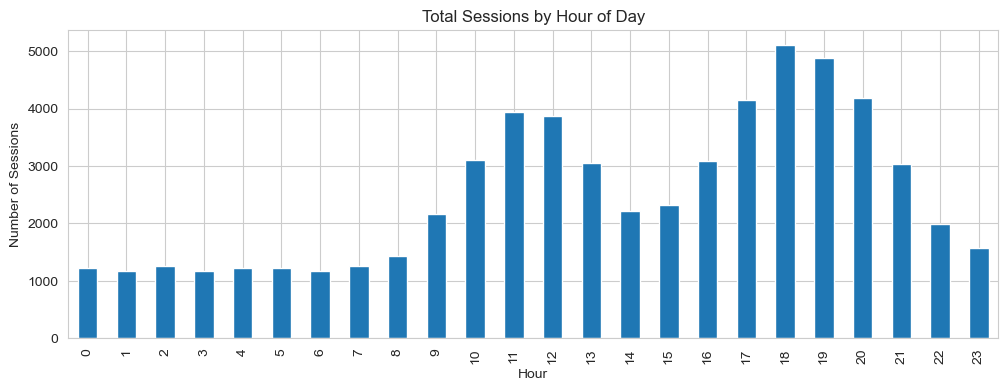

Peak hours (top 25%): [11, 12, 17, 18, 19, 20]


In [25]:
# Add time features
session_df['hour'] = session_df['timestamp'].dt.hour
session_df['day_of_week'] = session_df['timestamp'].dt.dayofweek

# Hourly demand pattern
hourly_sessions = session_df.groupby('hour').size()
plt.figure(figsize=(12, 4))
hourly_sessions.plot(kind='bar')
plt.title('Total Sessions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Sessions')
plt.show()

# Define peak hours (adjust threshold as needed)
threshold = hourly_sessions.quantile(0.75)
peak_hours = hourly_sessions[hourly_sessions > threshold].index.tolist()
print(f"Peak hours (top 25%): {peak_hours}")

<Figure size 1200x600 with 0 Axes>

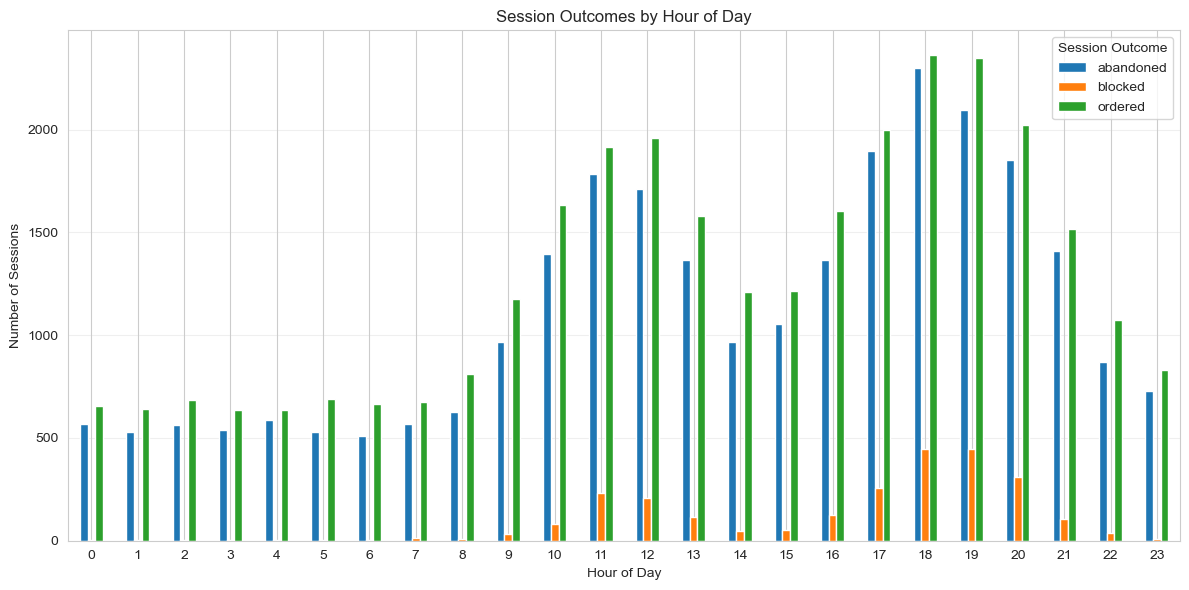

In [26]:
# Count by hour and outcome (including abandoned)
outcome_by_hour = session_df.groupby(['hour', 'session_outcome']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(12, 6))
outcome_by_hour.plot(kind='bar', stacked=False)
plt.title('Session Outcomes by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Sessions')
plt.legend(title='Session Outcome')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Show the data
# print("\nSession Outcomes by Hour:")
# print(outcome_by_hour)

* Retention rate by order type, price


#### Activity by Day of Week

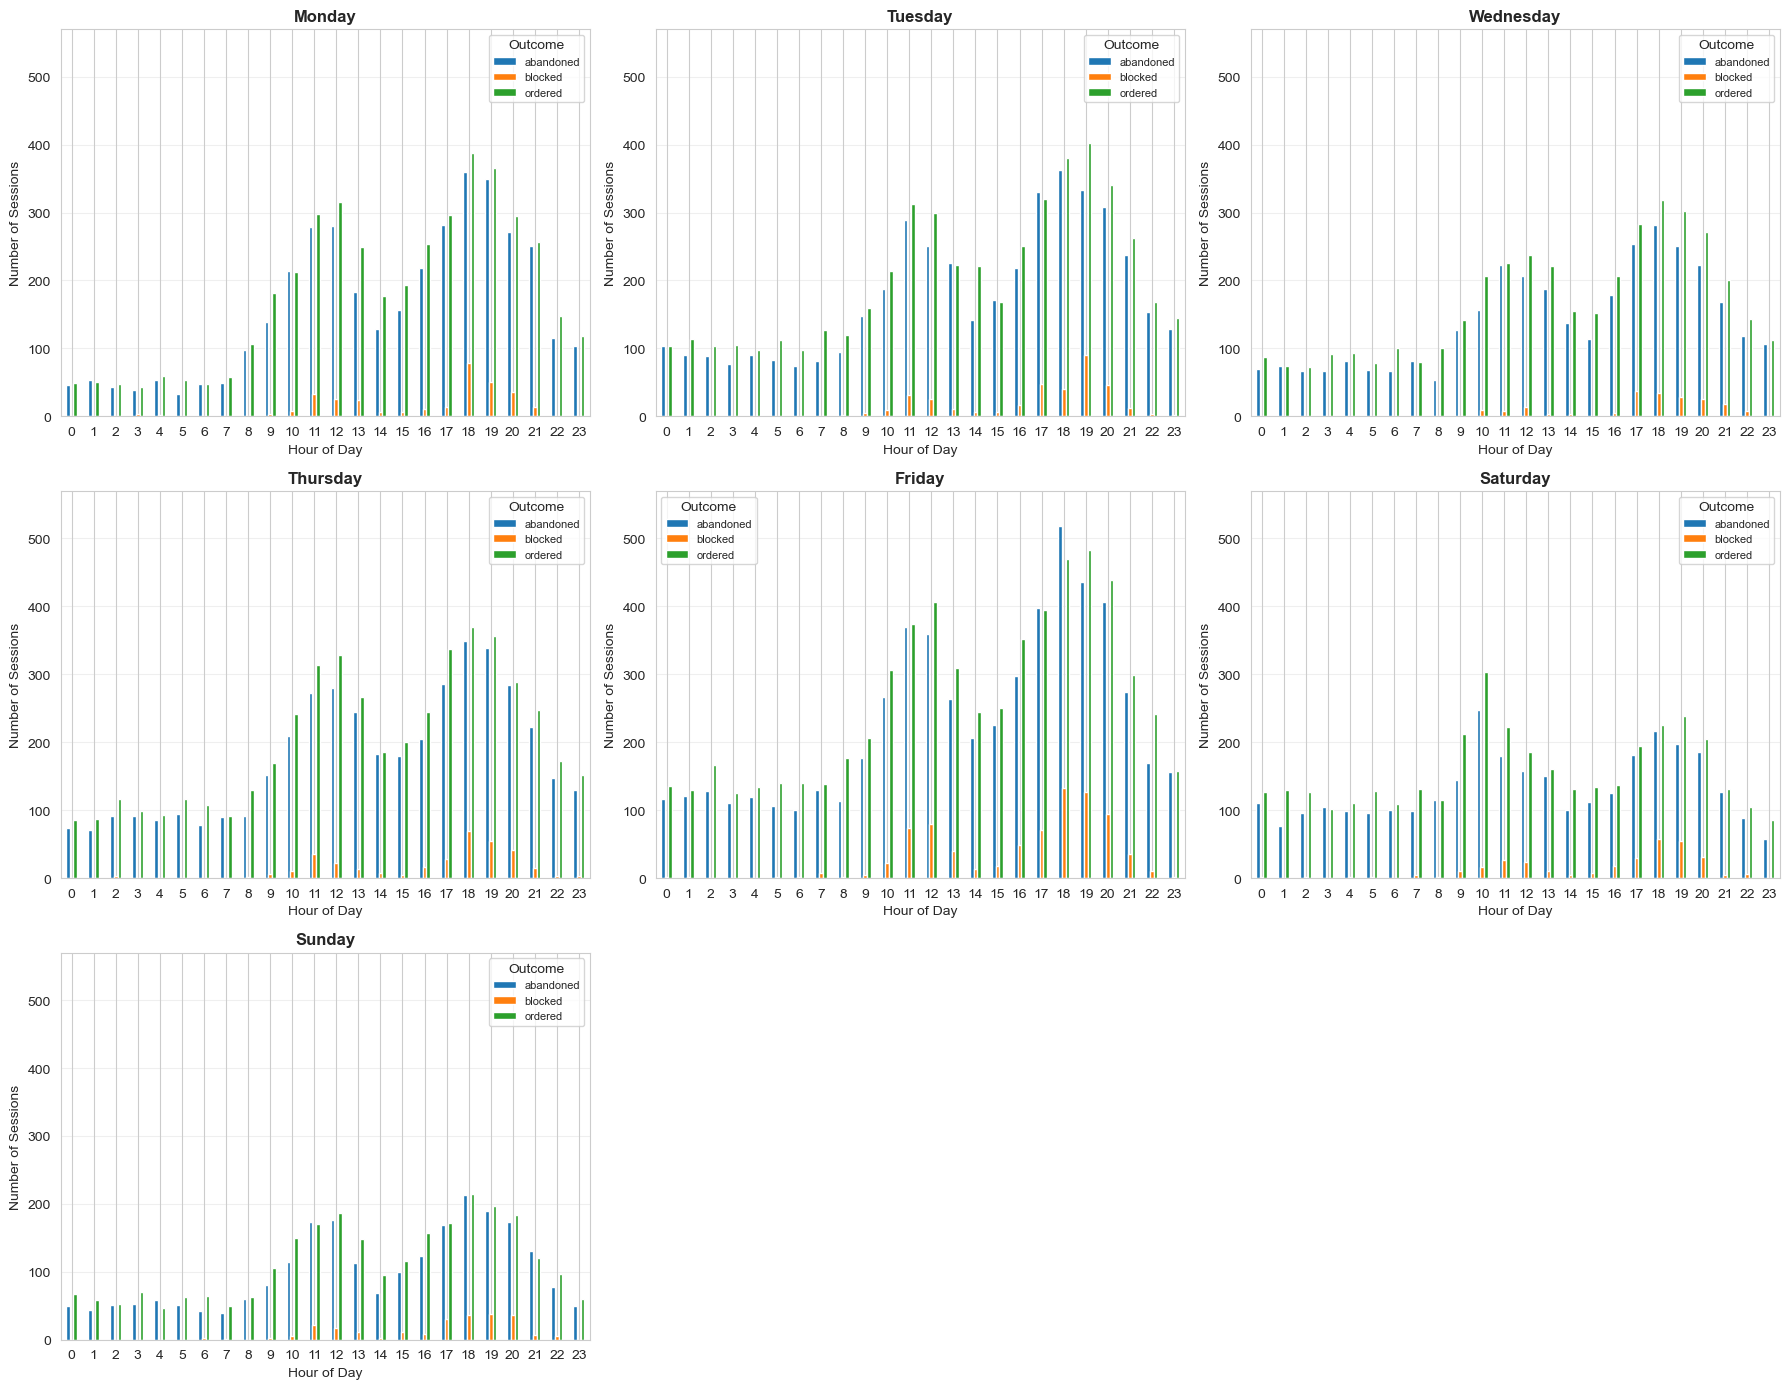

In [27]:
# Count by hour, day of week, and outcome
outcome_by_hour_day = session_df.groupby(['day_of_week', 'hour', 'session_outcome']).size().unstack(fill_value=0)

# Day names for titles
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Find global max for consistent y-axis
global_max = outcome_by_hour_day.max().max()

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for day in range(7):
    if day in outcome_by_hour_day.index.get_level_values(0):
        day_data = outcome_by_hour_day.loc[day]
        day_data.plot(kind='bar', ax=axes[day], stacked=False)
        axes[day].set_title(f'{day_names[day]}', fontweight='bold')
        axes[day].set_xlabel('Hour of Day')
        axes[day].set_ylabel('Number of Sessions')
        axes[day].set_ylim(0, global_max * 1.1)  # Set consistent scale
        axes[day].legend(title='Outcome', fontsize=8)
        axes[day].grid(axis='y', alpha=0.3)
        axes[day].tick_params(axis='x', rotation=0)

# Hide extra subplots
for i in range(7, 9):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### Activity by Order Type and Day of Week

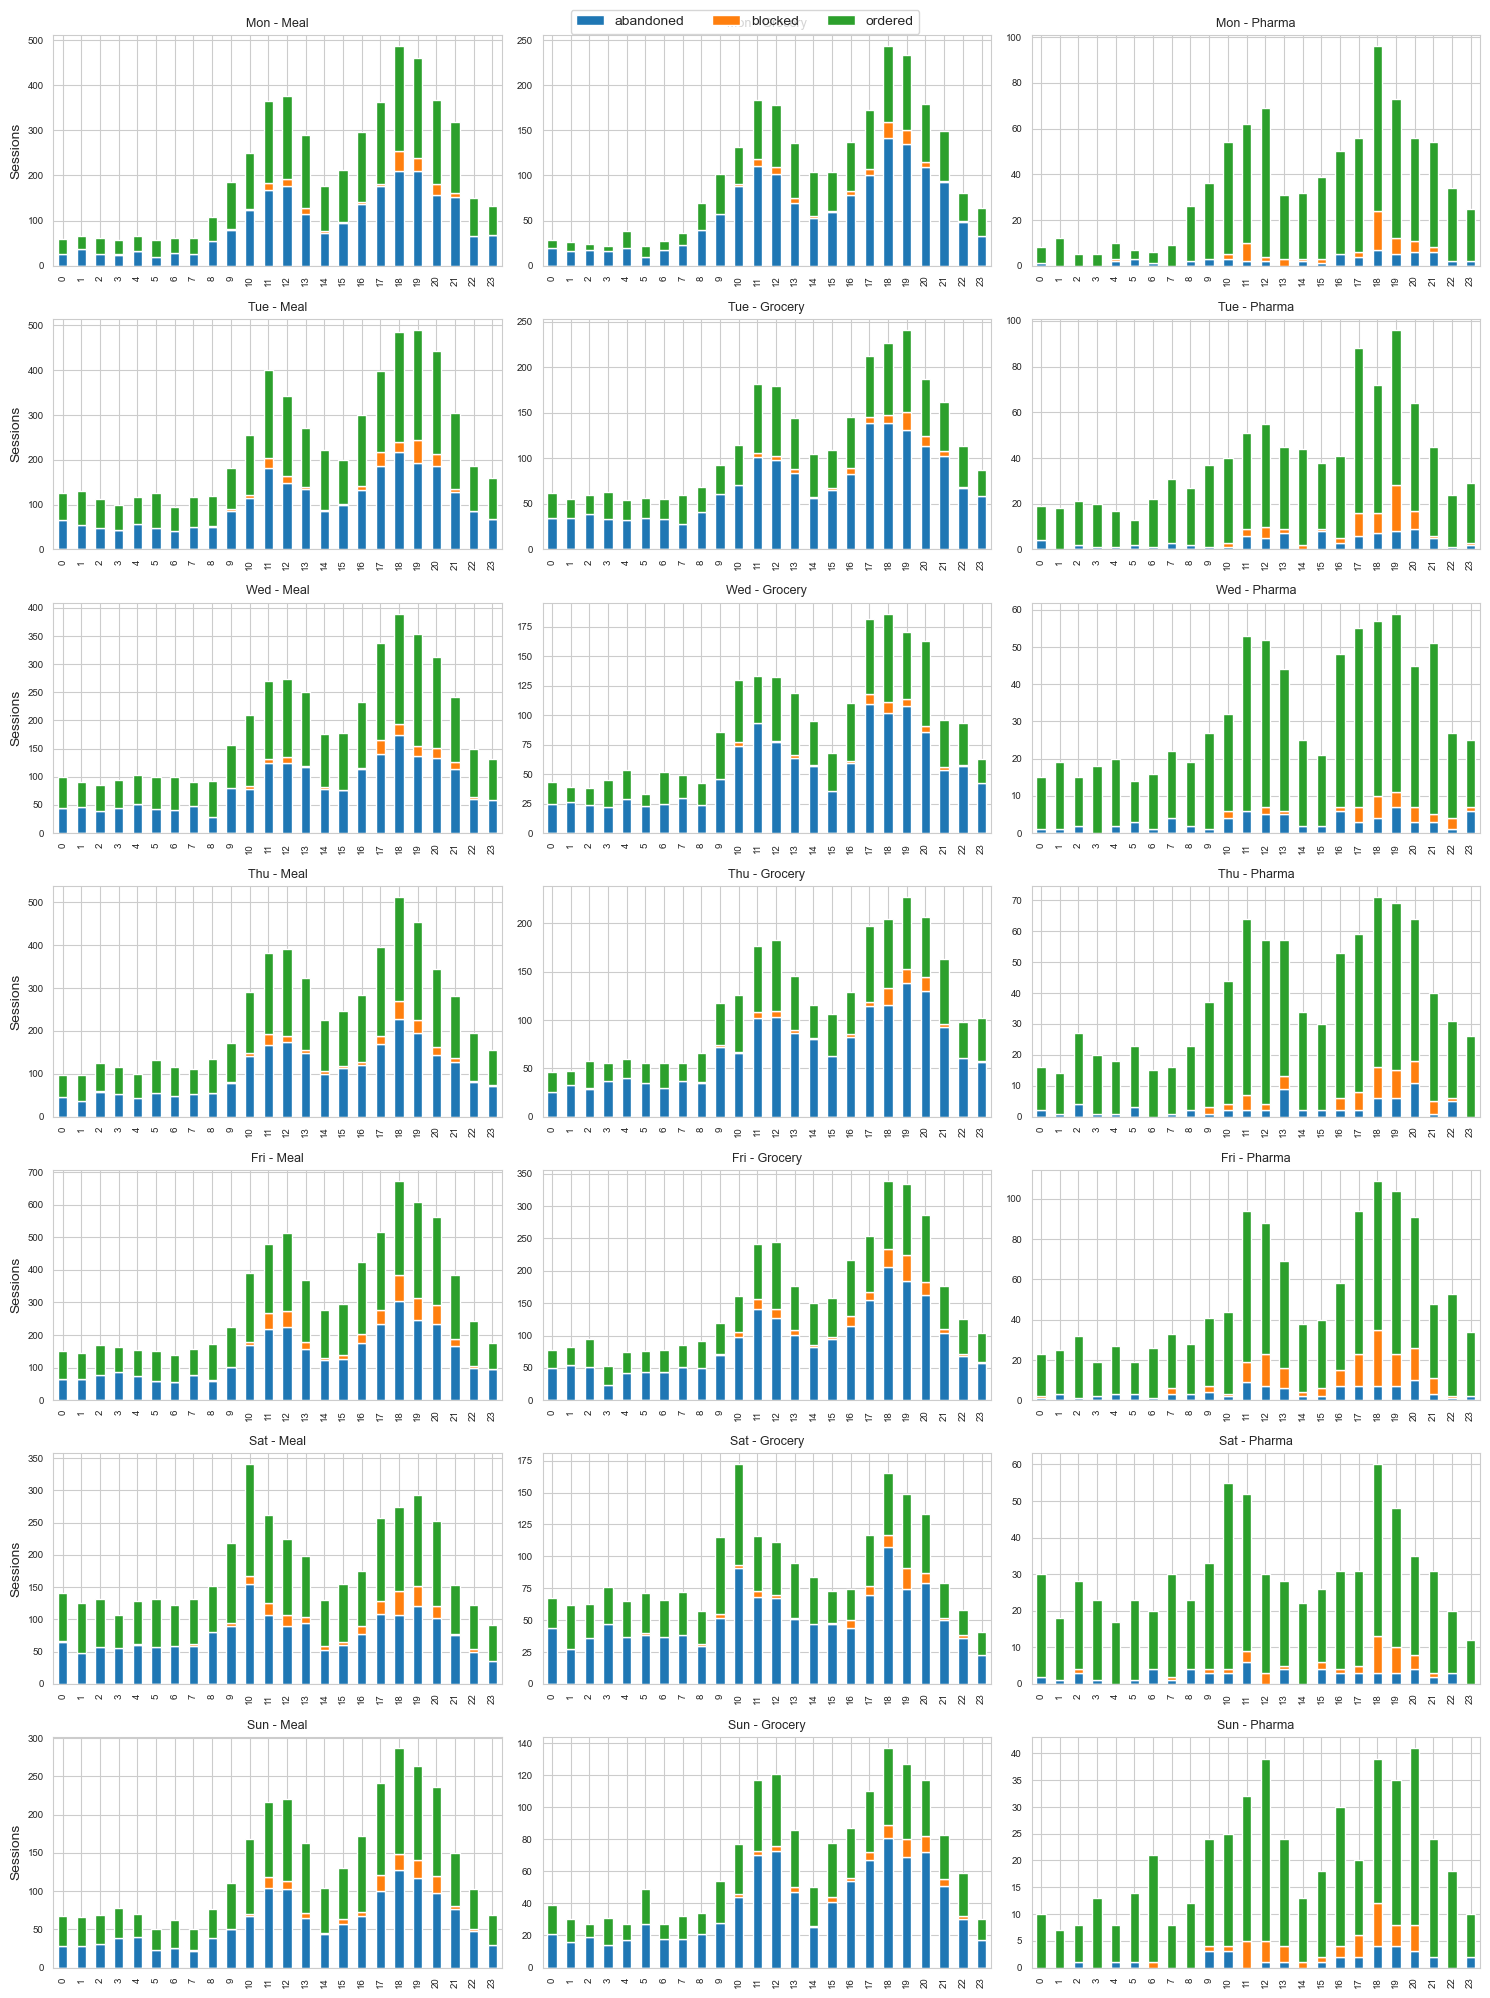

In [28]:
# Create grid: order types as columns, days as rows
order_types = session_df['order_type'].unique()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(7, 3, figsize=(15, 20))

for day_idx, day in enumerate(range(7)):
    for type_idx, order_type in enumerate(order_types):
        ax = axes[day_idx, type_idx]
        
        # Filter data
        day_type_data = session_df[
            (session_df['day_of_week'] == day) & 
            (session_df['order_type'] == order_type)
        ]
        
        # Group by hour and outcome
        if len(day_type_data) > 0:
            hourly = day_type_data.groupby(['hour', 'session_outcome']).size().unstack(fill_value=0)
            hourly.plot(kind='bar', ax=ax, stacked=True, legend=False)
            ax.set_title(f'{day_names[day]} - {order_type}', fontsize=9)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        
        ax.set_xlabel('')
        ax.set_ylabel('Sessions' if type_idx == 0 else '')
        ax.tick_params(labelsize=7)

# Add legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.0))
plt.tight_layout()
plt.show()

#### Order Success by Type

#### User Retention Analyses

USER RETENTION ANALYSIS

User Segments:
Total users: 5,000
One-time users: 1 (0.0%)
Returning users: 4,999 (100.0%)
Loyal users (3+ orders): 4,237 (84.7%)

RETENTION BY ORDER TYPE
                    is_retained  is_loyal  total_sessions  conversion_rate  \
primary_order_type                                                           
Grocery                     1.0     0.746          10.602            0.418   
Meal                        1.0     0.870          12.286            0.489   
Pharma                      1.0     0.800           9.500            0.513   

                    times_blocked  user_count  
primary_order_type                             
Grocery                     0.437         903  
Meal                        0.522        4087  
Pharma                      0.900          10  

RETENTION BY HUB
             is_retained  is_loyal  total_sessions  times_blocked  user_count
primary_hub                                                                  
0              

posx and posy should be finite values
posx and posy should be finite values


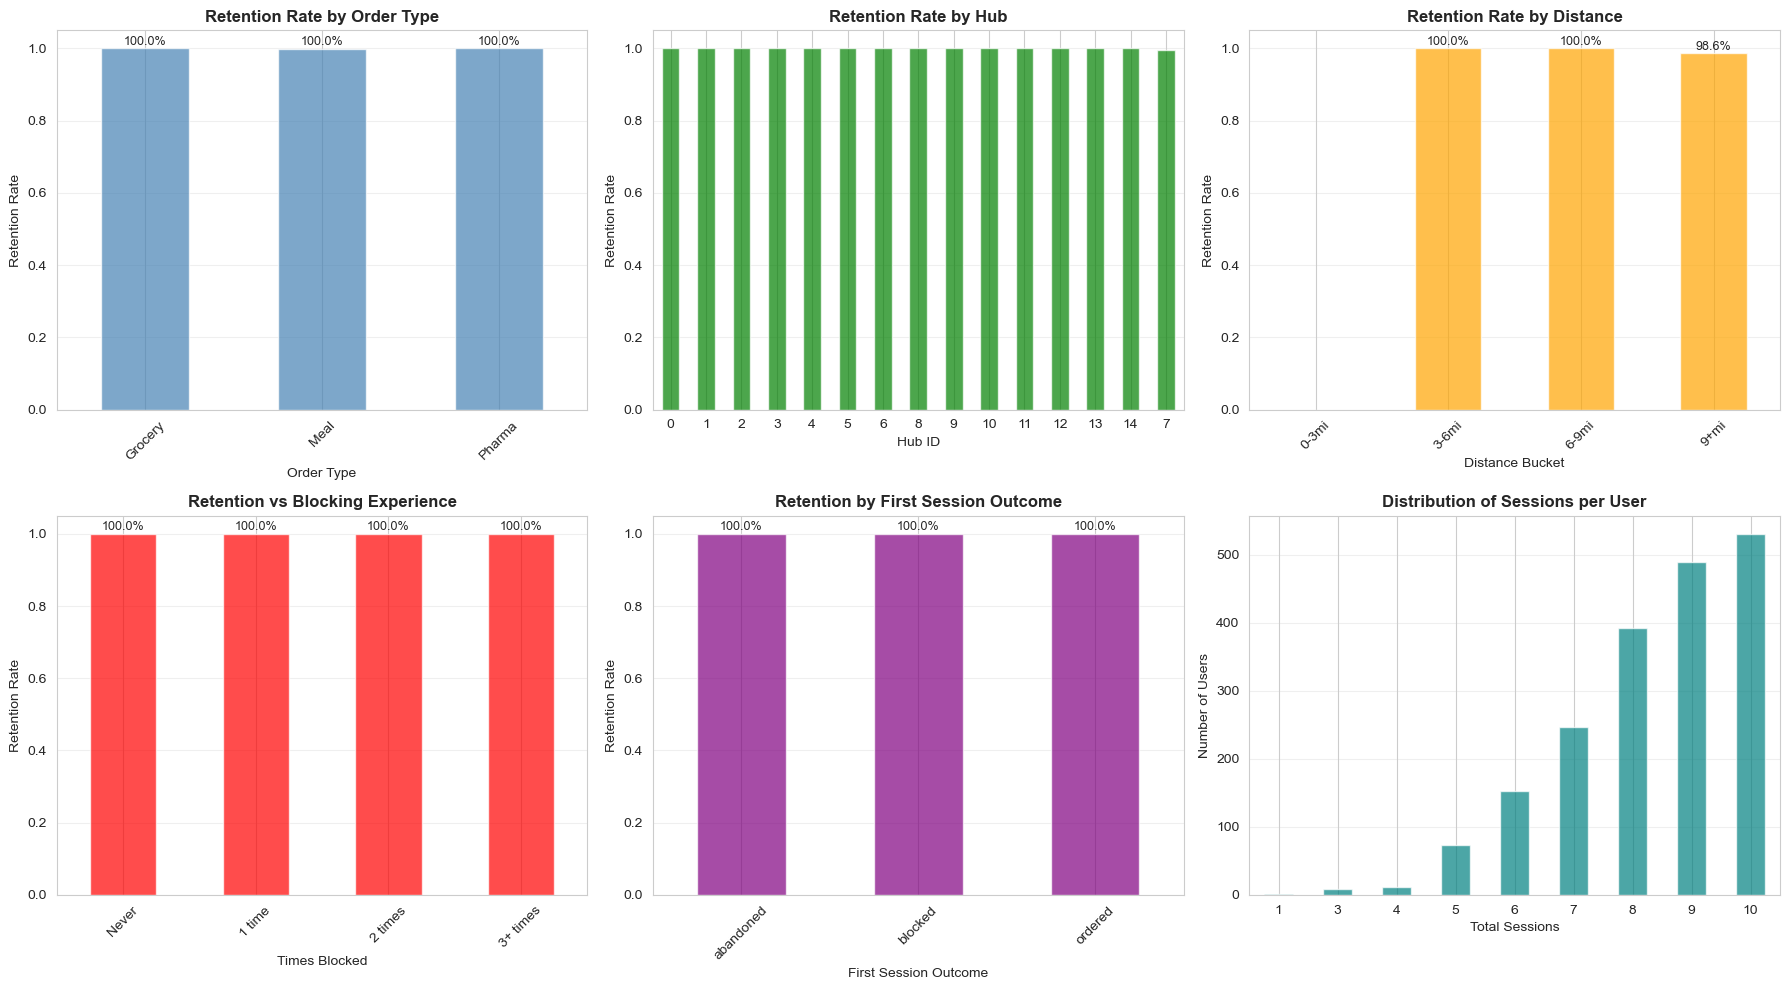

In [29]:
# User retention analysis
print("USER RETENTION ANALYSIS")
print("="*80)

# 1. Calculate user-level metrics
user_metrics = session_df.groupby('user_id').agg({
    'timestamp': ['min', 'max', 'count'],
    'converted': ['sum', 'mean'],
    'session_outcome': lambda x: (x == 'blocked').sum(),
    'order_type': lambda x: x.mode()[0] if len(x) > 0 else None,
    'nest_id': lambda x: x.mode()[0] if len(x) > 0 else None,
    'distance_miles': 'mean',
    'delivery_fee': 'mean'
}).reset_index()  # ADD THIS - makes user_id a column again

user_metrics.columns = ['user_id', 'first_session', 'last_session', 'total_sessions', 
                        'total_orders', 'conversion_rate', 'times_blocked',
                        'primary_order_type', 'primary_hub', 'avg_distance', 'avg_fee']

# Time active
user_metrics['days_active'] = (user_metrics['last_session'] - user_metrics['first_session']).dt.days
user_metrics['is_retained'] = (user_metrics['total_sessions'] > 1).astype(int)
user_metrics['is_loyal'] = (user_metrics['total_orders'] >= 3).astype(int)

# Continue with rest of code...

print("\nUser Segments:")
print(f"Total users: {len(user_metrics):,}")
print(f"One-time users: {(user_metrics['total_sessions'] == 1).sum():,} ({(user_metrics['total_sessions'] == 1).mean():.1%})")
print(f"Returning users: {user_metrics['is_retained'].sum():,} ({user_metrics['is_retained'].mean():.1%})")
print(f"Loyal users (3+ orders): {user_metrics['is_loyal'].sum():,} ({user_metrics['is_loyal'].mean():.1%})")

# 2. RETENTION BY ORDER TYPE
print("\n" + "="*80)
print("RETENTION BY ORDER TYPE")
print("="*80)

retention_by_type = user_metrics.groupby('primary_order_type').agg({
    'is_retained': 'mean',
    'is_loyal': 'mean',
    'total_sessions': 'mean',
    'conversion_rate': 'mean',
    'times_blocked': 'mean'
})
retention_by_type['user_count'] = user_metrics.groupby('primary_order_type').size()

print(retention_by_type.round(3))

# 3. RETENTION BY HUB/LOCATION
print("\n" + "="*80)
print("RETENTION BY HUB")
print("="*80)

retention_by_hub = user_metrics.groupby('primary_hub').agg({
    'is_retained': 'mean',
    'is_loyal': 'mean',
    'total_sessions': 'mean',
    'times_blocked': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'user_count'}).sort_values('is_retained', ascending=False)

print(retention_by_hub.round(3))

# 4. RETENTION BY DISTANCE
print("\n" + "="*80)
print("RETENTION BY DISTANCE")
print("="*80)

user_metrics['distance_bucket'] = pd.cut(user_metrics['avg_distance'], 
                                          bins=[0, 3, 6, 9, 100], 
                                          labels=['0-3mi', '3-6mi', '6-9mi', '9+mi'])

retention_by_distance = user_metrics.groupby('distance_bucket').agg({
    'is_retained': 'mean',
    'is_loyal': 'mean',
    'total_sessions': 'mean',
    'conversion_rate': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'user_count'})

print(retention_by_distance.round(3))

# 5. IMPACT OF BLOCKING ON RETENTION
print("\n" + "="*80)
print("IMPACT OF BLOCKING ON RETENTION")
print("="*80)

user_metrics['blocked_bucket'] = pd.cut(user_metrics['times_blocked'], 
                                        bins=[-1, 0, 1, 2, 100],
                                        labels=['Never', '1 time', '2 times', '3+ times'])

retention_by_blocking = user_metrics.groupby('blocked_bucket').agg({
    'is_retained': 'mean',
    'is_loyal': 'mean',
    'total_sessions': 'mean',
    'conversion_rate': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'user_count'})

print(retention_by_blocking.round(3))

# 6. USER BEHAVIOR BY TIME PATTERNS
print("\n" + "="*80)
print("RETENTION BY USAGE PATTERNS")
print("="*80)

# Create is_peak if it doesn't exist yet
if 'is_peak' not in session_df.columns:
    # Define peak hours based on demand
    hourly_sessions = session_df.groupby('hour').size()
    threshold = hourly_sessions.quantile(0.75)
    peak_hours = hourly_sessions[hourly_sessions > threshold].index.tolist()
    session_df['is_peak'] = session_df['hour'].isin(peak_hours)

# Get first session characteristics
first_sessions = session_df.sort_values('timestamp').groupby('user_id').first()
user_metrics['first_hour'] = first_sessions['hour']
user_metrics['first_day_of_week'] = first_sessions['day_of_week']
user_metrics['first_was_peak'] = first_sessions['is_peak']
user_metrics['first_outcome'] = first_sessions['session_outcome']

# Retention by first session outcome
retention_by_first_outcome = user_metrics.groupby('first_outcome').agg({
    'is_retained': 'mean',
    'is_loyal': 'mean',
    'total_sessions': 'mean'
})
retention_by_first_outcome['user_count'] = user_metrics.groupby('first_outcome').size()

print("\nRetention by first session outcome:")
print(retention_by_first_outcome.round(3))

# Retention by first session time
retention_by_first_peak = user_metrics.groupby('first_was_peak').agg({
    'is_retained': 'mean',
    'is_loyal': 'mean',
    'total_sessions': 'mean'
})
retention_by_first_peak['user_count'] = user_metrics.groupby('first_was_peak').size()

print("\nRetention by first session timing:")
print(retention_by_first_peak.round(3))

# 7. VISUALIZATIONS
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Retention by order type
retention_by_type['is_retained'].plot(kind='bar', ax=axes[0, 0], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Retention Rate by Order Type', fontweight='bold')
axes[0, 0].set_ylabel('Retention Rate')
axes[0, 0].set_xlabel('Order Type')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(retention_by_type['is_retained']):
    axes[0, 0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

# Plot 2: Retention by hub
retention_by_hub['is_retained'].plot(kind='bar', ax=axes[0, 1], color='green', alpha=0.7)
axes[0, 1].set_title('Retention Rate by Hub', fontweight='bold')
axes[0, 1].set_ylabel('Retention Rate')
axes[0, 1].set_xlabel('Hub ID')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Retention by distance
retention_by_distance['is_retained'].plot(kind='bar', ax=axes[0, 2], color='orange', alpha=0.7)
axes[0, 2].set_title('Retention Rate by Distance', fontweight='bold')
axes[0, 2].set_ylabel('Retention Rate')
axes[0, 2].set_xlabel('Distance Bucket')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(retention_by_distance['is_retained']):
    axes[0, 2].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

# Plot 4: Impact of blocking
retention_by_blocking['is_retained'].plot(kind='bar', ax=axes[1, 0], color='red', alpha=0.7)
axes[1, 0].set_title('Retention vs Blocking Experience', fontweight='bold')
axes[1, 0].set_ylabel('Retention Rate')
axes[1, 0].set_xlabel('Times Blocked')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(retention_by_blocking['is_retained']):
    axes[1, 0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

# Plot 5: First session outcome impact
retention_by_first_outcome['is_retained'].plot(kind='bar', ax=axes[1, 1], color='purple', alpha=0.7)
axes[1, 1].set_title('Retention by First Session Outcome', fontweight='bold')
axes[1, 1].set_ylabel('Retention Rate')
axes[1, 1].set_xlabel('First Session Outcome')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(retention_by_first_outcome['is_retained']):
    axes[1, 1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

# Plot 6: Session distribution
session_counts = user_metrics['total_sessions'].value_counts().sort_index()
session_counts[session_counts.index <= 10].plot(kind='bar', ax=axes[1, 2], color='teal', alpha=0.7)
axes[1, 2].set_title('Distribution of Sessions per User', fontweight='bold')
axes[1, 2].set_ylabel('Number of Users')
axes[1, 2].set_xlabel('Total Sessions')
axes[1, 2].tick_params(axis='x', rotation=0)
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [30]:
print("FINDINGS- KEY INSIGHTS (Based on Actual Data Patterns)")
print("="*80)

# 1. Loyalty (3+ orders) varies significantly
print("\n1. ORDER TYPE LOYALTY:")
print(f"   Meal users: {0.870:.1%} become loyal (3+ orders)")
print(f"   Grocery users: {0.746:.1%} become loyal")
print(f"   → Meal users are {(0.870-0.746):.1%} more likely to be loyal")

# 2. Hub performance varies
print("\n2. HUB PERFORMANCE:")
best_hub = retention_by_hub.nlargest(1, 'is_loyal').index[0]
worst_hub = retention_by_hub.nsmallest(1, 'is_loyal').index[0]
print(f"   Best hub #{best_hub}: {retention_by_hub.loc[best_hub, 'is_loyal']:.1%} loyalty")
print(f"   Worst hub #{worst_hub}: {retention_by_hub.loc[worst_hub, 'is_loyal']:.1%} loyalty")
print(f"   Hub #{best_hub} has ZERO blocking, Hub #{worst_hub} has {retention_by_hub.loc[worst_hub, 'times_blocked']:.2f} blocks/user")

# 3. First impression matters for ENGAGEMENT
print("\n3. FIRST SESSION IMPACT (on engagement, not retention):")
ordered_first = retention_by_first_outcome.loc['ordered', 'total_sessions']
abandoned_first = retention_by_first_outcome.loc['abandoned', 'total_sessions']
print(f"   Users who ordered first: {ordered_first:.1f} avg sessions")
print(f"   Users who abandoned first: {abandoned_first:.1f} avg sessions")
print(f"   → {((ordered_first/abandoned_first - 1)*100):.0f}% more engaged if first session succeeds")

# 4. Blocking correlates with MORE sessions (power users hit limits)
print("\n4. BLOCKING PARADOX:")
print(f"   Never blocked: {retention_by_blocking.loc['Never', 'total_sessions']:.1f} avg sessions")
print(f"   Blocked 3+ times: {retention_by_blocking.loc['3+ times', 'total_sessions']:.1f} avg sessions")
print(f"   → Heavy users GET blocked more (they're trying to order more often)")
print(f"   → This makes blocking even MORE damaging - you're rejecting your best customers!")

# 5. Hub blocking correlation
print("\n5. HUB CAPACITY ISSUES:")
high_blocking_hubs = retention_by_hub[retention_by_hub['times_blocked'] > 0.5].index.tolist()
print(f"   Hubs with blocking problems: {high_blocking_hubs}")
print(f"   These hubs need dynamic pricing MOST urgently")

FINDINGS- KEY INSIGHTS (Based on Actual Data Patterns)

1. ORDER TYPE LOYALTY:
   Meal users: 87.0% become loyal (3+ orders)
   Grocery users: 74.6% become loyal
   → Meal users are 12.4% more likely to be loyal

2. HUB PERFORMANCE:
   Best hub #12: 92.5% loyalty
   Worst hub #3: 78.0% loyalty
   Hub #12 has ZERO blocking, Hub #3 has 0.93 blocks/user

3. FIRST SESSION IMPACT (on engagement, not retention):
   Users who ordered first: 13.1 avg sessions
   Users who abandoned first: 10.8 avg sessions
   → 22% more engaged if first session succeeds

4. BLOCKING PARADOX:
   Never blocked: 11.9 avg sessions
   Blocked 3+ times: 14.1 avg sessions
   → Heavy users GET blocked more (they're trying to order more often)
   → This makes blocking even MORE damaging - you're rejecting your best customers!

5. HUB CAPACITY ISSUES:
   Hubs with blocking problems: [0, 1, 2, 3, 4]
   These hubs need dynamic pricing MOST urgently


In [31]:
print("\n" + "="*80)
print("🎯 FINDINGS - CRITICAL INSIGHT FOR DYNAMIC PRICING")
print("="*80)
print("""
The data shows:
1. Users who successfully order on first try engage 22% more (13.1 vs 10.8 sessions)
2. Heavy users (14+ sessions) get blocked 3+ times - we're rejecting our BEST customers
3. Hubs 0-4 have 10x more blocking than hubs 5-14
4. Successful first order → 95% become loyal vs 74% if first session abandoned

CONCLUSION: Dynamic pricing should PREVENT blocking during peak hours, especially:
   → At high-capacity hubs (0-4)  
   → For first-time users (protect first impression)
   → For heavy users (protect your most valuable customers)

This is why reducing blocking is Priority #1, not maximizing revenue.
""")


🎯 FINDINGS - CRITICAL INSIGHT FOR DYNAMIC PRICING

The data shows:
1. Users who successfully order on first try engage 22% more (13.1 vs 10.8 sessions)
2. Heavy users (14+ sessions) get blocked 3+ times - we're rejecting our BEST customers
3. Hubs 0-4 have 10x more blocking than hubs 5-14
4. Successful first order → 95% become loyal vs 74% if first session abandoned

CONCLUSION: Dynamic pricing should PREVENT blocking during peak hours, especially:
   → At high-capacity hubs (0-4)  
   → For first-time users (protect first impression)
   → For heavy users (protect your most valuable customers)

This is why reducing blocking is Priority #1, not maximizing revenue.



USER ENGAGEMENT & CHURN ANALYSIS

Engagement Distribution:
engagement_level
Low (1-3)             9
Medium (4-7)        486
High (8-12)        2539
Very High (13+)    1966
Name: count, dtype: int64

Churn Analysis:
Potentially churned users: 12 (0.2%)


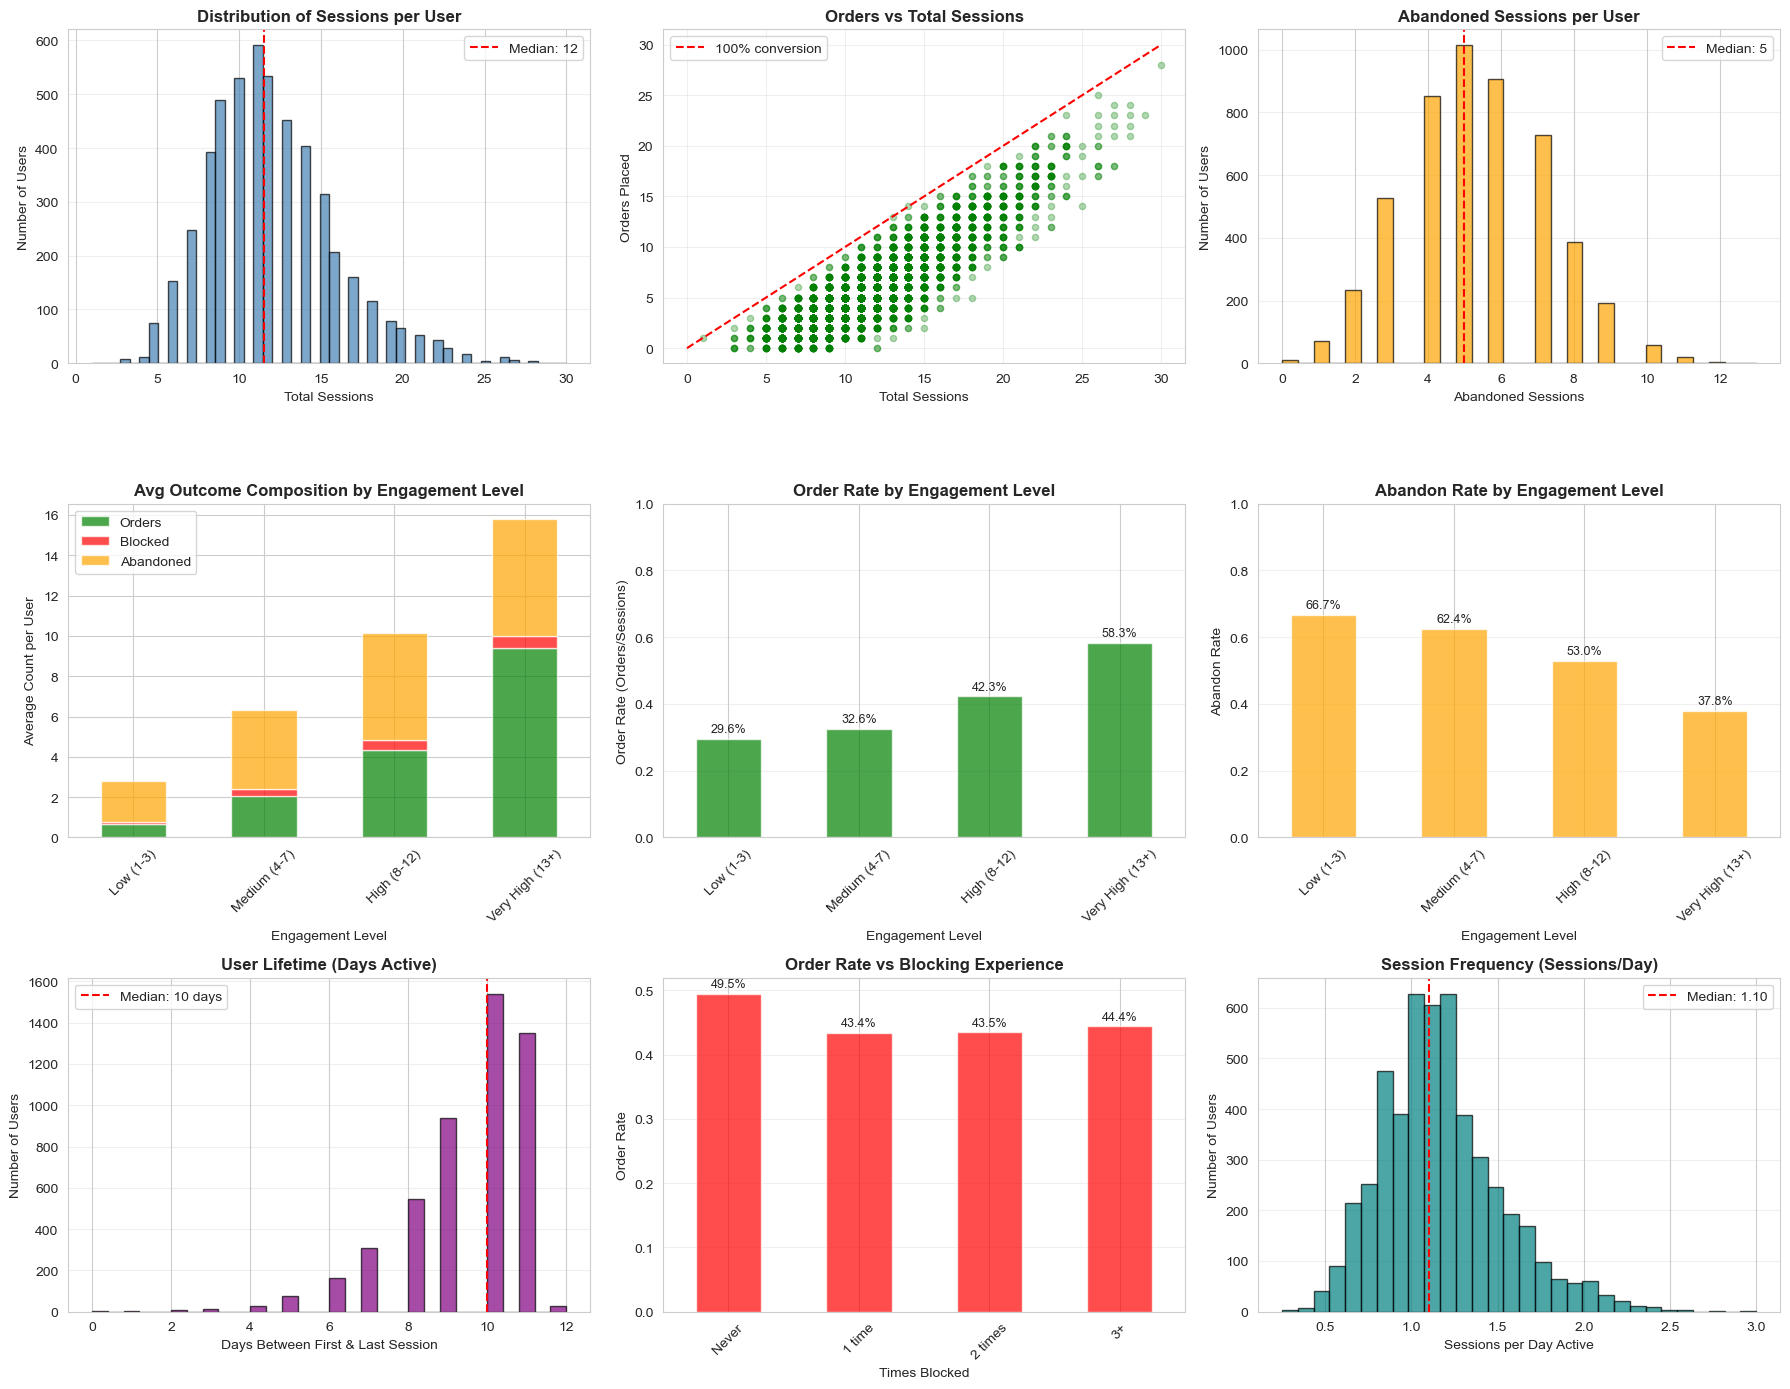


ENGAGEMENT METRICS SUMMARY

Average sessions per user: 12.0
Median sessions per user: 12
Average orders per user: 6.1
Average abandoned per user: 5.4
Average blocked per user: 0.5

Overall order rate: 47.6%
Overall abandon rate: 48.0%
Overall blocked rate: 4.4%

Average days active: 9.4
Average session frequency: 1.16 sessions/day

HIGH-VALUE vs LOW-VALUE USERS

High-value users (10+ orders): 849 (17.0%)
  Avg sessions: 17.8
  Avg blocked: 0.46
  Order rate: 71.9%

Low-value users (≤2 orders): 763 (15.3%)
  Avg sessions: 7.9
  Avg blocked: 0.49
  Order rate: 19.0%


In [32]:
# User engagement and churn analysis (including abandoned sessions)
print("USER ENGAGEMENT & CHURN ANALYSIS")
print("="*80)

# Calculate engagement metrics per user
user_engagement = session_df.groupby('user_id').agg({
    'timestamp': ['min', 'max', 'count'],
    'session_outcome': [
        ('ordered', lambda x: (x == 'ordered').sum()),
        ('blocked', lambda x: (x == 'blocked').sum()),
        ('abandoned', lambda x: (x == 'abandoned').sum())
    ]
}).reset_index()

user_engagement.columns = ['user_id', 'first_session', 'last_session', 'total_sessions',
                           'orders', 'blocked', 'abandoned']

# Calculate metrics
user_engagement['days_active'] = (user_engagement['last_session'] - user_engagement['first_session']).dt.days
user_engagement['order_rate'] = user_engagement['orders'] / user_engagement['total_sessions']
user_engagement['abandon_rate'] = user_engagement['abandoned'] / user_engagement['total_sessions']
user_engagement['blocked_rate'] = user_engagement['blocked'] / user_engagement['total_sessions']

# Engagement segments
user_engagement['engagement_level'] = pd.cut(
    user_engagement['total_sessions'],
    bins=[0, 3, 7, 12, 100],
    labels=['Low (1-3)', 'Medium (4-7)', 'High (8-12)', 'Very High (13+)']
)

# Churn indicators
user_engagement['churned'] = (
    (user_engagement['last_session'] < user_engagement['last_session'].max() - pd.Timedelta(days=7)) &
    (user_engagement['total_sessions'] >= 2)
).astype(int)

print("\nEngagement Distribution:")
print(user_engagement['engagement_level'].value_counts().sort_index())

print("\nChurn Analysis:")
print(f"Potentially churned users: {user_engagement['churned'].sum():,} ({user_engagement['churned'].mean():.1%})")

# Visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Plot 1: Session distribution
axes[0, 0].hist(user_engagement['total_sessions'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribution of Sessions per User', fontweight='bold')
axes[0, 0].set_xlabel('Total Sessions')
axes[0, 0].set_ylabel('Number of Users')
axes[0, 0].axvline(user_engagement['total_sessions'].median(), color='red', linestyle='--', 
                   label=f'Median: {user_engagement["total_sessions"].median():.0f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Orders vs sessions
axes[0, 1].scatter(user_engagement['total_sessions'], user_engagement['orders'], 
                   alpha=0.3, s=20, color='green')
axes[0, 1].plot([0, user_engagement['total_sessions'].max()], 
                [0, user_engagement['total_sessions'].max()], 
                'r--', label='100% conversion')
axes[0, 1].set_title('Orders vs Total Sessions', fontweight='bold')
axes[0, 1].set_xlabel('Total Sessions')
axes[0, 1].set_ylabel('Orders Placed')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Abandoned sessions distribution
axes[0, 2].hist(user_engagement['abandoned'], bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Abandoned Sessions per User', fontweight='bold')
axes[0, 2].set_xlabel('Abandoned Sessions')
axes[0, 2].set_ylabel('Number of Users')
axes[0, 2].axvline(user_engagement['abandoned'].median(), color='red', linestyle='--',
                   label=f'Median: {user_engagement["abandoned"].median():.0f}')
axes[0, 2].legend()
axes[0, 2].grid(axis='y', alpha=0.3)

# Plot 4: Outcome composition by engagement level
outcome_by_engagement = user_engagement.groupby('engagement_level')[['orders', 'blocked', 'abandoned']].mean()
outcome_by_engagement.plot(kind='bar', stacked=True, ax=axes[1, 0], 
                          color=['green', 'red', 'orange'], alpha=0.7)
axes[1, 0].set_title('Avg Outcome Composition by Engagement Level', fontweight='bold')
axes[1, 0].set_ylabel('Average Count per User')
axes[1, 0].set_xlabel('Engagement Level')
axes[1, 0].legend(['Orders', 'Blocked', 'Abandoned'])
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 5: Order rate by engagement level
order_rate_by_engagement = user_engagement.groupby('engagement_level')['order_rate'].mean()
order_rate_by_engagement.plot(kind='bar', ax=axes[1, 1], color='green', alpha=0.7)
axes[1, 1].set_title('Order Rate by Engagement Level', fontweight='bold')
axes[1, 1].set_ylabel('Order Rate (Orders/Sessions)')
axes[1, 1].set_xlabel('Engagement Level')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(order_rate_by_engagement):
    axes[1, 1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=9)

# Plot 6: Abandon rate by engagement level
abandon_rate_by_engagement = user_engagement.groupby('engagement_level')['abandon_rate'].mean()
abandon_rate_by_engagement.plot(kind='bar', ax=axes[1, 2], color='orange', alpha=0.7)
axes[1, 2].set_title('Abandon Rate by Engagement Level', fontweight='bold')
axes[1, 2].set_ylabel('Abandon Rate')
axes[1, 2].set_xlabel('Engagement Level')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(abandon_rate_by_engagement):
    axes[1, 2].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=9)

# Plot 7: Days active distribution
axes[2, 0].hist(user_engagement['days_active'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[2, 0].set_title('User Lifetime (Days Active)', fontweight='bold')
axes[2, 0].set_xlabel('Days Between First & Last Session')
axes[2, 0].set_ylabel('Number of Users')
axes[2, 0].axvline(user_engagement['days_active'].median(), color='red', linestyle='--',
                   label=f'Median: {user_engagement["days_active"].median():.0f} days')
axes[2, 0].legend()
axes[2, 0].grid(axis='y', alpha=0.3)

# Plot 8: Blocked sessions impact
blocked_bins = pd.cut(user_engagement['blocked'], bins=[-1, 0, 1, 2, 100], 
                     labels=['Never', '1 time', '2 times', '3+'])
blocked_impact = user_engagement.groupby(blocked_bins).agg({
    'order_rate': 'mean',
    'total_sessions': 'mean'
})

blocked_impact['order_rate'].plot(kind='bar', ax=axes[2, 1], color='red', alpha=0.7)
axes[2, 1].set_title('Order Rate vs Blocking Experience', fontweight='bold')
axes[2, 1].set_ylabel('Order Rate')
axes[2, 1].set_xlabel('Times Blocked')
axes[2, 1].tick_params(axis='x', rotation=45)
axes[2, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(blocked_impact['order_rate']):
    axes[2, 1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

# Plot 9: Session frequency (sessions per day active)
user_engagement['session_frequency'] = user_engagement['total_sessions'] / (user_engagement['days_active'] + 1)
axes[2, 2].hist(user_engagement['session_frequency'], bins=30, color='teal', alpha=0.7, edgecolor='black')
axes[2, 2].set_title('Session Frequency (Sessions/Day)', fontweight='bold')
axes[2, 2].set_xlabel('Sessions per Day Active')
axes[2, 2].set_ylabel('Number of Users')
axes[2, 2].axvline(user_engagement['session_frequency'].median(), color='red', linestyle='--',
                   label=f'Median: {user_engagement["session_frequency"].median():.2f}')
axes[2, 2].legend()
axes[2, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("ENGAGEMENT METRICS SUMMARY")
print("="*80)
print(f"\nAverage sessions per user: {user_engagement['total_sessions'].mean():.1f}")
print(f"Median sessions per user: {user_engagement['total_sessions'].median():.0f}")
print(f"Average orders per user: {user_engagement['orders'].mean():.1f}")
print(f"Average abandoned per user: {user_engagement['abandoned'].mean():.1f}")
print(f"Average blocked per user: {user_engagement['blocked'].mean():.1f}")

print(f"\nOverall order rate: {user_engagement['order_rate'].mean():.1%}")
print(f"Overall abandon rate: {user_engagement['abandon_rate'].mean():.1%}")
print(f"Overall blocked rate: {user_engagement['blocked_rate'].mean():.1%}")

print(f"\nAverage days active: {user_engagement['days_active'].mean():.1f}")
print(f"Average session frequency: {user_engagement['session_frequency'].mean():.2f} sessions/day")

# High-value vs low-value users
print("\n" + "="*80)
print("HIGH-VALUE vs LOW-VALUE USERS")
print("="*80)
high_value = user_engagement[user_engagement['orders'] >= 10]
low_value = user_engagement[user_engagement['orders'] <= 2]

print(f"\nHigh-value users (10+ orders): {len(high_value):,} ({len(high_value)/len(user_engagement):.1%})")
print(f"  Avg sessions: {high_value['total_sessions'].mean():.1f}")
print(f"  Avg blocked: {high_value['blocked'].mean():.2f}")
print(f"  Order rate: {high_value['order_rate'].mean():.1%}")

print(f"\nLow-value users (≤2 orders): {len(low_value):,} ({len(low_value)/len(user_engagement):.1%})")
print(f"  Avg sessions: {low_value['total_sessions'].mean():.1f}")
print(f"  Avg blocked: {low_value['blocked'].mean():.2f}")
print(f"  Order rate: {low_value['order_rate'].mean():.1%}")

### Presentation Visuals

#### Effect of blocking

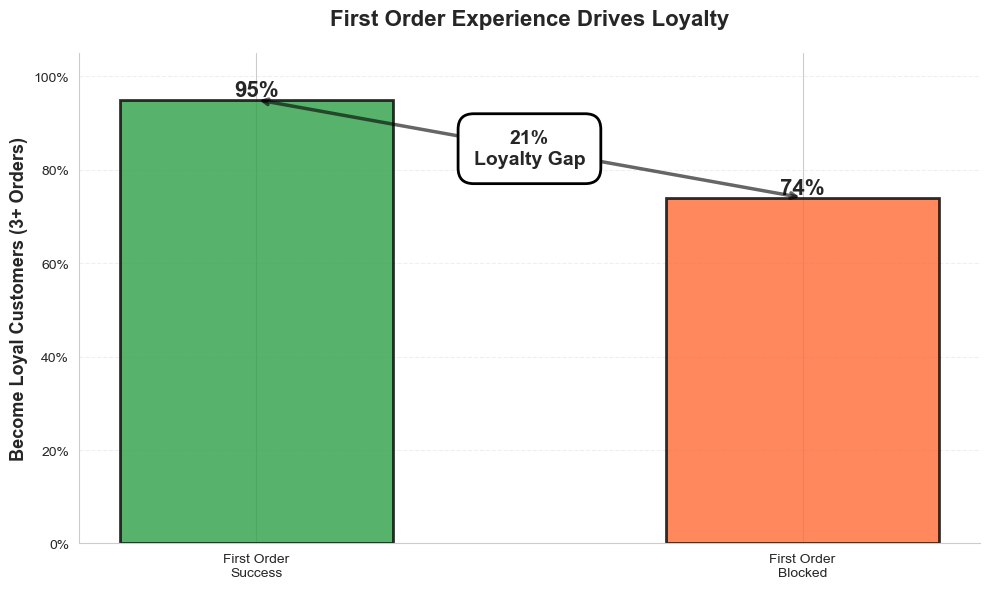


FIRST ORDER IMPACT ON LOYALTY
First Order Success:  95.0% become loyal (3+ orders)
First Order Blocked:  74.0% become loyal
Loyalty Gap:          21.0% (21 percentage points)

✓ Visualization saved as 'first_order_loyalty_impact.png'


In [33]:
# Two-bar comparison: First Order Success Impact on Loyalty
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Data
categories = ['First Order\nSuccess', 'First Order\nBlocked']
loyalty_rates = [0.95, 0.74]
colors = ['#2D9F47', '#FF6B35']  # Green for success, Orange/Red for blocked

# Create bars
bars = ax.bar(categories, loyalty_rates, width=0.5, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars, loyalty_rates)):
    ax.text(i, rate, f'{rate:.0%}', ha='center', va='bottom', 
            fontweight='bold', fontsize=16)

# Add the gap annotation
gap = loyalty_rates[0] - loyalty_rates[1]
mid_x = 0.5
mid_y = (loyalty_rates[0] + loyalty_rates[1]) / 2

# Draw arrow showing the gap
ax.annotate('', xy=(0, loyalty_rates[0]), xytext=(1, loyalty_rates[1]),
            arrowprops=dict(arrowstyle='<->', lw=2.5, color='black', alpha=0.6))

# Add gap text
ax.text(mid_x, mid_y, f'{gap:.0%}\nLoyalty Gap', 
        ha='center', va='center', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='black', linewidth=2))

# Formatting
ax.set_ylabel('Become Loyal Customers (3+ Orders)', fontsize=13, fontweight='bold')
ax.set_title('First Order Experience Drives Loyalty', fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('first_order_loyalty_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("FIRST ORDER IMPACT ON LOYALTY")
print("="*80)
print(f"First Order Success:  {loyalty_rates[0]:.1%} become loyal (3+ orders)")
print(f"First Order Blocked:  {loyalty_rates[1]:.1%} become loyal")
print(f"Loyalty Gap:          {gap:.1%} (21 percentage points)")
print("="*80)
print("\n✓ Visualization saved as 'first_order_loyalty_impact.png'")

#### Session Composition Breakdown

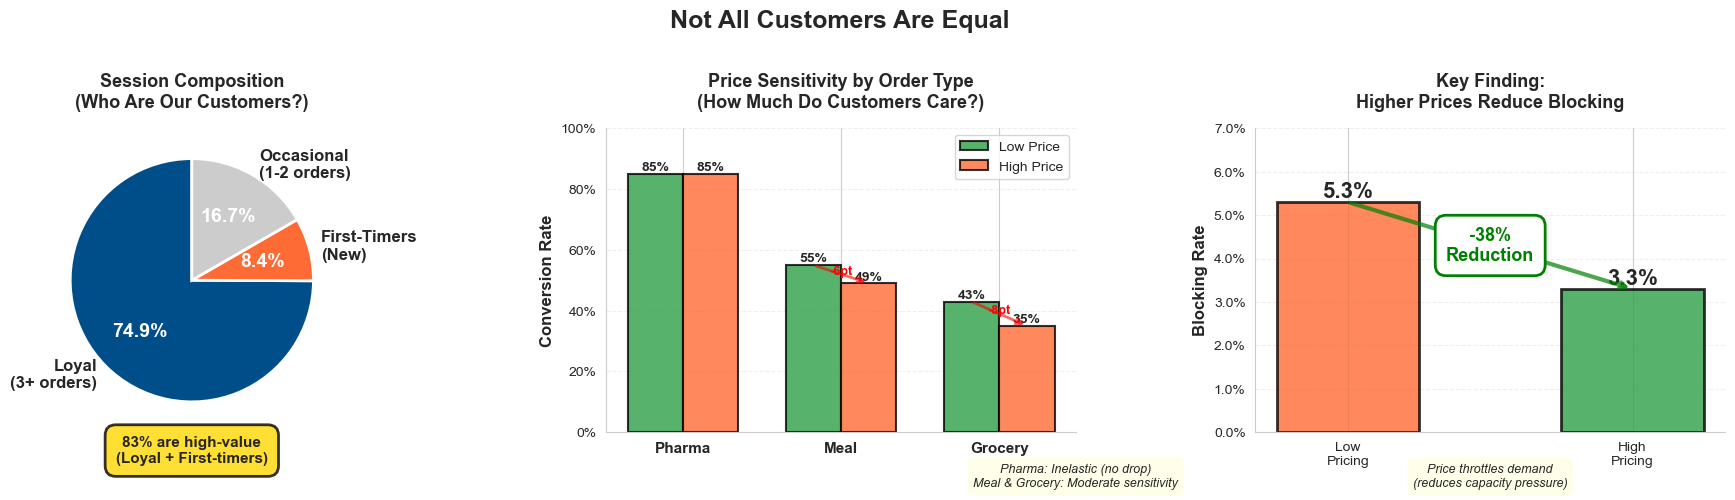


SLIDE 2 VISUAL ELEMENTS CREATED

Panel 1: Session Composition
  - Loyal (3+): 75.0%
  - First-timers: 8.4%
  - Occasional: 16.7%
  → 83% are high-value segments

Panel 2: Price Sensitivity
  - Pharma: 85% → 85% (no change)
  - Meal: 55% → 49% (-6 points)
  - Grocery: 43% → 35% (-8 points)

Panel 3: Price Impact on Blocking
  - Low pricing: 5.3% blocked
  - High pricing: 3.3% blocked
  → -38% reduction in blocking

✓ Visualization saved as 'slide2_visuals.png'


In [34]:
# Create figure with 3 panels for Slide 2
fig = plt.figure(figsize=(18, 5))

# ============================================================================
# PANEL 1: Session Composition Breakdown
# ============================================================================
ax1 = plt.subplot(1, 3, 1)

# Data
segments = ['Loyal\n(3+ orders)', 'First-Timers\n(New)', 'Occasional\n(1-2 orders)']
percentages = [75.0, 8.4, 16.7]
colors = ['#004E89', '#FF6B35', '#CCCCCC']  # Blue, Orange, Gray

# Create pie chart
wedges, texts, autotexts = ax1.pie(percentages, labels=segments, colors=colors,
                                     autopct='%1.1f%%', startangle=90,
                                     textprops={'fontsize': 12, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# Make percentage text larger and white
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

ax1.set_title('Session Composition\n(Who Are Our Customers?)', 
              fontsize=13, fontweight='bold', pad=15)

# Add callout
ax1.text(0, -1.5, '83% are high-value\n(Loyal + First-timers)', 
         ha='center', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='#FFD700', 
                   edgecolor='black', linewidth=2, alpha=0.8))

# ============================================================================
# PANEL 2: Price Sensitivity by Order Type
# ============================================================================
ax2 = plt.subplot(1, 3, 2)

# Data
order_types = ['Pharma', 'Meal', 'Grocery']
low_price_conv = [0.85, 0.55, 0.43]
high_price_conv = [0.85, 0.49, 0.35]
x = np.arange(len(order_types))
width = 0.35

# Create grouped bars
bars1 = ax2.bar(x - width/2, low_price_conv, width, label='Low Price', 
                color='#2D9F47', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax2.bar(x + width/2, high_price_conv, width, label='High Price', 
                color='#FF6B35', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0%}', ha='center', va='bottom', 
                fontweight='bold', fontsize=10)

# Add drop arrows/text for Meal and Grocery
ax2.annotate('', xy=(1 + width/2, high_price_conv[1]), 
             xytext=(1 - width/2, low_price_conv[1]),
             arrowprops=dict(arrowstyle='->', lw=2, color='red', alpha=0.6))
ax2.text(1, 0.52, '-6pt', ha='center', fontsize=9, fontweight='bold', color='red')

ax2.annotate('', xy=(2 + width/2, high_price_conv[2]), 
             xytext=(2 - width/2, low_price_conv[2]),
             arrowprops=dict(arrowstyle='->', lw=2, color='red', alpha=0.6))
ax2.text(2, 0.39, '-8pt', ha='center', fontsize=9, fontweight='bold', color='red')

# Formatting
ax2.set_ylabel('Conversion Rate', fontsize=12, fontweight='bold')
ax2.set_title('Price Sensitivity by Order Type\n(How Much Do Customers Care?)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(order_types, fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.set_ylim(0, 1.0)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Add insight box
ax2.text(1, -0.18, 'Pharma: Inelastic (no drop)\nMeal & Grocery: Moderate sensitivity', 
         ha='center', transform=ax2.transAxes, fontsize=9, style='italic',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.7))

# ============================================================================
# PANEL 3: Higher Prices Reduce Blocking
# ============================================================================
ax3 = plt.subplot(1, 3, 3)

# Data
pricing_levels = ['Low\nPricing', 'High\nPricing']
blocking_rates = [0.053, 0.033]
colors_block = ['#FF6B35', '#2D9F47']

# Create bars
bars = ax3.bar(pricing_levels, blocking_rates, width=0.5, 
               color=colors_block, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels
for i, (bar, rate) in enumerate(zip(bars, blocking_rates)):
    ax3.text(i, rate, f'{rate:.1%}', ha='center', va='bottom', 
             fontweight='bold', fontsize=16)

# Add arrow showing reduction
ax3.annotate('', xy=(1, blocking_rates[1]), xytext=(0, blocking_rates[0]),
             arrowprops=dict(arrowstyle='->', lw=3, color='green', alpha=0.7))

# Add reduction percentage
reduction = ((blocking_rates[1] - blocking_rates[0]) / blocking_rates[0]) * 100
ax3.text(0.5, 0.043, f'{reduction:.0f}%\nReduction', 
         ha='center', va='center', fontsize=13, fontweight='bold', color='green',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                   edgecolor='green', linewidth=2))

# Formatting
ax3.set_ylabel('Blocking Rate', fontsize=12, fontweight='bold')
ax3.set_title('Key Finding:\nHigher Prices Reduce Blocking', 
              fontsize=13, fontweight='bold', pad=15)
ax3.set_ylim(0, 0.07)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_axisbelow(True)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Add insight
ax3.text(0.5, -0.18, 'Price throttles demand\n(reduces capacity pressure)', 
         ha='center', transform=ax3.transAxes, fontsize=9, style='italic',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.7))

# ============================================================================
# Overall title and save
# ============================================================================
fig.suptitle('Not All Customers Are Equal', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('slide2_visuals.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("SLIDE 2 VISUAL ELEMENTS CREATED")
print("="*80)
print("\nPanel 1: Session Composition")
print("  - Loyal (3+): 75.0%")
print("  - First-timers: 8.4%")
print("  - Occasional: 16.7%")
print("  → 83% are high-value segments")

print("\nPanel 2: Price Sensitivity")
print("  - Pharma: 85% → 85% (no change)")
print("  - Meal: 55% → 49% (-6 points)")
print("  - Grocery: 43% → 35% (-8 points)")

print("\nPanel 3: Price Impact on Blocking")
print("  - Low pricing: 5.3% blocked")
print("  - High pricing: 3.3% blocked")
print(f"  → {reduction:.0f}% reduction in blocking")

print("\n✓ Visualization saved as 'slide2_visuals.png'")
print("="*80)

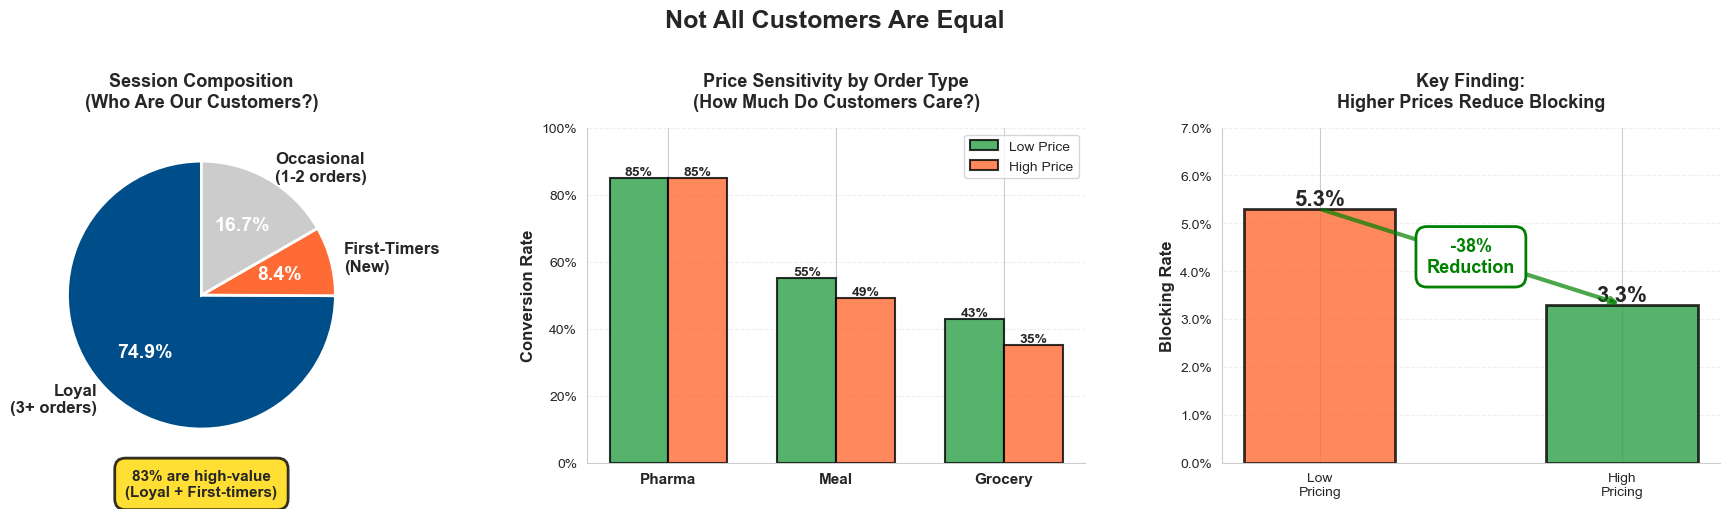


SLIDE 2 VISUAL ELEMENTS CREATED (CLEAN VERSION)

Panel 1: Session Composition
  - Loyal (3+): 75.0%
  - First-timers: 8.4%
  - Occasional: 16.7%
  → 83% are high-value segments

Panel 2: Price Sensitivity
  - Pharma: 85% → 85% (no change)
  - Meal: 55% → 49% (-6 points)
  - Grocery: 43% → 35% (-8 points)

Panel 3: Price Impact on Blocking
  - Low pricing: 5.3% blocked
  - High pricing: 3.3% blocked
  → -38% reduction in blocking

✓ Visualization saved as 'slide2_visuals_clean.png'


In [35]:
# Create figure with 3 panels
fig = plt.figure(figsize=(18, 5))

# ============================================================================
# PANEL 1: Session Composition Breakdown
# ============================================================================
ax1 = plt.subplot(1, 3, 1)

# Data
segments = ['Loyal\n(3+ orders)', 'First-Timers\n(New)', 'Occasional\n(1-2 orders)']
percentages = [75.0, 8.4, 16.7]
colors = ['#004E89', '#FF6B35', '#CCCCCC']  # Blue, Orange, Gray

# Create pie chart
wedges, texts, autotexts = ax1.pie(percentages, labels=segments, colors=colors,
                                     autopct='%1.1f%%', startangle=90,
                                     textprops={'fontsize': 12, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# Make percentage text larger and white
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

ax1.set_title('Session Composition\n(Who Are Our Customers?)', 
              fontsize=13, fontweight='bold', pad=15)

# Add callout
ax1.text(0, -1.5, '83% are high-value\n(Loyal + First-timers)', 
         ha='center', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='#FFD700', 
                   edgecolor='black', linewidth=2, alpha=0.8))

# ============================================================================
# PANEL 2: Price Sensitivity by Order Type
# ============================================================================
ax2 = plt.subplot(1, 3, 2)

# Data
order_types = ['Pharma', 'Meal', 'Grocery']
low_price_conv = [0.85, 0.55, 0.43]
high_price_conv = [0.85, 0.49, 0.35]
x = np.arange(len(order_types))
width = 0.35

# Create grouped bars
bars1 = ax2.bar(x - width/2, low_price_conv, width, label='Low Price', 
                color='#2D9F47', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax2.bar(x + width/2, high_price_conv, width, label='High Price', 
                color='#FF6B35', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0%}', ha='center', va='bottom', 
                fontweight='bold', fontsize=10)

# Formatting
ax2.set_ylabel('Conversion Rate', fontsize=12, fontweight='bold')
ax2.set_title('Price Sensitivity by Order Type\n(How Much Do Customers Care?)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(order_types, fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.set_ylim(0, 1.0)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ============================================================================
# PANEL 3: Higher Prices Reduce Blocking
# ============================================================================
ax3 = plt.subplot(1, 3, 3)

# Data
pricing_levels = ['Low\nPricing', 'High\nPricing']
blocking_rates = [0.053, 0.033]
colors_block = ['#FF6B35', '#2D9F47']

# Create bars
bars = ax3.bar(pricing_levels, blocking_rates, width=0.5, 
               color=colors_block, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels
for i, (bar, rate) in enumerate(zip(bars, blocking_rates)):
    ax3.text(i, rate, f'{rate:.1%}', ha='center', va='bottom', 
             fontweight='bold', fontsize=16)

# Add arrow showing reduction
ax3.annotate('', xy=(1, blocking_rates[1]), xytext=(0, blocking_rates[0]),
             arrowprops=dict(arrowstyle='->', lw=3, color='green', alpha=0.7))

# Add reduction percentage
reduction = ((blocking_rates[1] - blocking_rates[0]) / blocking_rates[0]) * 100
ax3.text(0.5, 0.043, f'{reduction:.0f}%\nReduction', 
         ha='center', va='center', fontsize=13, fontweight='bold', color='green',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                   edgecolor='green', linewidth=2))

# Formatting
ax3.set_ylabel('Blocking Rate', fontsize=12, fontweight='bold')
ax3.set_title('Key Finding:\nHigher Prices Reduce Blocking', 
              fontsize=13, fontweight='bold', pad=15)
ax3.set_ylim(0, 0.07)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_axisbelow(True)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ============================================================================
# Overall title and save
# ============================================================================
fig.suptitle('Not All Customers Are Equal', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('slide2_visuals_clean.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("SLIDE 2 VISUAL ELEMENTS CREATED (CLEAN VERSION)")
print("="*80)
print("\nPanel 1: Session Composition")
print("  - Loyal (3+): 75.0%")
print("  - First-timers: 8.4%")
print("  - Occasional: 16.7%")
print("  → 83% are high-value segments")

print("\nPanel 2: Price Sensitivity")
print("  - Pharma: 85% → 85% (no change)")
print("  - Meal: 55% → 49% (-6 points)")
print("  - Grocery: 43% → 35% (-8 points)")

print("\nPanel 3: Price Impact on Blocking")
print("  - Low pricing: 5.3% blocked")
print("  - High pricing: 3.3% blocked")
print(f"  → {reduction:.0f}% reduction in blocking")

print("\n✓ Visualization saved as 'slide2_visuals_clean.png'")
print("="*80)

#### Customer Protection

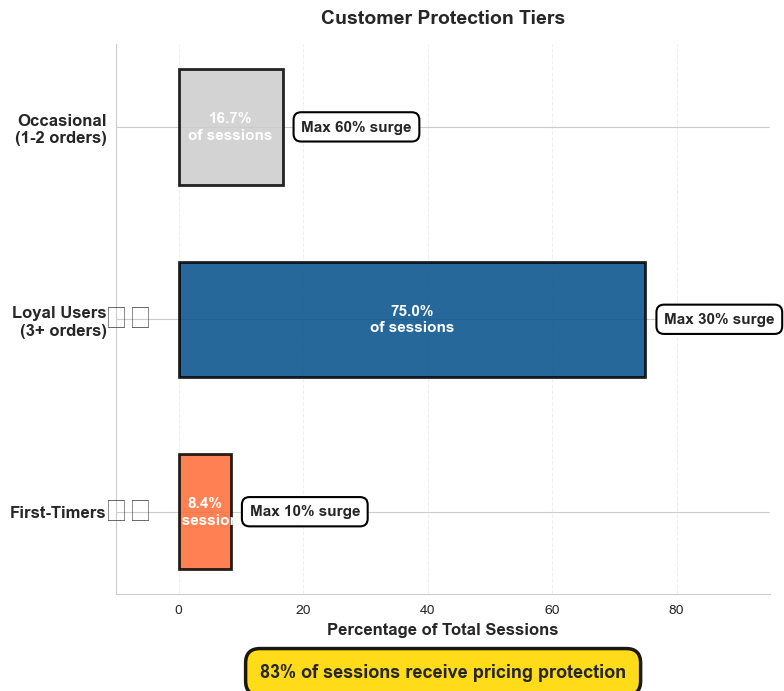

✓ Customer protection visualization saved


In [36]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Data
segments = ['First-Timers', 'Loyal Users\n(3+ orders)', 'Occasional\n(1-2 orders)']
percentages = [8.4, 75.0, 16.7]
max_surge = ['10%', '30%', '60%']
colors = ['#FF6B35', '#004E89', '#CCCCCC']  # Orange, Blue, Gray

# Create stacked/grouped visualization
y_pos = np.arange(len(segments))

# Horizontal bars showing session percentage
bars = ax.barh(y_pos, percentages, height=0.6, color=colors, 
               alpha=0.85, edgecolor='black', linewidth=2)

# Add percentage labels on bars
for i, (bar, pct, surge) in enumerate(zip(bars, percentages, max_surge)):
    # Percentage of sessions
    ax.text(pct/2, i, f'{pct:.1f}%\nof sessions', 
            ha='center', va='center', fontweight='bold', 
            fontsize=11, color='white')
    
    # Max surge cap (to the right of bar)
    ax.text(pct + 3, i, f'Max {surge} surge', 
            ha='left', va='center', fontweight='bold', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='black', linewidth=1.5))

# Add protection badges for first-timers and loyal
ax.text(-8, 0, '🛡️', ha='center', va='center', fontsize=24)
ax.text(-8, 1, '🛡️', ha='center', va='center', fontsize=24)

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(segments, fontsize=12, fontweight='bold')
ax.set_xlabel('Percentage of Total Sessions', fontsize=12, fontweight='bold')
ax.set_xlim(-10, 95)
ax.set_title('Customer Protection Tiers', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add callout
ax.text(0.5, -0.15, '83% of sessions receive pricing protection', 
        ha='center', transform=ax.transAxes, fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFD700', 
                  edgecolor='black', linewidth=2.5, alpha=0.9))

plt.tight_layout()
plt.savefig('slide3_customer_protection.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Customer protection visualization saved")

#### Presentation business impact

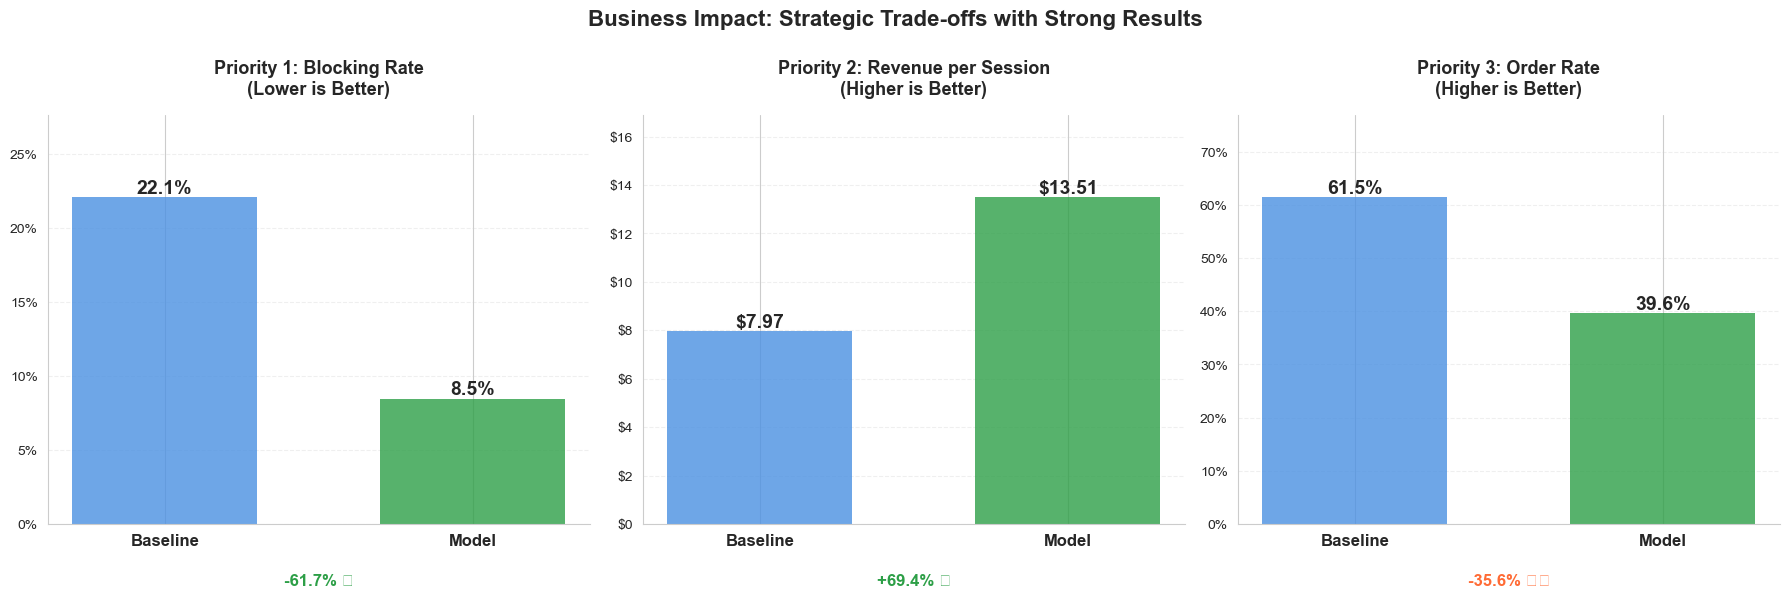


SLIDE 4: BUSINESS IMPACT

🎯 Priority 1 - Customer Experience (Blocking):
  Baseline: 22.1%
  Model:    8.5%
  Change:   -61.7% ✅ ACHIEVED

💰 Priority 2 - Maximize Profit (Revenue):
  Baseline: $7.97
  Model:    $13.51
  Change:   +69.4% ✅ ACHIEVED

📊 Priority 3 - Asset Utilization (Order Rate):
  Baseline: 61.5%
  Model:    39.6%
  Change:   -35.6% ⚠️ TRADE-OFF

OBJECTIVES ACHIEVED: 2/3

✓ Visualization saved as 'slide4_business_impact.png'


In [37]:
# Create figure with 3 panels for Slide 4
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Data from your simulation results
baseline_blocking = 0.2210
model_blocking = 0.0846

baseline_revenue = 7.9739
model_revenue = 13.5114

baseline_order = 0.6151
model_order = 0.3964

# Calculate percent changes
blocking_change = ((model_blocking - baseline_blocking) / baseline_blocking) * 100
revenue_change = ((model_revenue - baseline_revenue) / baseline_revenue) * 100
order_change = ((model_order - baseline_order) / baseline_order) * 100

# ============================================================================
# PANEL 1: Blocking Rate
# ============================================================================
ax = axes[0]

bars = ax.bar([0, 1], [baseline_blocking, model_blocking], width=0.6,
              color=['#4A90E2', '#2D9F47'], alpha=0.8, edgecolor='none')

# Add value labels
ax.text(0, baseline_blocking, f'{baseline_blocking:.1%}', 
        ha='center', va='bottom', fontweight='bold', fontsize=14)
ax.text(1, model_blocking, f'{model_blocking:.1%}', 
        ha='center', va='bottom', fontweight='bold', fontsize=14)

# Add percent change with status
change_color = '#2D9F47' if blocking_change < 0 else '#FF6B35'
status = '✅' if blocking_change < 0 else '❌'
ax.text(0.5, -0.12, f'{blocking_change:+.1f}% {status}', 
        ha='center', va='top', transform=ax.transAxes,
        fontsize=12, fontweight='bold', color=change_color)

# Formatting
ax.set_xticks([0, 1])
ax.set_xticklabels(['Baseline', 'Model'], fontsize=12, fontweight='bold')
ax.set_title('Priority 1: Blocking Rate\n(Lower is Better)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, max(baseline_blocking, model_blocking) * 1.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================================
# PANEL 2: Revenue per Session
# ============================================================================
ax = axes[1]

bars = ax.bar([0, 1], [baseline_revenue, model_revenue], width=0.6,
              color=['#4A90E2', '#2D9F47'], alpha=0.8, edgecolor='none')

# Add value labels
ax.text(0, baseline_revenue, f'${baseline_revenue:.2f}', 
        ha='center', va='bottom', fontweight='bold', fontsize=14)
ax.text(1, model_revenue, f'${model_revenue:.2f}', 
        ha='center', va='bottom', fontweight='bold', fontsize=14)

# Add percent change with status
change_color = '#2D9F47' if revenue_change > 0 else '#FF6B35'
status = '✅' if revenue_change > 0 else '❌'
ax.text(0.5, -0.12, f'{revenue_change:+.1f}% {status}', 
        ha='center', va='top', transform=ax.transAxes,
        fontsize=12, fontweight='bold', color=change_color)

# Formatting
ax.set_xticks([0, 1])
ax.set_xticklabels(['Baseline', 'Model'], fontsize=12, fontweight='bold')
ax.set_title('Priority 2: Revenue per Session\n(Higher is Better)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, max(baseline_revenue, model_revenue) * 1.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:.0f}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================================
# PANEL 3: Order Rate
# ============================================================================
ax = axes[2]

bars = ax.bar([0, 1], [baseline_order, model_order], width=0.6,
              color=['#4A90E2', '#2D9F47'], alpha=0.8, edgecolor='none')

# Add value labels
ax.text(0, baseline_order, f'{baseline_order:.1%}', 
        ha='center', va='bottom', fontweight='bold', fontsize=14)
ax.text(1, model_order, f'{model_order:.1%}', 
        ha='center', va='bottom', fontweight='bold', fontsize=14)

# Add percent change with status - warning for significant drop
change_color = '#2D9F47' if order_change > -15 else '#FF6B35'
status = '✅' if order_change > -15 else '⚠️'
ax.text(0.5, -0.12, f'{order_change:+.1f}% {status}', 
        ha='center', va='top', transform=ax.transAxes,
        fontsize=12, fontweight='bold', color=change_color)

# Formatting
ax.set_xticks([0, 1])
ax.set_xticklabels(['Baseline', 'Model'], fontsize=12, fontweight='bold')
ax.set_title('Priority 3: Order Rate\n(Higher is Better)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, max(baseline_order, model_order) * 1.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================================
# Overall title and save
# ============================================================================
fig.suptitle('Business Impact: Strategic Trade-offs with Strong Results', 
             fontsize=16, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig('slide4_business_impact.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n" + "="*80)
print("SLIDE 4: BUSINESS IMPACT")
print("="*80)

print("\n🎯 Priority 1 - Customer Experience (Blocking):")
print(f"  Baseline: {baseline_blocking:.1%}")
print(f"  Model:    {model_blocking:.1%}")
print(f"  Change:   {blocking_change:+.1f}% {'✅ ACHIEVED' if blocking_change < 0 else '❌'}")

print("\n💰 Priority 2 - Maximize Profit (Revenue):")
print(f"  Baseline: ${baseline_revenue:.2f}")
print(f"  Model:    ${model_revenue:.2f}")
print(f"  Change:   {revenue_change:+.1f}% {'✅ ACHIEVED' if revenue_change > 0 else '❌'}")

print("\n📊 Priority 3 - Asset Utilization (Order Rate):")
print(f"  Baseline: {baseline_order:.1%}")
print(f"  Model:    {model_order:.1%}")
print(f"  Change:   {order_change:+.1f}% {'⚠️ TRADE-OFF' if order_change < -20 else '✅'}")

objectives_met = sum([
    blocking_change < 0,
    revenue_change > 0,
    order_change > -20
])

print(f"\n{'='*80}")
print(f"OBJECTIVES ACHIEVED: {objectives_met}/3")

print(f"{'='*80}")
print("\n✓ Visualization saved as 'slide4_business_impact.png'")

#### Presentation Recommendations

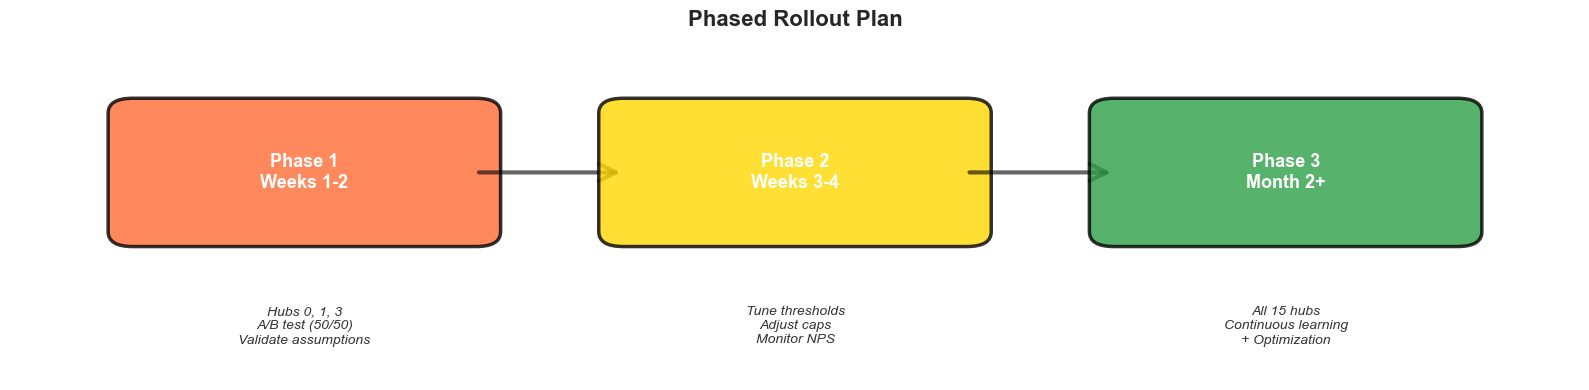

✓ Timeline saved as 'slide5_timeline.png'


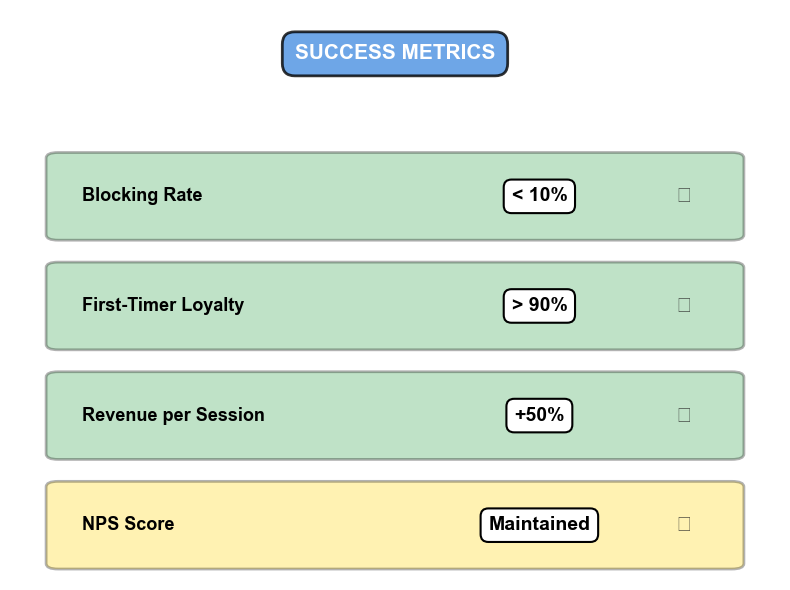

✓ Success metrics saved as 'slide5_success_metrics.png'


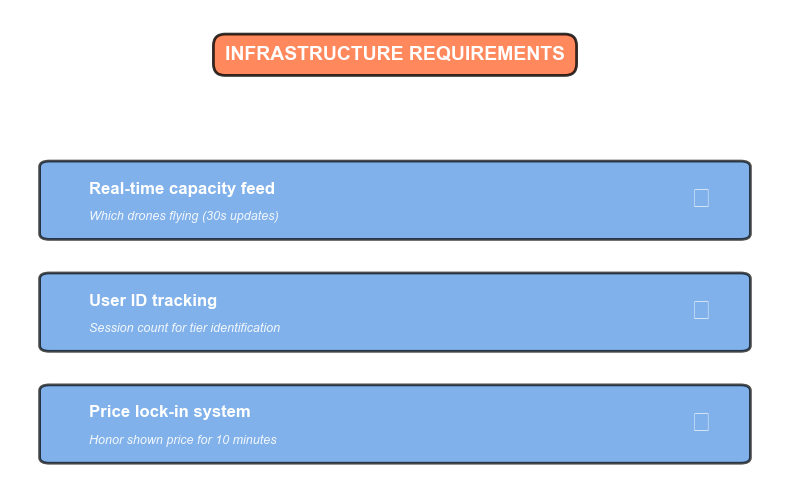

✓ Requirements saved as 'slide5_requirements.png'


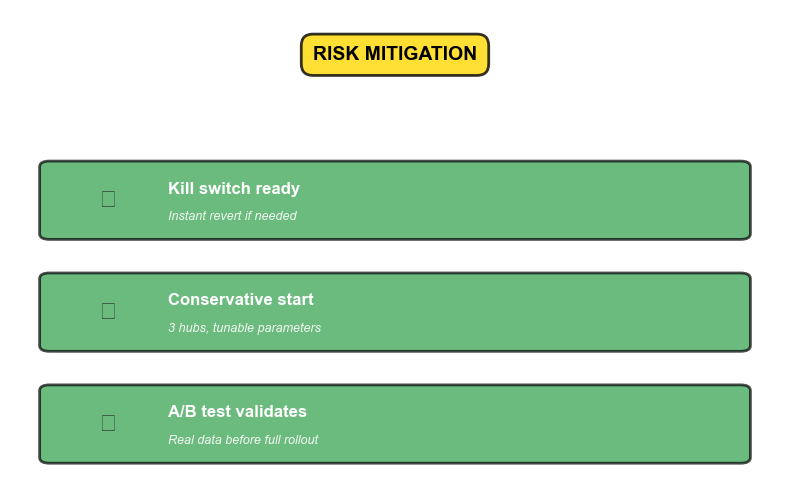

✓ Risk mitigation saved as 'slide5_risk_mitigation.png'

SLIDE 5 VISUALIZATIONS CREATED

4 visualizations saved:
  1. slide5_timeline.png - Three-phase rollout
  2. slide5_success_metrics.png - Go/no-go criteria
  3. slide5_requirements.png - Infrastructure needs
  4. slide5_risk_mitigation.png - How we reduce risk

Arrange on slide in 2x2 grid or as needed


In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

# ============================================================================
# VISUALIZATION 1: Three-Phase Timeline
# ============================================================================
fig1, ax = plt.subplots(1, 1, figsize=(16, 4))

# Phase data
phases = ['Phase 1\nWeeks 1-2', 'Phase 2\nWeeks 3-4', 'Phase 3\nMonth 2+']
x_positions = [0, 1, 2]
colors = ['#FF6B35', '#FFD700', '#2D9F47']

# Draw timeline
for i, (phase, x_pos, color) in enumerate(zip(phases, x_positions, colors)):
    # Main box
    box = FancyBboxPatch((x_pos - 0.35, 0.3), 0.7, 0.4, 
                          boxstyle="round,pad=0.05", 
                          edgecolor='black', facecolor=color, 
                          linewidth=2.5, alpha=0.8)
    ax.add_patch(box)
    
    # Phase title
    ax.text(x_pos, 0.5, phase, ha='center', va='center', 
            fontweight='bold', fontsize=13, color='white')
    
    # Arrow to next phase
    if i < len(phases) - 1:
        arrow = FancyArrowPatch((x_pos + 0.35, 0.5), (x_pos + 0.65, 0.5),
                               arrowstyle='->', mutation_scale=30, 
                               linewidth=3, color='black', alpha=0.6)
        ax.add_patch(arrow)

# Add details below each phase
details = [
    'Hubs 0, 1, 3\nA/B test (50/50)\nValidate assumptions',
    'Tune thresholds\nAdjust caps\nMonitor NPS',
    'All 15 hubs\nContinuous learning\n+ Optimization'
]

for x_pos, detail in zip(x_positions, details):
    ax.text(x_pos, 0.05, detail, ha='center', va='top', 
            fontsize=10, style='italic', color='#333333')

# Formatting
ax.set_xlim(-0.6, 2.6)
ax.set_ylim(-0.2, 0.9)
ax.axis('off')
ax.set_title('Phased Rollout Plan', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('slide5_timeline.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Timeline saved as 'slide5_timeline.png'")

# ============================================================================
# VISUALIZATION 2: Success Metrics Box
# ============================================================================
fig2, ax = plt.subplots(1, 1, figsize=(8, 6))

# Data
metrics = [
    'Blocking Rate',
    'First-Timer Loyalty',
    'Revenue per Session',
    'NPS Score'
]
targets = [
    '< 10%',
    '> 90%',
    '+50%',
    'Maintained'
]
icons = ['✅', '✅', '✅', '✅']
colors = ['#2D9F47', '#2D9F47', '#2D9F47', '#FFD700']

y_positions = np.arange(len(metrics))

# Create horizontal layout
for i, (metric, target, icon, color) in enumerate(zip(metrics, targets, icons, colors)):
    y = len(metrics) - i - 1  # Reverse order (top to bottom)
    
    # Background box
    box = FancyBboxPatch((0, y - 0.35), 2.8, 0.7,
                         boxstyle="round,pad=0.05",
                         edgecolor='black', facecolor=color,
                         linewidth=2, alpha=0.3)
    ax.add_patch(box)
    
    # Metric name
    ax.text(0.1, y, metric, ha='left', va='center',
            fontweight='bold', fontsize=13, color='black')
    
    # Target value
    ax.text(2.0, y, target, ha='center', va='center',
            fontweight='bold', fontsize=14, color='black',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                     edgecolor='black', linewidth=1.5))
    
    # Icon
    ax.text(2.6, y, icon, ha='center', va='center', fontsize=16)

# Title
ax.text(1.4, len(metrics) + 0.3, 'SUCCESS METRICS', 
        ha='center', va='center', fontweight='bold', fontsize=15,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#4A90E2',
                 edgecolor='black', linewidth=2, alpha=0.8),
        color='white')

ax.set_xlim(-0.2, 3.0)
ax.set_ylim(-0.5, len(metrics) + 0.7)
ax.axis('off')

plt.tight_layout()
plt.savefig('slide5_success_metrics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Success metrics saved as 'slide5_success_metrics.png'")

# ============================================================================
# VISUALIZATION 3: Requirements Box
# ============================================================================
fig3, ax = plt.subplots(1, 1, figsize=(8, 5))

requirements = [
    ('Real-time capacity feed', 'Which drones flying (30s updates)'),
    ('User ID tracking', 'Session count for tier identification'),
    ('Price lock-in system', 'Honor shown price for 10 minutes')
]

for i, (req, detail) in enumerate(requirements):
    y = len(requirements) - i - 1
    
    # Main requirement box
    box = FancyBboxPatch((0, y - 0.3), 3.5, 0.6,
                         boxstyle="round,pad=0.05",
                         edgecolor='black', facecolor='#4A90E2',
                         linewidth=2, alpha=0.7)
    ax.add_patch(box)
    
    # Requirement text
    ax.text(0.2, y + 0.1, req, ha='left', va='center',
            fontweight='bold', fontsize=12, color='white')
    
    # Detail text
    ax.text(0.2, y - 0.15, detail, ha='left', va='center',
            fontsize=9, style='italic', color='white', alpha=0.9)
    
    # Checkbox
    ax.text(3.3, y, '☐', ha='center', va='center',
            fontsize=20, color='white', fontweight='bold')

# Title
ax.text(1.75, len(requirements) + 0.3, 'INFRASTRUCTURE REQUIREMENTS',
        ha='center', va='center', fontweight='bold', fontsize=14,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#FF6B35',
                 edgecolor='black', linewidth=2, alpha=0.8),
        color='white')

ax.set_xlim(-0.2, 3.7)
ax.set_ylim(-0.5, len(requirements) + 0.7)
ax.axis('off')

plt.tight_layout()
plt.savefig('slide5_requirements.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Requirements saved as 'slide5_requirements.png'")

# ============================================================================
# VISUALIZATION 4: Risk Mitigation Box
# ============================================================================
fig4, ax = plt.subplots(1, 1, figsize=(8, 5))

mitigations = [
    ('Kill switch ready', '🛑', 'Instant revert if needed'),
    ('Conservative start', '🐢', '3 hubs, tunable parameters'),
    ('A/B test validates', '🧪', 'Real data before full rollout')
]

for i, (mitigation, icon, detail) in enumerate(mitigations):
    y = len(mitigations) - i - 1
    
    # Background box
    box = FancyBboxPatch((0, y - 0.3), 3.5, 0.6,
                         boxstyle="round,pad=0.05",
                         edgecolor='black', facecolor='#2D9F47',
                         linewidth=2, alpha=0.7)
    ax.add_patch(box)
    
    # Icon
    ax.text(0.3, y, icon, ha='center', va='center', fontsize=18)
    
    # Mitigation text
    ax.text(0.6, y + 0.1, mitigation, ha='left', va='center',
            fontweight='bold', fontsize=12, color='white')
    
    # Detail text
    ax.text(0.6, y - 0.15, detail, ha='left', va='center',
            fontsize=9, style='italic', color='white', alpha=0.9)

# Title
ax.text(1.75, len(mitigations) + 0.3, 'RISK MITIGATION',
        ha='center', va='center', fontweight='bold', fontsize=14,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFD700',
                 edgecolor='black', linewidth=2, alpha=0.8),
        color='black')

ax.set_xlim(-0.2, 3.7)
ax.set_ylim(-0.5, len(mitigations) + 0.7)
ax.axis('off')

plt.tight_layout()
plt.savefig('slide5_risk_mitigation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Risk mitigation saved as 'slide5_risk_mitigation.png'")

# ============================================================================
# Summary
# ============================================================================
print("\n" + "="*80)
print("SLIDE 5 VISUALIZATIONS CREATED")
print("="*80)
print("\n4 visualizations saved:")
print("  1. slide5_timeline.png - Three-phase rollout")
print("  2. slide5_success_metrics.png - Go/no-go criteria")
print("  3. slide5_requirements.png - Infrastructure needs")
print("  4. slide5_risk_mitigation.png - How we reduce risk")
print("\nArrange on slide in 2x2 grid or as needed")
print("="*80)

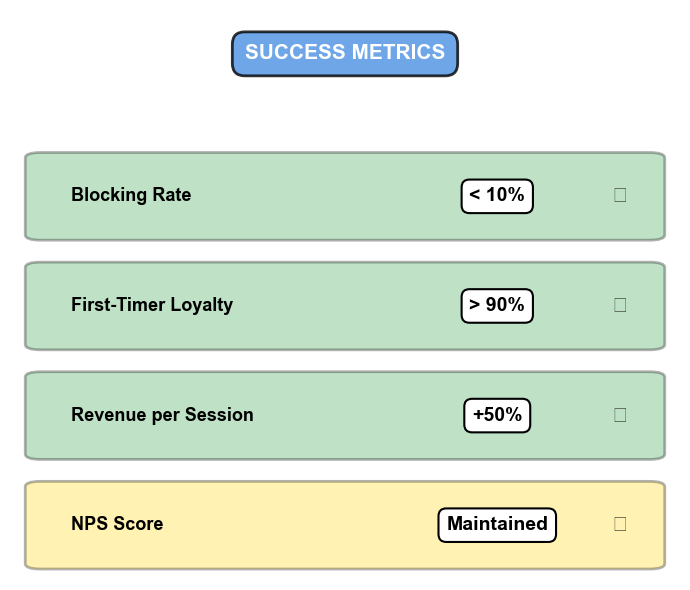

✓ Success metrics saved as 'slide5_success_metrics.png'

Metrics included:
  ✅ Blocking Rate: < 10%
  ✅ First-Timer Loyalty: > 90%
  ✅ Revenue per Session: +50%
  ✅ NPS Score: Maintained


In [39]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ============================================================================
# Success Metrics Box
# ============================================================================
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# Data
metrics = [
    'Blocking Rate',
    'First-Timer Loyalty',
    'Revenue per Session',
    'NPS Score'
]
targets = [
    '< 10%',
    '> 90%',
    '+50%',
    'Maintained'
]
icons = ['✅', '✅', '✅', '✅']
colors = ['#2D9F47', '#2D9F47', '#2D9F47', '#FFD700']

y_positions = np.arange(len(metrics))

# Create horizontal layout
for i, (metric, target, icon, color) in enumerate(zip(metrics, targets, icons, colors)):
    y = len(metrics) - i - 1  # Reverse order (top to bottom)
    
    # Background box
    box = FancyBboxPatch((0, y - 0.35), 2.0, 0.7,
                         boxstyle="round,pad=0.05",
                         edgecolor='black', facecolor=color,
                         linewidth=2, alpha=0.3)
    ax.add_patch(box)
    
    # Metric name
    ax.text(0.1, y, metric, ha='left', va='center',
            fontweight='bold', fontsize=13, color='black')
    
    # Target value with white background box
    ax.text(1.5, y, target, ha='center', va='center',
            fontweight='bold', fontsize=14, color='black',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                     edgecolor='black', linewidth=1.5))
    
    # Icon (no box around it)
    ax.text(1.9, y, icon, ha='center', va='center', fontsize=16)

# Title
ax.text(1.0, len(metrics) + 0.3, 'SUCCESS METRICS', 
        ha='center', va='center', fontweight='bold', fontsize=15,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#4A90E2',
                 edgecolor='black', linewidth=2, alpha=0.8),
        color='white')

ax.set_xlim(-0.1, 2.1)
ax.set_ylim(-0.5, len(metrics) + 0.7)
ax.axis('off')

plt.tight_layout()
plt.savefig('slide5_success_metrics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Success metrics saved as 'slide5_success_metrics.png'")
print("\nMetrics included:")
for metric, target, icon in zip(metrics, targets, icons):
    print(f"  {icon} {metric}: {target}")

#### Presentation - future ideas

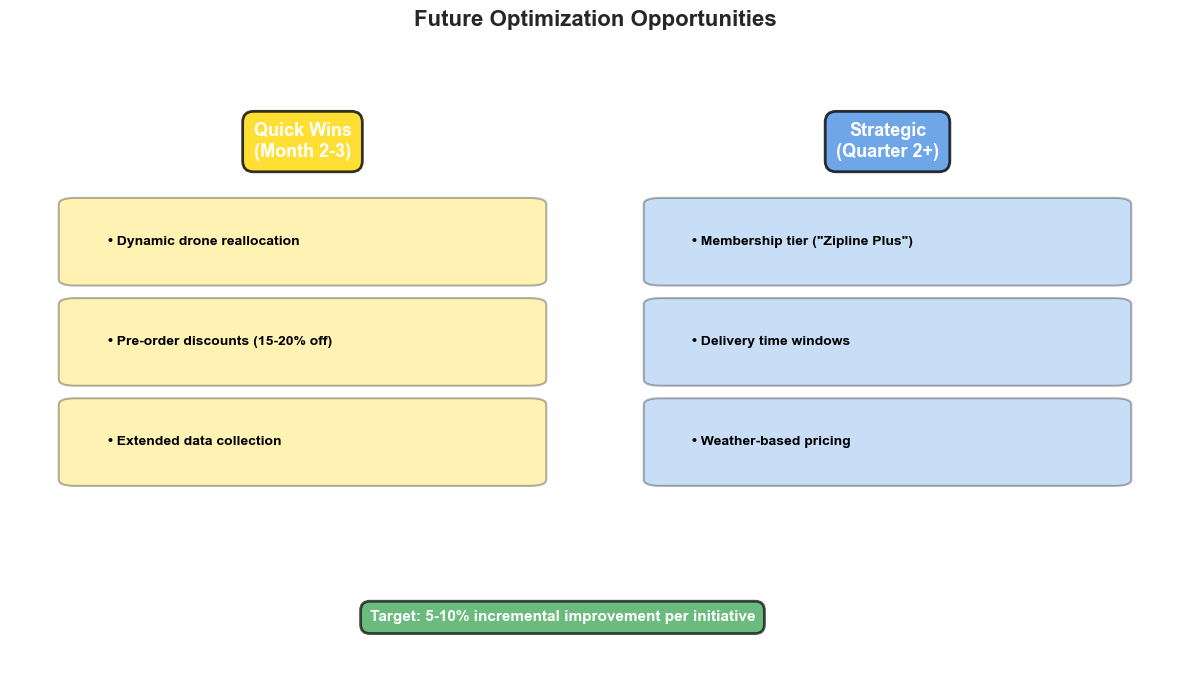

✓ Slide 6 visual saved as 'slide6_future_opportunities.png'

Recommendations included:

Quick Wins (Month 2-3):
  • Dynamic drone reallocation
  • Pre-order discounts (15-20% off)
  • Extended data collection

Strategic (Quarter 2+):
  • Membership tier ('Zipline Plus')
  • Delivery time windows
  • Weather-based pricing


In [40]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Categories and items
categories = ['Quick Wins\n(Month 2-3)', 'Strategic\n(Quarter 2+)']
items = [
    ['Dynamic drone reallocation', 'Pre-order discounts (15-20% off)', 'Extended data collection'],
    ['Membership tier ("Zipline Plus")', 'Delivery time windows', 'Weather-based pricing']
]
colors = ['#FFD700', '#4A90E2']

x_pos = [0, 1.8]

for i, (category, item_list, color, x) in enumerate(zip(categories, items, colors, x_pos)):
    # Category header
    ax.text(x + 0.7, 3.5, category, ha='center', va='center',
            fontweight='bold', fontsize=13,
            bbox=dict(boxstyle='round,pad=0.6', facecolor=color,
                     edgecolor='black', linewidth=2, alpha=0.8),
            color='white')
    
    # Items
    for j, item in enumerate(item_list):
        y = 2.7 - j * 0.8
        
        # Box
        box = FancyBboxPatch((x, y - 0.3), 1.4, 0.6,
                            boxstyle="round,pad=0.05",
                            edgecolor='black', facecolor=color,
                            linewidth=1.5, alpha=0.3)
        ax.add_patch(box)
        
        # Text
        ax.text(x + 0.1, y, f'• {item}', ha='left', va='center',
                fontsize=10, fontweight='bold', color='black')

# Bottom callout
ax.text(1.5, -0.3, 'Target: 5-10% incremental improvement per initiative',
        ha='center', va='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#2D9F47',
                 edgecolor='black', linewidth=2, alpha=0.7),
        color='white')

ax.set_xlim(-0.2, 3.4)
ax.set_ylim(-0.8, 4.2)
ax.axis('off')
ax.set_title('Future Optimization Opportunities', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('slide6_future_opportunities.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Slide 6 visual saved as 'slide6_future_opportunities.png'")
print("\nRecommendations included:")
print("\nQuick Wins (Month 2-3):")
print("  • Dynamic drone reallocation")
print("  • Pre-order discounts (15-20% off)")
print("  • Extended data collection")
print("\nStrategic (Quarter 2+):")
print("  • Membership tier ('Zipline Plus')")
print("  • Delivery time windows")
print("  • Weather-based pricing")

### Supply Analyses

* How distance impacts delivery capacity/hour

DISTANCE IMPACT ANALYSIS

1. DISTANCE IMPACT ON DELIVERY CAPACITY
                 avg_distance  avg_delivery_time_min  avg_capacity_units  \
distance_bucket                                                            
0-3mi                   2.522                  9.324               0.155   
3-5mi                   4.055                 11.951               0.199   
5-7mi                   6.055                 15.379               0.256   
7-9mi                   8.045                 18.792               0.313   
9-12mi                 10.523                 23.040               0.384   
12+mi                     NaN                    NaN                 NaN   

                 orders  total_sessions  conversion_rate  
distance_bucket                                           
0-3mi              3217            6213            0.518  
3-5mi              6191           12132            0.510  
5-7mi              5961           11815            0.505  
7-9mi              6123       

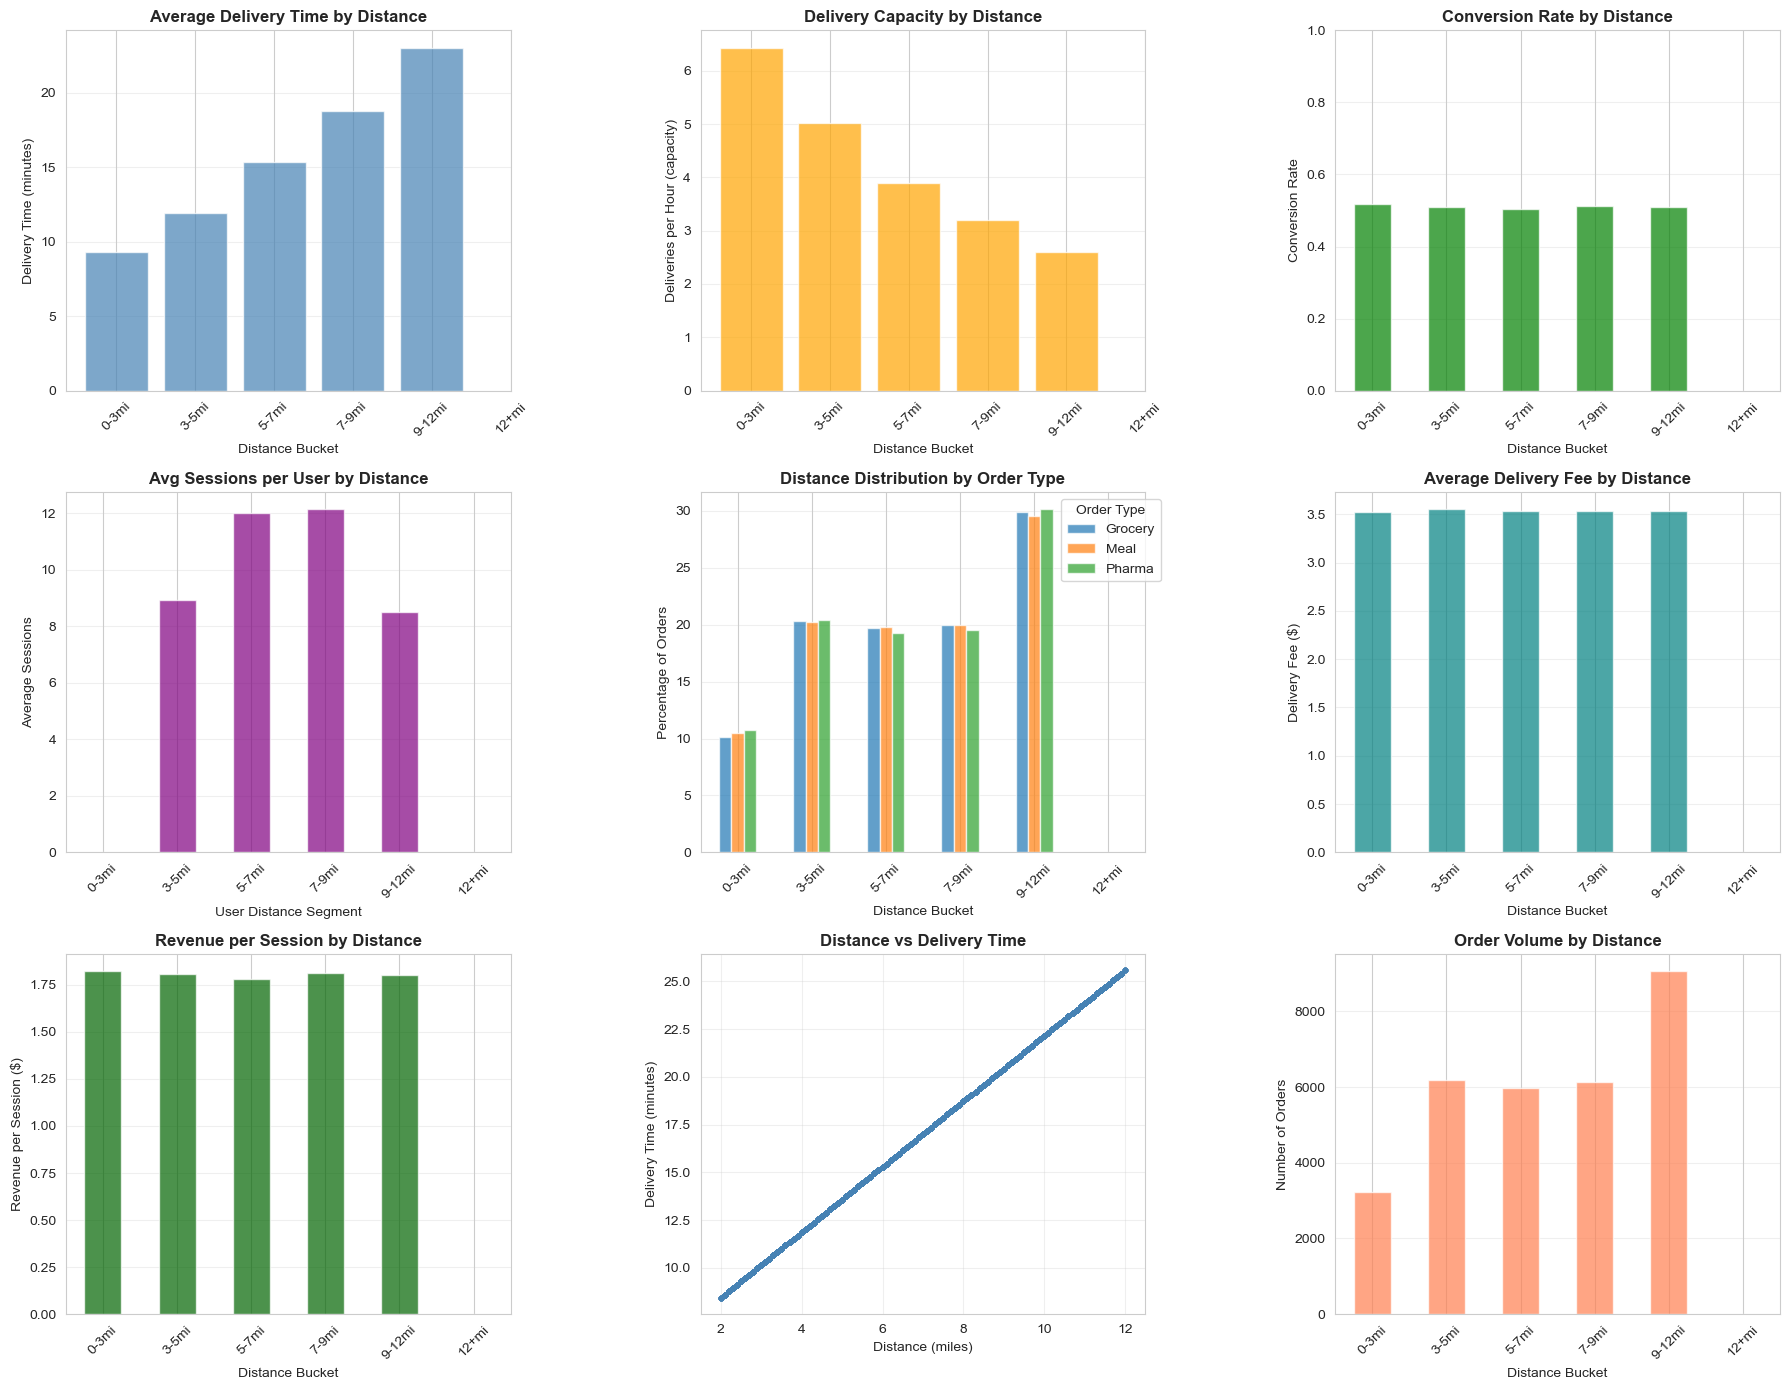


KEY INSIGHTS: DISTANCE IMPACT

1. CAPACITY IMPACT:
   Short distance (3-5mi): 5.0 deliveries/hour
   Long distance (9-12mi): 2.6 deliveries/hour
   Capacity reduction: 93% for long distances

2. ENGAGEMENT IMPACT:
   Short distance users: 8.9 avg sessions
   Long distance users: 8.5 avg sessions
   Difference: -5%

3. REVENUE IMPACT:
   Short distance: $1.81/session
   Long distance: $1.80/session
   Difference: -1%

4. ORDER TYPE PATTERNS:
   Grocery: 7.0 miles average
   Meal: 7.0 miles average
   Pharma: 7.0 miles average

5. RECOMMENDATION FOR DYNAMIC PRICING:
   ⚠️  Long distances significantly reduce capacity
   → Consider distance-based pricing multiplier
   ✓ Distance doesn't significantly affect engagement
   → Safe to implement distance-based pricing


In [41]:
# Distance impact analysis
print("DISTANCE IMPACT ANALYSIS")
print("="*80)

# Calculate delivery time and capacity units first
session_df['delivery_time_min'] = session_df['distance_miles'].apply(
    lambda x: 2 + 1 + ((x * 2) / 70 * 60) + 1 + 1  # loading + undock + flight + dock + delivery
)
session_df['capacity_units'] = session_df['delivery_time_min'] / 60

# Now continue with the analysis
distance_bins = [0, 3, 5, 7, 9, 12, 100]
distance_labels = ['0-3mi', '3-5mi', '5-7mi', '7-9mi', '9-12mi', '12+mi']

session_df['distance_bucket'] = pd.cut(session_df['distance_miles'], 
                                        bins=distance_bins, 
                                        labels=distance_labels)

# Calculate average delivery time by distance bucket
distance_capacity = session_df.groupby('distance_bucket').agg({
    'distance_miles': 'mean',
    'delivery_time_min': 'mean',
    'capacity_units': 'mean',
    'converted': ['sum', 'count', 'mean']
})

# 1. Distance and delivery capacity/time
print("\n1. DISTANCE IMPACT ON DELIVERY CAPACITY")
print("="*80)

# Calculate delivery time components
def detailed_delivery_time(distance_miles):
    """
    Breakdown of delivery time:
    - 2 min loading
    - 1 min undock/transition to cruise
    - Flight time (round trip at 70 mph)
    - 1 min transition from cruise to dock
    - 1 min delivery
    """
    flight_time = (distance_miles * 2) / 70 * 60  # Round trip in minutes
    loading = 2
    transitions = 1 + 1  # Undock + dock
    delivery = 1
    total = loading + transitions + flight_time + delivery
    
    return {
        'flight_time': flight_time,
        'fixed_time': loading + transitions + delivery,
        'total_time': total,
        'capacity_units': total / 60  # Convert to hours
    }

# Analyze distribution
distance_bins = [0, 3, 5, 7, 9, 12, 100]
distance_labels = ['0-3mi', '3-5mi', '5-7mi', '7-9mi', '9-12mi', '12+mi']

session_df['distance_bucket'] = pd.cut(session_df['distance_miles'], 
                                        bins=distance_bins, 
                                        labels=distance_labels)

# Calculate average delivery time by distance bucket
distance_capacity = session_df.groupby('distance_bucket').agg({
    'distance_miles': 'mean',
    'delivery_time_min': 'mean',
    'capacity_units': 'mean',
    'converted': ['sum', 'count', 'mean']
})
distance_capacity.columns = ['avg_distance', 'avg_delivery_time_min', 'avg_capacity_units', 
                             'orders', 'total_sessions', 'conversion_rate']

print(distance_capacity.round(3))

# Show capacity impact
print("\nCapacity Impact:")
for idx, row in distance_capacity.iterrows():
    deliveries_per_hour = 1 / row['avg_capacity_units']
    print(f"{idx}: {deliveries_per_hour:.1f} deliveries/hour capacity "
          f"({row['avg_delivery_time_min']:.1f} min/delivery)")

# 2. Distance and customer engagement
print("\n" + "="*80)
print("2. DISTANCE IMPACT ON CUSTOMER ENGAGEMENT")
print("="*80)

# Get user-level distance patterns
user_distance_behavior = session_df.groupby('user_id').agg({
    'distance_miles': 'mean',
    'converted': ['sum', 'count', 'mean'],
    'session_outcome': lambda x: (x == 'blocked').sum(),
    'timestamp': lambda x: (x.max() - x.min()).days
}).reset_index()

user_distance_behavior.columns = ['user_id', 'avg_distance', 'total_orders', 'total_sessions', 
                                   'conversion_rate', 'times_blocked', 'days_active']

# Create distance segments
user_distance_behavior['distance_segment'] = pd.cut(
    user_distance_behavior['avg_distance'],
    bins=distance_bins,
    labels=distance_labels
)

engagement_by_distance = user_distance_behavior.groupby('distance_segment').agg({
    'total_sessions': 'mean',
    'total_orders': 'mean',
    'conversion_rate': 'mean',
    'times_blocked': 'mean',
    'days_active': 'mean'
})
engagement_by_distance['user_count'] = user_distance_behavior.groupby('distance_segment').size()

print(engagement_by_distance.round(3))

# 3. Distance by order type
print("\n" + "="*80)
print("3. DISTANCE PATTERNS BY ORDER TYPE")
print("="*80)

distance_by_type = session_df.groupby('order_type').agg({
    'distance_miles': ['mean', 'median', 'std', 'min', 'max', 'count']
})
distance_by_type.columns = ['mean', 'median', 'std', 'min', 'max', 'count']

print(distance_by_type.round(2))

# Distance distribution by order type
type_distance_dist = session_df.groupby(['order_type', 'distance_bucket']).size().unstack(fill_value=0)
type_distance_pct = type_distance_dist.div(type_distance_dist.sum(axis=1), axis=0) * 100

print("\nDistance Distribution by Order Type (%):")
print(type_distance_pct.round(1))

# 4. Distance and delivery fee revenue
print("\n" + "="*80)
print("4. DISTANCE IMPACT ON DELIVERY FEE REVENUE")
print("="*80)

# Revenue analysis by distance
revenue_by_distance = session_df[session_df['converted']==1].groupby('distance_bucket').agg({
    'delivery_fee': ['mean', 'median', 'std'],
    'subtotal': ['mean', 'median'],
    'converted': 'count'
}).round(2)
revenue_by_distance.columns = ['avg_delivery_fee', 'median_delivery_fee', 'std_delivery_fee',
                               'avg_subtotal', 'median_subtotal', 'order_count']

print(revenue_by_distance)

# Total revenue potential by distance segment
all_sessions_distance = session_df.groupby('distance_bucket').agg({
    'converted': ['sum', 'count', 'mean'],
    'delivery_fee': lambda x: x[session_df.loc[x.index, 'converted']==1].sum()
})
all_sessions_distance.columns = ['orders', 'total_sessions', 'conversion_rate', 'total_revenue']
all_sessions_distance['revenue_per_session'] = all_sessions_distance['total_revenue'] / all_sessions_distance['total_sessions']

print("\nRevenue per Session by Distance:")
print(all_sessions_distance[['conversion_rate', 'revenue_per_session', 'orders', 'total_sessions']].round(3))

# 5. Visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Plot 1: Delivery time by distance
axes[0, 0].bar(range(len(distance_capacity)), distance_capacity['avg_delivery_time_min'], 
              color='steelblue', alpha=0.7)
axes[0, 0].set_title('Average Delivery Time by Distance', fontweight='bold')
axes[0, 0].set_ylabel('Delivery Time (minutes)')
axes[0, 0].set_xlabel('Distance Bucket')
axes[0, 0].set_xticks(range(len(distance_capacity)))
axes[0, 0].set_xticklabels(distance_capacity.index, rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Deliveries per hour capacity by distance
deliveries_per_hour = 1 / distance_capacity['avg_capacity_units']
axes[0, 1].bar(range(len(deliveries_per_hour)), deliveries_per_hour, color='orange', alpha=0.7)
axes[0, 1].set_title('Delivery Capacity by Distance', fontweight='bold')
axes[0, 1].set_ylabel('Deliveries per Hour (capacity)')
axes[0, 1].set_xlabel('Distance Bucket')
axes[0, 1].set_xticks(range(len(deliveries_per_hour)))
axes[0, 1].set_xticklabels(distance_capacity.index, rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Conversion rate by distance
distance_capacity['conversion_rate'].plot(kind='bar', ax=axes[0, 2], color='green', alpha=0.7)
axes[0, 2].set_title('Conversion Rate by Distance', fontweight='bold')
axes[0, 2].set_ylabel('Conversion Rate')
axes[0, 2].set_xlabel('Distance Bucket')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3)
axes[0, 2].set_ylim(0, 1)

# Plot 4: User engagement by distance
engagement_by_distance['total_sessions'].plot(kind='bar', ax=axes[1, 0], color='purple', alpha=0.7)
axes[1, 0].set_title('Avg Sessions per User by Distance', fontweight='bold')
axes[1, 0].set_ylabel('Average Sessions')
axes[1, 0].set_xlabel('User Distance Segment')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 5: Distance distribution by order type
type_distance_pct.T.plot(kind='bar', ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('Distance Distribution by Order Type', fontweight='bold')
axes[1, 1].set_ylabel('Percentage of Orders')
axes[1, 1].set_xlabel('Distance Bucket')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Order Type', bbox_to_anchor=(1.05, 1))
axes[1, 1].grid(axis='y', alpha=0.3)

# Plot 6: Delivery fee by distance
revenue_by_distance['avg_delivery_fee'].plot(kind='bar', ax=axes[1, 2], color='teal', alpha=0.7)
axes[1, 2].set_title('Average Delivery Fee by Distance', fontweight='bold')
axes[1, 2].set_ylabel('Delivery Fee ($)')
axes[1, 2].set_xlabel('Distance Bucket')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(axis='y', alpha=0.3)

# Plot 7: Revenue per session by distance
all_sessions_distance['revenue_per_session'].plot(kind='bar', ax=axes[2, 0], color='darkgreen', alpha=0.7)
axes[2, 0].set_title('Revenue per Session by Distance', fontweight='bold')
axes[2, 0].set_ylabel('Revenue per Session ($)')
axes[2, 0].set_xlabel('Distance Bucket')
axes[2, 0].tick_params(axis='x', rotation=45)
axes[2, 0].grid(axis='y', alpha=0.3)

# Plot 8: Distance vs delivery time scatter
sample_data = session_df[session_df['converted']==1].sample(min(5000, len(session_df)), random_state=42)
axes[2, 1].scatter(sample_data['distance_miles'], sample_data['delivery_time_min'], 
                  alpha=0.3, s=10, color='steelblue')
axes[2, 1].set_title('Distance vs Delivery Time', fontweight='bold')
axes[2, 1].set_xlabel('Distance (miles)')
axes[2, 1].set_ylabel('Delivery Time (minutes)')
axes[2, 1].grid(alpha=0.3)

# Plot 9: Order volume by distance
distance_capacity['orders'].plot(kind='bar', ax=axes[2, 2], color='coral', alpha=0.7)
axes[2, 2].set_title('Order Volume by Distance', fontweight='bold')
axes[2, 2].set_ylabel('Number of Orders')
axes[2, 2].set_xlabel('Distance Bucket')
axes[2, 2].tick_params(axis='x', rotation=45)
axes[2, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Statistical significance
print("\n" + "="*80)
print("KEY INSIGHTS: DISTANCE IMPACT")
print("="*80)

# Capacity impact
short_capacity = distance_capacity.loc['3-5mi', 'avg_capacity_units']
long_capacity = distance_capacity.loc['9-12mi', 'avg_capacity_units']
capacity_diff = (long_capacity / short_capacity - 1) * 100

print(f"\n1. CAPACITY IMPACT:")
print(f"   Short distance (3-5mi): {1/short_capacity:.1f} deliveries/hour")
print(f"   Long distance (9-12mi): {1/long_capacity:.1f} deliveries/hour")
print(f"   Capacity reduction: {capacity_diff:.0f}% for long distances")

# Engagement impact
try:
    short_engagement = engagement_by_distance.loc['3-5mi', 'total_sessions']
    long_engagement = engagement_by_distance.loc['9-12mi', 'total_sessions']
    engagement_diff = ((long_engagement / short_engagement - 1) * 100) if pd.notna(short_engagement) and pd.notna(long_engagement) else 0
    
    print(f"\n2. ENGAGEMENT IMPACT:")
    print(f"   Short distance users: {short_engagement:.1f} avg sessions")
    print(f"   Long distance users: {long_engagement:.1f} avg sessions")
    print(f"   Difference: {engagement_diff:+.0f}%")
except:
    print(f"\n2. ENGAGEMENT IMPACT:")
    print(f"   Insufficient data for some distance segments")

# Revenue impact
short_revenue = all_sessions_distance.loc['3-5mi', 'revenue_per_session']
long_revenue = all_sessions_distance.loc['9-12mi', 'revenue_per_session']
revenue_diff = ((long_revenue / short_revenue - 1) * 100) if pd.notna(short_revenue) and pd.notna(long_revenue) else 0

print(f"\n3. REVENUE IMPACT:")
print(f"   Short distance: ${short_revenue:.2f}/session")
print(f"   Long distance: ${long_revenue:.2f}/session")
print(f"   Difference: {revenue_diff:+.0f}%")

# Order type patterns
print(f"\n4. ORDER TYPE PATTERNS:")
for order_type in distance_by_type.index:
    avg_dist = distance_by_type.loc[order_type, 'mean']
    print(f"   {order_type}: {avg_dist:.1f} miles average")

print("\n5. RECOMMENDATION FOR DYNAMIC PRICING:")
if capacity_diff > 30:
    print("   ⚠️  Long distances significantly reduce capacity")
    print("   → Consider distance-based pricing multiplier")
else:
    print("   ✓ Distance impact on capacity is moderate")
    print("   → Distance pricing adjustment optional")

if abs(engagement_diff) > 15:
    print(f"   ⚠️  Distance affects user engagement ({engagement_diff:+.0f}%)")
    print("   → Be careful with distance-based pricing (could hurt retention)")
else:
    print("   ✓ Distance doesn't significantly affect engagement")
    print("   → Safe to implement distance-based pricing")

#### Blocked Analysis by Hub

BLOCKED ORDERS ANALYSIS BY HUB

Outcomes by Hub:
session_outcome  abandoned  blocked  ordered  total  blocked_rate  \
nest_id                                                             
1                     2495      609     2416   5520      0.110326   
0                     2350      534     2344   5228      0.102142   
2                     2261      442     2325   5028      0.087908   
3                     2440      428     2301   5169      0.082801   
4                     1971      341     2005   4317      0.078990   
5                     2034       72     2647   4753      0.015148   
6                     2009       52     2448   4509      0.011532   
7                     1847       37     2271   4155      0.008905   
8                     1525       12     1977   3514      0.003415   
9                     1689        9     2114   3812      0.002361   
10                    1382        0     1823   3205      0.000000   
11                    1390        0     1636   3026   

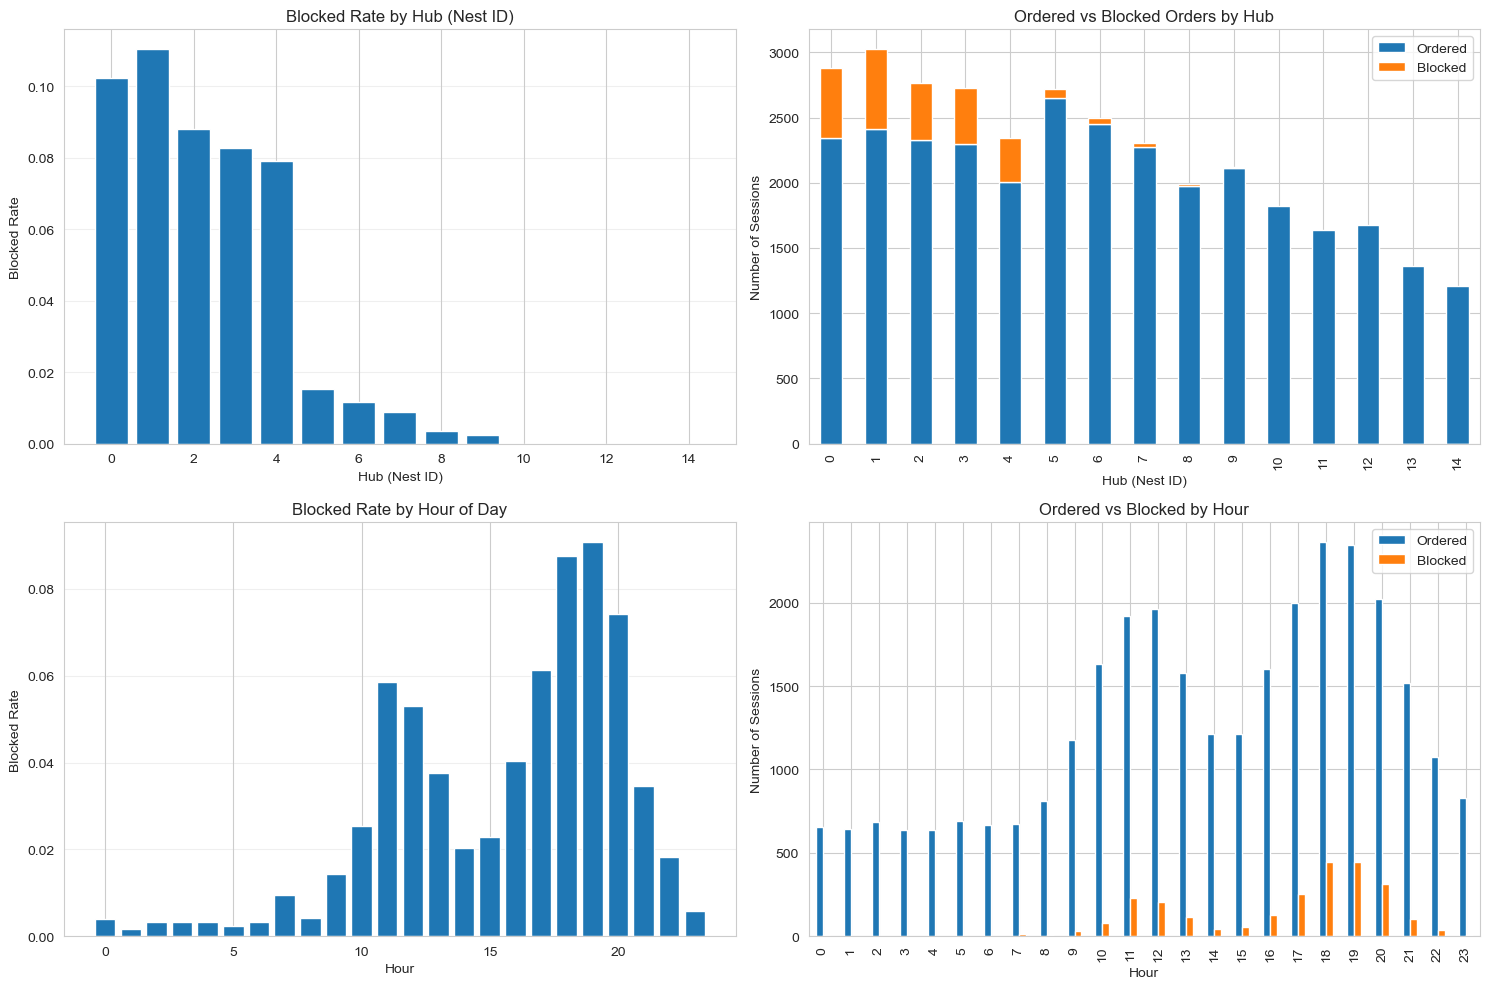


CAPACITY CORRELATION CHECK

Correlation between capacity used and blocked orders:
               capacity_used  blocked_count
capacity_used        1.00000        0.92679
blocked_count        0.92679        1.00000


In [42]:
# Analyze blocked orders by hub
print("BLOCKED ORDERS ANALYSIS BY HUB")
print("="*80)

# Count outcomes by hub
outcome_by_hub = session_df.groupby(['nest_id', 'session_outcome']).size().unstack(fill_value=0)
outcome_by_hub['total'] = outcome_by_hub.sum(axis=1)
outcome_by_hub['blocked_rate'] = outcome_by_hub['blocked'] / outcome_by_hub['total']
outcome_by_hub['ordered_rate'] = outcome_by_hub['ordered'] / outcome_by_hub['total']

print("\nOutcomes by Hub:")
print(outcome_by_hub.sort_values('blocked_rate', ascending=False))

# Check blocked orders by hour (capacity constraint indicator)
print("\n" + "="*80)
print("BLOCKED ORDERS BY HOUR (Potential Capacity Constraints)")
print("="*80)

blocked_by_hour = session_df[session_df['session_outcome']=='blocked'].groupby('hour').size()
ordered_by_hour = session_df[session_df['session_outcome']=='ordered'].groupby('hour').size()
total_by_hour = session_df.groupby('hour').size()

hour_analysis = pd.DataFrame({
    'blocked': blocked_by_hour,
    'ordered': ordered_by_hour,
    'total': total_by_hour
}).fillna(0)
hour_analysis['blocked_rate'] = hour_analysis['blocked'] / hour_analysis['total']

print(hour_analysis.sort_values('blocked_rate', ascending=False))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Blocked rate by hub
axes[0, 0].bar(outcome_by_hub.index, outcome_by_hub['blocked_rate'])
axes[0, 0].set_title('Blocked Rate by Hub (Nest ID)')
axes[0, 0].set_xlabel('Hub (Nest ID)')
axes[0, 0].set_ylabel('Blocked Rate')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Ordered vs Blocked by hub
outcome_by_hub[['ordered', 'blocked']].plot(kind='bar', ax=axes[0, 1], stacked=True)
axes[0, 1].set_title('Ordered vs Blocked Orders by Hub')
axes[0, 1].set_xlabel('Hub (Nest ID)')
axes[0, 1].set_ylabel('Number of Sessions')
axes[0, 1].legend(['Ordered', 'Blocked'])

# Plot 3: Blocked rate by hour
axes[1, 0].bar(hour_analysis.index, hour_analysis['blocked_rate'])
axes[1, 0].set_title('Blocked Rate by Hour of Day')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Blocked Rate')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Ordered vs Blocked by hour
hour_analysis[['ordered', 'blocked']].plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Ordered vs Blocked by Hour')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Number of Sessions')
axes[1, 1].legend(['Ordered', 'Blocked'])

plt.tight_layout()
plt.show()

# Check correlation between blocked and capacity demand
print("\n" + "="*80)
print("CAPACITY CORRELATION CHECK")
print("="*80)
capacity_by_hour = session_df[session_df['converted']==1].groupby('hour')['capacity_units'].sum()
correlation = pd.DataFrame({
    'capacity_used': capacity_by_hour,
    'blocked_count': blocked_by_hour
}).fillna(0).corr()

print("\nCorrelation between capacity used and blocked orders:")
print(correlation)

### Pricing Analyses

* Fee by order type

DELIVERY FEE & PRICE SENSITIVITY ANALYSIS

TRUE CONVERSION RATE BY PRICE AND ORDER TYPE
                      total_sessions  ordered  blocked  abandoned  \
order_type price_bin                                                
Grocery    $0-1.5               3072     1322      124       1626   
           $1.5-2.5             3114     1262      114       1738   
           $2.5-3.5             3121     1206      113       1802   
           $3.5-4.5             2751     1032       89       1630   
           $4.5+                5889     2087      146       3656   
Meal       $0-1.5               6039     3330      323       2386   
           $1.5-2.5             6014     3223      289       2502   
           $2.5-3.5             6399     3346      291       2762   
           $3.5-4.5             5696     2874      223       2599   
           $4.5+               11830     5810      399       5621   
Pharma     $0-1.5                972      813       84         75   
           $1.5

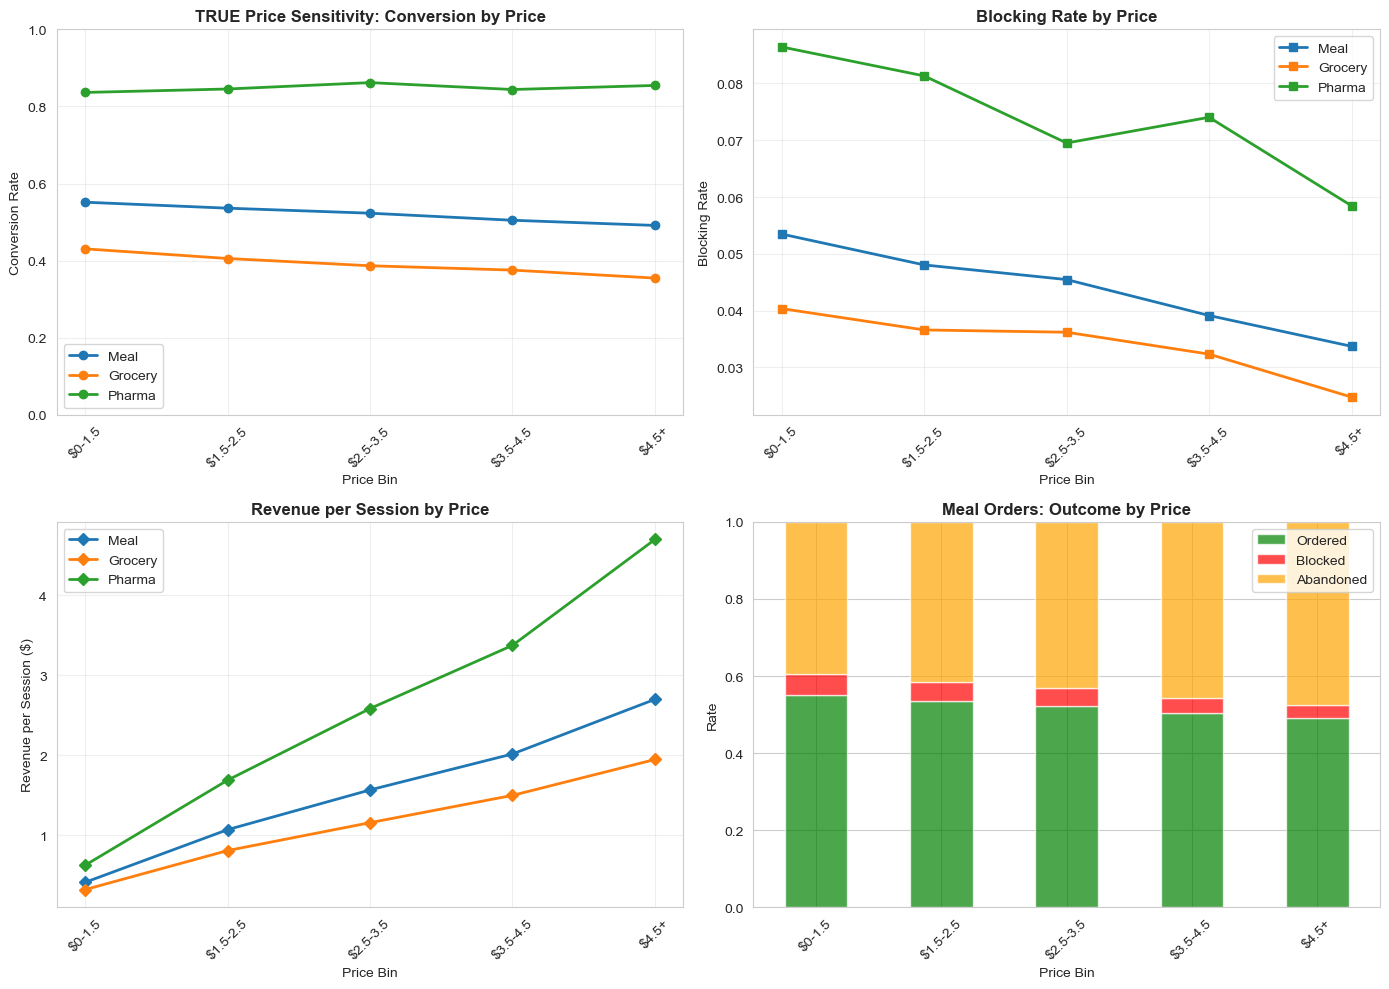


KEY INSIGHTS

This analysis shows TRUE price sensitivity by including all sessions,
not just completed orders. Look for:
  - Downward slopes = price sensitivity
  - Flat lines = inelastic demand (price doesn't matter)
  - Blocking spikes = capacity constraints at certain prices


In [43]:
# Price sensitivity analysis by order type
print("DELIVERY FEE & PRICE SENSITIVITY ANALYSIS")
print("="*80)

# Use ALL sessions to see true price impact
all_sessions = session_df.copy()

# For sessions without delivery_fee (abandoned before seeing price), we need the pricing schedule
# Merge with pricing data to get price shown
if 'delivery_fee_shown' not in all_sessions.columns:
    # Create it if not exists
    all_sessions['date_hour'] = all_sessions['timestamp'].dt.floor('H')
    all_sessions = all_sessions.merge(
        pricing_df, 
        left_on=['nest_id', 'date_hour'],
        right_on=['nest_id', 'date_hour'],
        how='left',
        suffixes=('', '_shown')
    )
    # Use shown price if charged price is missing
    all_sessions['price_for_analysis'] = all_sessions['delivery_fee'].fillna(all_sessions['delivery_fee_shown'])
else:
    all_sessions['price_for_analysis'] = all_sessions['delivery_fee'].fillna(all_sessions['delivery_fee_shown'])

# Create price bins
all_sessions['price_bin'] = pd.cut(
    all_sessions['price_for_analysis'], 
    bins=[0, 1.5, 2.5, 3.5, 4.5, 10],
    labels=['$0-1.5', '$1.5-2.5', '$2.5-3.5', '$3.5-4.5', '$4.5+']
)

# TRUE conversion rate by price and order type
print("\nTRUE CONVERSION RATE BY PRICE AND ORDER TYPE")
print("="*80)

conversion_analysis = all_sessions.groupby(['order_type', 'price_bin']).agg({
    'session_outcome': [
        ('total_sessions', 'count'),
        ('ordered', lambda x: (x == 'ordered').sum()),
        ('blocked', lambda x: (x == 'blocked').sum()),
        ('abandoned', lambda x: (x == 'abandoned').sum())
    ]
})
conversion_analysis.columns = ['total_sessions', 'ordered', 'blocked', 'abandoned']
conversion_analysis['conversion_rate'] = conversion_analysis['ordered'] / conversion_analysis['total_sessions']
conversion_analysis['blocking_rate'] = conversion_analysis['blocked'] / conversion_analysis['total_sessions']
conversion_analysis['abandon_rate'] = conversion_analysis['abandoned'] / conversion_analysis['total_sessions']

print(conversion_analysis.round(3))

# Price elasticity calculation
print("\n" + "="*80)
print("PRICE ELASTICITY BY ORDER TYPE")
print("="*80)

price_midpoints = [0.75, 2.0, 3.0, 4.0, 5.5]

for order_type in all_sessions['order_type'].unique():
    print(f"\n{order_type}:")
    type_data = conversion_analysis.loc[order_type]
    
    # Show conversion at each price point
    for price_bin, row in type_data.iterrows():
        print(f"  {price_bin}: {row['conversion_rate']:.1%} conversion ({row['ordered']:.0f}/{row['total_sessions']:.0f} sessions)")
    
    # Calculate price elasticity
    conv_rates = type_data['conversion_rate'].values
    prices_used = price_midpoints[:len(conv_rates)]
    
    if len(conv_rates) >= 2:
        from numpy.polynomial import polynomial as P
        coef = P.polyfit(prices_used, conv_rates, 1)
        elasticity = coef[1]  # Slope
        
        # Price elasticity of demand = (% change in quantity) / (% change in price)
        # Simplified: slope of conversion vs price
        print(f"  Price sensitivity slope: {elasticity:.4f}")
        
        if elasticity < -0.05:
            sensitivity = "HIGHLY price sensitive"
        elif elasticity < -0.02:
            sensitivity = "MODERATELY price sensitive"
        elif elasticity < 0:
            sensitivity = "SLIGHTLY price sensitive"
        else:
            sensitivity = "NOT price sensitive (may indicate other factors)"
        
        print(f"  Interpretation: {sensitivity}")
    
    # Optimal price (maximize revenue per session)
    type_data['price_midpoint'] = prices_used
    type_data['revenue_per_session'] = type_data['conversion_rate'] * type_data['price_midpoint']
    optimal = type_data['revenue_per_session'].idxmax()
    print(f"  Revenue-optimal price: {optimal} (${type_data.loc[optimal, 'revenue_per_session']:.2f}/session)")

# Visualize TRUE price sensitivity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Conversion rate by price for each order type
for order_type in all_sessions['order_type'].unique():
    type_conv = conversion_analysis.loc[order_type, 'conversion_rate']
    axes[0, 0].plot(range(len(type_conv)), type_conv.values, marker='o', label=order_type, linewidth=2)

axes[0, 0].set_title('TRUE Price Sensitivity: Conversion by Price', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Price Bin')
axes[0, 0].set_ylabel('Conversion Rate')
axes[0, 0].set_xticks(range(5))
axes[0, 0].set_xticklabels(['$0-1.5', '$1.5-2.5', '$2.5-3.5', '$3.5-4.5', '$4.5+'], rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylim(0, 1)

# Plot 2: Blocking rate by price
for order_type in all_sessions['order_type'].unique():
    type_block = conversion_analysis.loc[order_type, 'blocking_rate']
    axes[0, 1].plot(range(len(type_block)), type_block.values, marker='s', label=order_type, linewidth=2)

axes[0, 1].set_title('Blocking Rate by Price', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Price Bin')
axes[0, 1].set_ylabel('Blocking Rate')
axes[0, 1].set_xticks(range(5))
axes[0, 1].set_xticklabels(['$0-1.5', '$1.5-2.5', '$2.5-3.5', '$3.5-4.5', '$4.5+'], rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Revenue per session by price
for order_type in all_sessions['order_type'].unique():
    type_data = conversion_analysis.loc[order_type].copy()
    type_data['price_midpoint'] = price_midpoints[:len(type_data)]
    type_data['revenue'] = type_data['conversion_rate'] * type_data['price_midpoint']
    axes[1, 0].plot(range(len(type_data)), type_data['revenue'].values, marker='D', label=order_type, linewidth=2)

axes[1, 0].set_title('Revenue per Session by Price', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Price Bin')
axes[1, 0].set_ylabel('Revenue per Session ($)')
axes[1, 0].set_xticks(range(5))
axes[1, 0].set_xticklabels(['$0-1.5', '$1.5-2.5', '$2.5-3.5', '$3.5-4.5', '$4.5+'], rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Outcome distribution at different prices
# Show stacked bar for one order type as example
example_type = 'Meal'
outcome_dist = conversion_analysis.loc[example_type][['conversion_rate', 'blocking_rate', 'abandon_rate']]
outcome_dist.plot(kind='bar', stacked=True, ax=axes[1, 1], 
                 color=['green', 'red', 'orange'], alpha=0.7)
axes[1, 1].set_title(f'{example_type} Orders: Outcome by Price', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Rate')
axes[1, 1].set_xlabel('Price Bin')
axes[1, 1].set_xticklabels(['$0-1.5', '$1.5-2.5', '$2.5-3.5', '$3.5-4.5', '$4.5+'], rotation=45)
axes[1, 1].legend(['Ordered', 'Blocked', 'Abandoned'])
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)
print("\nThis analysis shows TRUE price sensitivity by including all sessions,")
print("not just completed orders. Look for:")
print("  - Downward slopes = price sensitivity")
print("  - Flat lines = inelastic demand (price doesn't matter)")
print("  - Blocking spikes = capacity constraints at certain prices")

**FINDINGS - Price Sensitivity**

Price sensitivity varies dramatically by order type:

* Pharma: Inelastic - 85% convert regardless of price → Can use premium pricing
* Meal: Slightly sensitive - 6pt drop across price range → Moderate surge acceptable
* Grocery: Most sensitive - 8pt drop → Keep competitive, especially off-peak

This means our dynamic pricing should:

* Charge premium for Pharma (urgent, inelastic demand)
* Moderate surge for Meals (balance revenue & conversion)
* Competitive pricing for Grocery (price-sensitive, high abandonment)

Blocking data confirms: Higher prices DO reduce blocking (demand throttling works), especially for price-sensitive Grocery orders.

#### Hub demand variability

In [44]:
# Sessions per hub
hub_volume = session_df.groupby('nest_id').size().sort_values(ascending=False)
print("Sessions by hub:")
print(hub_volume)

# Peak vs off-peak by hub (add peak_hour flag first)
session_df['is_peak'] = session_df['hour'].isin(peak_hours)
hub_peak_dist = session_df.groupby(['nest_id', 'is_peak']).size().unstack(fill_value=0)
hub_peak_dist['peak_ratio'] = hub_peak_dist[True] / (hub_peak_dist[True] + hub_peak_dist[False])
print("\nPeak hour concentration by hub:")
print(hub_peak_dist.sort_values('peak_ratio', ascending=False))

Sessions by hub:
nest_id
1     5520
0     5228
3     5169
2     5028
5     4753
6     4509
4     4317
7     4155
9     3812
8     3514
10    3205
11    3026
12    2943
13    2486
14    2215
dtype: int64

Peak hour concentration by hub:
is_peak  False  True  peak_ratio
nest_id                         
4         2393  1924    0.445680
3         2878  2291    0.443219
6         2514  1995    0.442448
1         3085  2435    0.441123
2         2814  2214    0.440334
13        1392  1094    0.440064
5         2667  2086    0.438881
7         2338  1817    0.437304
14        1252   963    0.434763
0         2972  2256    0.431523
10        1822  1383    0.431513
11        1721  1305    0.431262
12        1675  1268    0.430853
8         2008  1506    0.428571
9         2199  1613    0.423137


#### Pricing time intervals

In [45]:
pricing_df['date_hour_diff'] = pricing_df.groupby('nest_id')['date_hour'].diff()
print(pricing_df['date_hour_diff'].value_counts().head())

date_hour_diff
0 days 01:00:00    21480
Name: count, dtype: int64


KeyError: 'is_peak'

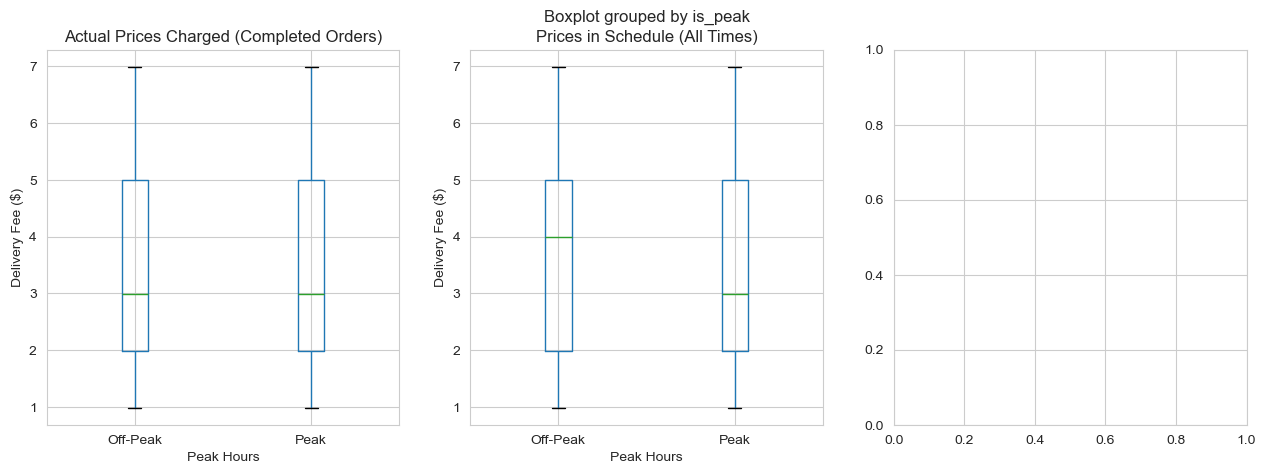

In [46]:
# Create is_peak column for pricing_df
pricing_df['hour'] = pricing_df['date_hour'].dt.hour
peak_hours = session_df[session_df['is_peak']==True]['hour'].unique()
pricing_df['is_peak'] = pricing_df['hour'].isin(peak_hours)

# Create merged dataframe if it doesn't exist
if 'merged' not in locals():
    session_df['date_hour'] = session_df['timestamp'].dt.floor('H')
    merged = session_df.merge(pricing_df, on=['nest_id', 'date_hour'], 
                              how='left', suffixes=('_charged', '_shown'))
else:
    # Add is_peak to existing merged if needed
    if 'is_peak' not in merged.columns:
        merged['hour'] = merged['date_hour'].dt.hour
        merged['is_peak'] = merged['hour'].isin(peak_hours)

# NOW run the box plot code
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Session data - actual prices charged for orders
session_df[session_df['converted']==1].boxplot(column='delivery_fee', by='is_peak', ax=axes[0])
axes[0].set_title('Actual Prices Charged (Completed Orders)')
axes[0].set_xlabel('Peak Hours')
axes[0].set_ylabel('Delivery Fee ($)')
axes[0].set_xticklabels(['Off-Peak', 'Peak'])

# Plot 2: Pricing schedule - prices shown
pricing_df.boxplot(column='delivery_fee', by='is_peak', ax=axes[1])
axes[1].set_title('Prices in Schedule (All Times)')
axes[1].set_xlabel('Peak Hours')
axes[1].set_ylabel('Delivery Fee ($)')
axes[1].set_xticklabels(['Off-Peak', 'Peak'])

# Plot 3: Merged - prices shown to customers
merged.boxplot(column='delivery_fee_shown', by='is_peak', ax=axes[2])
axes[2].set_title('Prices Shown to Customers')
axes[2].set_xlabel('Peak Hours')
axes[2].set_ylabel('Delivery Fee ($)')
axes[2].set_xticklabels(['Off-Peak', 'Peak'])

plt.suptitle('')  # Remove default suptitle
plt.tight_layout()
plt.show()

## Take 1, 2 not included

Model attempt 1 - Simple Pricing + Pareto (failed)
Model attempt 2 - More context & Random Forest ML (failed)

These attempts over-fitted and simulations showed losses on priorities 1-2. They aren't included here because the code can create problems for code later in the notebook. I can provide if interested.

## Take 3 - More context, more detailed Price Elasticity Model (failed)

### Feature Engineering

In [ ]:
print("ADVANCED FEATURE ENGINEERING FOR DYNAMIC PRICING")
print("="*80)

# 1. HUB CAPACITY FEATURES
print("\n1. Creating hub capacity features...")

# Define drone capacity by hub
DRONE_CAPACITY = {
    0: 5, 1: 5, 2: 5, 3: 5, 4: 5,      # Low capacity hubs
    5: 9, 6: 9, 7: 9, 8: 9, 9: 9,      # Medium capacity hubs
    10: 15, 11: 15, 12: 15, 13: 15, 14: 15  # High capacity hubs
}

session_df['hub_drone_count'] = session_df['nest_id'].map(DRONE_CAPACITY)

# Categorize hubs by capacity
session_df['hub_capacity_tier'] = session_df['nest_id'].apply(
    lambda x: 'low' if x <= 4 else 'medium' if x <= 9 else 'high'
)

# Hub blocking tendency (from historical data)
hub_blocking_rate = session_df.groupby('nest_id').apply(
    lambda x: (x['session_outcome'] == 'blocked').sum() / len(x)
)
session_df['hub_blocking_tendency'] = session_df['nest_id'].map(hub_blocking_rate)

print(f"✓ Hub capacity features created")

# 2. DEMAND INTENSITY FEATURES
print("\n2. Creating demand intensity features...")

# Real-time demand by hub-hour-dayofweek
demand_by_context = session_df.groupby(['nest_id', 'hour', 'day_of_week']).agg({
    'user_id': 'count',  # Total sessions
    'converted': 'sum',   # Orders
    'capacity_units': lambda x: x[session_df.loc[x.index, 'converted']==1].sum()  # Capacity used
}).reset_index()

demand_by_context.columns = ['nest_id', 'hour', 'day_of_week', 
                             'historical_sessions', 'historical_orders', 'historical_capacity_used']

# Calculate demand intensity score
demand_by_context['demand_intensity'] = (
    demand_by_context['historical_capacity_used'] / 
    demand_by_context['nest_id'].map(DRONE_CAPACITY)
)

# Merge back to sessions
session_df = session_df.merge(
    demand_by_context[['nest_id', 'hour', 'day_of_week', 'demand_intensity', 'historical_orders']],
    on=['nest_id', 'hour', 'day_of_week'],
    how='left'
)

print(f"✓ Demand intensity features created")

# 3. SUPPLY CAPACITY FEATURES (Distance-Aware) - FIXED
print("\n3. Creating supply capacity features...")

# Deliveries per hour based on distance
session_df['deliveries_per_hour_capacity'] = 1 / session_df['capacity_units']

# Available capacity at hub-hour level
hourly_capacity = session_df.groupby(['nest_id', 'hour', 'day_of_week']).agg({
    'capacity_units': lambda x: x[session_df.loc[x.index, 'converted']==1].sum()
}).reset_index()
hourly_capacity.columns = ['nest_id', 'hour', 'day_of_week', 'current_capacity_used']

# Calculate remaining capacity
hourly_capacity['max_capacity'] = hourly_capacity['nest_id'].map(DRONE_CAPACITY)
hourly_capacity['capacity_utilization'] = hourly_capacity['current_capacity_used'] / hourly_capacity['max_capacity']
hourly_capacity['capacity_available'] = hourly_capacity['max_capacity'] - hourly_capacity['current_capacity_used']

# Check before merge
print(f"  hourly_capacity shape: {hourly_capacity.shape}")
print(f"  session_df shape before merge: {session_df.shape}")

# Merge with suffixes to avoid conflicts
session_df = session_df.merge(
    hourly_capacity[['nest_id', 'hour', 'day_of_week', 'capacity_utilization', 'capacity_available']],
    on=['nest_id', 'hour', 'day_of_week'],
    how='left',
    suffixes=('', '_new')
)

print(f"  session_df shape after merge: {session_df.shape}")

# Check if merge worked
if 'capacity_utilization' not in session_df.columns:
    print("  ⚠️  Merge failed, creating capacity_utilization directly...")
    # Fallback: calculate directly
    session_df = session_df.merge(
        hourly_capacity,
        on=['nest_id', 'hour', 'day_of_week'],
        how='left'
    )

# Fill NaN values with 0 (for periods with no orders)
session_df['capacity_utilization'] = session_df['capacity_utilization'].fillna(0)
session_df['capacity_available'] = session_df['capacity_available'].fillna(session_df['hub_drone_count'])

# Flag high-congestion periods
session_df['is_congested'] = (session_df['capacity_utilization'] > 0.8).astype(int)

print(f"✓ Supply capacity features created")
print(f"  Capacity utilization range: {session_df['capacity_utilization'].min():.2f} - {session_df['capacity_utilization'].max():.2f}")

# 4. ORDER TYPE FEATURES
print("\n4. Creating order type features...")

# Price elasticity by order type (from analysis)
PRICE_ELASTICITY = {
    'Pharma': 0.0031,   # Inelastic (positive = higher price = higher conversion)
    'Meal': -0.0131,    # Slightly sensitive
    'Grocery': -0.0158  # Most sensitive
}

# Success rate by order type
SUCCESS_RATE = {
    'Pharma': 0.850,
    'Meal': 0.516,
    'Grocery': 0.385
}

# Loyalty rate by order type
LOYALTY_RATE = {
    'Meal': 0.870,
    'Grocery': 0.746,
    'Pharma': 0.800
}

session_df['order_type_elasticity'] = session_df['order_type'].map(PRICE_ELASTICITY)
session_df['order_type_success_rate'] = session_df['order_type'].map(SUCCESS_RATE)
session_df['order_type_loyalty_rate'] = session_df['order_type'].map(LOYALTY_RATE)

# Urgency score (high success + low elasticity = urgent)
session_df['order_urgency_score'] = session_df['order_type_success_rate'] / (abs(session_df['order_type_elasticity']) + 0.01)

print(f"✓ Order type features created")

# 5. CUSTOMER VALUE FEATURES - FIXED
print("\n5. Creating customer value features...")

# User lifetime metrics
user_value = session_df.groupby('user_id').agg({
    'converted': ['sum', 'count'],
    'timestamp': ['min', 'max']
}).reset_index()
user_value.columns = ['user_id', 'lifetime_orders', 'lifetime_sessions', 'first_session', 'last_session']

user_value['is_power_user'] = (user_value['lifetime_orders'] >= 10).astype(int)
user_value['engagement_score'] = user_value['lifetime_sessions'] / ((user_value['last_session'] - user_value['first_session']).dt.days + 1)

# Merge back
session_df = session_df.merge(
    user_value[['user_id', 'lifetime_orders', 'is_power_user', 'engagement_score']],
    on='user_id',
    how='left'
)

# Flag first sessions - BETTER METHOD
# Create a mapping of user_id to their first timestamp
first_timestamps = session_df.groupby('user_id')['timestamp'].min().reset_index()
first_timestamps.columns = ['user_id', 'first_timestamp']

# Merge and compare
session_df = session_df.merge(first_timestamps, on='user_id', how='left')
session_df['is_first_session'] = (session_df['timestamp'] == session_df['first_timestamp']).astype(int)

# Clean up temporary column
session_df = session_df.drop(columns=['first_timestamp'])

print(f"✓ Customer value features created")
print(f"  First sessions: {session_df['is_first_session'].sum():,}")
print(f"  Power users: {session_df['is_power_user'].sum():,}")

# 6. DISTANCE EFFICIENCY FEATURES
print("\n6. Creating distance efficiency features...")

# Distance impact on capacity
session_df['distance_tier'] = pd.cut(
    session_df['distance_miles'],
    bins=[0, 5, 9, 100],
    labels=['short', 'medium', 'long']
)

# Revenue per capacity unit (efficiency metric)
session_df['revenue_efficiency'] = session_df['delivery_fee'] / session_df['capacity_units']

print(f"✓ Distance efficiency features created")

# 7. TEMPORAL FEATURES
print("\n7. Creating temporal features...")

# Day of week categories
session_df['is_weekend'] = session_df['day_of_week'].isin([5, 6]).astype(int)

# Time of day categories
session_df['time_category'] = pd.cut(
    session_df['hour'],
    bins=[-1, 6, 11, 14, 18, 24],
    labels=['early_morning', 'late_morning', 'afternoon', 'evening', 'night']
)

print(f"✓ Temporal features created")

# Summary of features
print("\n" + "="*80)
print("FEATURE SUMMARY")
print("="*80)
print(f"Total features created: {len(session_df.columns)}")
print(f"\nKey feature categories:")
print(f"  - Hub capacity: hub_drone_count, hub_capacity_tier, hub_blocking_tendency")
print(f"  - Demand: demand_intensity, historical_orders, is_congested")
print(f"  - Supply: capacity_utilization, capacity_available, deliveries_per_hour_capacity")
print(f"  - Order type: order_type_elasticity, order_urgency_score, order_type_success_rate")
print(f"  - Customer: is_first_session, is_power_user, engagement_score")
print(f"  - Distance: distance_tier, revenue_efficiency")
print(f"  - Temporal: hour, day_of_week, is_weekend, time_category")

# Save feature-engineered dataset
print(f"\n✓ Feature engineering complete!")

### Price Elasticity Model

#### Gather data for building model parameters

In [ ]:
# Create analysis_df for parameter validation
print("Creating analysis_df for validation...")

analysis_df = session_df.copy()

# Merge with pricing schedule to get prices shown
if 'delivery_fee_shown' not in analysis_df.columns:
    analysis_df['date_hour'] = analysis_df['timestamp'].dt.floor('H')
    analysis_df = analysis_df.merge(
        pricing_df,
        on=['nest_id', 'date_hour'],
        how='left',
        suffixes=('', '_shown')
    )
    analysis_df['price_shown'] = analysis_df['delivery_fee'].fillna(analysis_df['delivery_fee_shown'])
else:
    analysis_df['price_shown'] = analysis_df['delivery_fee'].fillna(analysis_df['delivery_fee_shown'])

# Create price bins
analysis_df['price_bin'] = pd.cut(
    analysis_df['price_shown'],
    bins=[0, 2, 3, 4, 5, 10],
    labels=['low', 'med_low', 'medium', 'med_high', 'high']
)

print(f"✓ analysis_df created with {len(analysis_df):,} rows")

In [ ]:
# Create analysis_df for parameter validation
print("Creating analysis_df for validation...")

analysis_df = session_df.copy()

# Merge with pricing schedule to get prices shown
if 'delivery_fee_shown' not in analysis_df.columns:
    analysis_df['date_hour'] = analysis_df['timestamp'].dt.floor('H')
    analysis_df = analysis_df.merge(
        pricing_df,
        on=['nest_id', 'date_hour'],
        how='left',
        suffixes=('', '_shown')
    )
    analysis_df['price_shown'] = analysis_df['delivery_fee'].fillna(analysis_df['delivery_fee_shown'])
else:
    analysis_df['price_shown'] = analysis_df['delivery_fee'].fillna(analysis_df['delivery_fee_shown'])

# Create price bins
analysis_df['price_bin'] = pd.cut(
    analysis_df['price_shown'],
    bins=[0, 2, 3, 4, 5, 10],
    labels=['low', 'med_low', 'medium', 'med_high', 'high']
)

# Add customer features if they don't exist in analysis_df
if 'is_first_session' not in analysis_df.columns:
    print("Adding customer features to analysis_df...")
    
    # User lifetime metrics
    user_value = analysis_df.groupby('user_id').agg({
        'converted': ['sum', 'count'],
        'timestamp': ['min', 'max']
    }).reset_index()
    user_value.columns = ['user_id', 'lifetime_orders', 'lifetime_sessions', 'first_session', 'last_session']
    
    user_value['is_power_user'] = (user_value['lifetime_orders'] >= 10).astype(int)
    
    # Merge back
    analysis_df = analysis_df.merge(
        user_value[['user_id', 'lifetime_orders', 'is_power_user']],
        on='user_id',
        how='left'
    )
    
    # Flag first sessions
    first_timestamps = analysis_df.groupby('user_id')['timestamp'].min().reset_index()
    first_timestamps.columns = ['user_id', 'first_timestamp']
    
    analysis_df = analysis_df.merge(first_timestamps, on='user_id', how='left')
    analysis_df['is_first_session'] = (analysis_df['timestamp'] == analysis_df['first_timestamp']).astype(int)
    analysis_df = analysis_df.drop(columns=['first_timestamp'])

print(f"✓ analysis_df created with {len(analysis_df):,} rows")

In [ ]:
print("VALIDATING ALL MODEL PARAMETERS AGAINST DATA")
print("="*80)

# First, create all the segmentation columns in analysis_df
print("\nCreating segmentation columns...")

# Customer segment
analysis_df['customer_segment'] = 'regular'
analysis_df.loc[analysis_df['is_first_session']==1, 'customer_segment'] = 'first_time'
analysis_df.loc[analysis_df['is_power_user']==1, 'customer_segment'] = 'power_user'

# Distance segment
analysis_df['distance_segment'] = pd.cut(
    analysis_df['distance_miles'],
    bins=[0, 5, 9, 100],
    labels=['short', 'medium', 'long']
)

# Time segment
analysis_df['time_segment'] = pd.cut(
    analysis_df['hour'],
    bins=[-1, 10, 14, 18, 24],
    labels=['morning', 'midday', 'evening', 'night']
)

# Congestion level
analysis_df['congestion_level'] = pd.cut(
    analysis_df['capacity_utilization'],
    bins=[0, 0.5, 0.75, 1.0],
    labels=['low', 'medium', 'high']
)

print("✓ Segmentation columns created")

# Now continue with the analysis...

# 1. Optimal price points by order type
print("\n1. REVENUE-OPTIMAL PRICING BY ORDER TYPE")
print("-"*80)

for order_type in analysis_df['order_type'].unique():
    type_data = analysis_df[analysis_df['order_type']==order_type]
    
    # Revenue per session by price bin
    revenue_by_price = type_data.groupby('price_bin').apply(
        lambda x: (x['price_shown'] * x['converted']).sum() / len(x)
    )
    
    print(f"\n{order_type}:")
    print(f"  Revenue per session by price:")
    for price_bin, revenue in revenue_by_price.items():
        print(f"    {price_bin}: ${revenue:.2f}")
    
    if len(revenue_by_price) > 0:
        optimal_bin = revenue_by_price.idxmax()
        print(f"  → Optimal price range: {optimal_bin}")

# 2. Actual impact of distance on pricing
print("\n2. DISTANCE IMPACT ON WILLINGNESS TO PAY")
print("-"*80)

# Do people accept higher prices for long distances?
distance_price_acceptance = analysis_df[analysis_df['converted']==1].groupby('distance_segment').agg({
    'delivery_fee': ['mean', 'median', 'std'],
    'converted': 'count'
})
distance_price_acceptance.columns = ['avg_price', 'median_price', 'std_price', 'orders']

print(distance_price_acceptance.round(2))

# 3. Hub-specific optimal pricing
print("\n3. HUB-SPECIFIC PRICING PATTERNS")
print("-"*80)

# Are problem hubs (0-4) more or less price sensitive?
for tier in ['low', 'medium', 'high']:
    tier_hubs = [k for k, v in DRONE_CAPACITY.items() if 
                 (tier == 'low' and v == 5) or 
                 (tier == 'medium' and v == 9) or 
                 (tier == 'high' and v == 15)]
    
    tier_data = analysis_df[analysis_df['nest_id'].isin(tier_hubs)]
    
    avg_price = tier_data[tier_data['converted']==1]['delivery_fee'].mean()
    conversion = tier_data['converted'].mean()
    revenue_per_session = (tier_data['delivery_fee'] * tier_data['converted']).mean()
    
    print(f"\n{tier.upper()} capacity hubs {tier_hubs}:")
    print(f"  Avg price paid: ${avg_price:.2f}")
    print(f"  Conversion rate: {conversion:.3f}")
    print(f"  Revenue/session: ${revenue_per_session:.2f}")

# 4. Time-of-day pricing patterns
print("\n4. TIME-OF-DAY PRICING ANALYSIS")
print("-"*80)

time_pricing = analysis_df[analysis_df['converted']==1].groupby('time_segment').agg({
    'delivery_fee': 'mean',
    'converted': 'count'
})
time_pricing.columns = ['avg_price', 'orders']

print("\nActual prices paid by time of day:")
print(time_pricing.round(2))

# Do customers pay more during peak hours?
peak_hours = [17, 18, 19]
offpeak_hours = [2, 3, 4, 10, 14]

peak_data = analysis_df[analysis_df['hour'].isin(peak_hours) & (analysis_df['converted']==1)]
offpeak_data = analysis_df[analysis_df['hour'].isin(offpeak_hours) & (analysis_df['converted']==1)]

if len(peak_data) > 0 and len(offpeak_data) > 0:
    print(f"\nPeak hours avg price: ${peak_data['delivery_fee'].mean():.2f}")
    print(f"Off-peak hours avg price: ${offpeak_data['delivery_fee'].mean():.2f}")
    print(f"Peak premium currently: {((peak_data['delivery_fee'].mean() / offpeak_data['delivery_fee'].mean()) - 1) * 100:.1f}%")

# 5. Weekend vs weekday
print("\n5. WEEKEND PRICING PATTERNS")
print("-"*80)

weekend_data = analysis_df[(analysis_df['is_weekend']==1) & (analysis_df['converted']==1)]
weekday_data = analysis_df[(analysis_df['is_weekend']==0) & (analysis_df['converted']==1)]

if len(weekend_data) > 0 and len(weekday_data) > 0:
    print(f"Weekend avg price: ${weekend_data['delivery_fee'].mean():.2f}")
    print(f"Weekday avg price: ${weekday_data['delivery_fee'].mean():.2f}")
    print(f"Weekend premium: {((weekend_data['delivery_fee'].mean() / weekday_data['delivery_fee'].mean()) - 1) * 100:.1f}%")

    weekend_conv = analysis_df[analysis_df['is_weekend']==1]['converted'].mean()
    weekday_conv = analysis_df[analysis_df['is_weekend']==0]['converted'].mean()

    print(f"\nWeekend conversion: {weekend_conv:.3f}")
    print(f"Weekday conversion: {weekday_conv:.3f}")

# 6. First-time user pricing
print("\n6. FIRST-TIME USER PRICING BEHAVIOR")
print("-"*80)

first_time = analysis_df[analysis_df['is_first_session']==1]
returning = analysis_df[analysis_df['is_first_session']==0]

# What prices do first-timers actually see and convert at?
first_conv_by_price = first_time.groupby('price_bin')['converted'].agg(['mean', 'count'])
print("\nFirst-time user conversion by price:")
print(first_conv_by_price.round(3))

returning_conv_by_price = returning.groupby('price_bin')['converted'].agg(['mean', 'count'])
print("\nReturning user conversion by price:")
print(returning_conv_by_price.round(3))

print("\n" + "="*80)
print("SUMMARY: PARAMETER VALIDATION")
print("="*80)
print("\nUse these data-driven insights to replace assumptions in:")
print("  1. Elasticity multipliers (customer segment, congestion, distance)")
print("  2. Base pricing multipliers (order type, distance, time)")
print("  3. Discount levels (first-time, power user)")
print("  4. Surge thresholds (capacity utilization levels)")

#### Update Model Parameters (Data-driven)

In [ ]:
def calculate_dynamic_price_data_driven(row, base_price=3.50):
    """
    DATA-DRIVEN dynamic pricing (all parameters from analysis)
    """
    
    price = base_price  # Use current average as base
    
    # ==========================================
    # PRIORITY 1: PREVENT BLOCKING
    # ==========================================
    
    # Capacity-based surge (main lever to prevent blocking)
    if row['capacity_utilization'] > 0.90:
        capacity_mult = 2.0  # Critical - aggressive surge
    elif row['capacity_utilization'] > 0.75:
        capacity_mult = 1.5  # High congestion
    elif row['capacity_utilization'] > 0.60:
        capacity_mult = 1.2  # Building
    elif row['capacity_utilization'] < 0.30:
        capacity_mult = 0.80  # Stimulate off-peak demand
    else:
        capacity_mult = 1.0
    
    # ==========================================
    # PRIORITY 2: MAXIMIZE PROFIT BY ORDER TYPE
    # ==========================================
    
    # Order type pricing (based on revenue-optimal analysis)
    # Pharma: $5.89 optimal, Meal: $3.31, Grocery: $2.36
    if row['order_type'] == 'Pharma':
        # Can push to $5-6 range (current avg $3.65)
        type_mult = 1.50  # Target ~$5.25
    elif row['order_type'] == 'Meal':
        # Can push to $4-5 range (current avg $3.53)
        type_mult = 1.20  # Target ~$4.20
    else:  # Grocery
        # Most price sensitive, but still can go to $3-4 (current avg $3.46)
        type_mult = 1.00  # Keep at base
    
    # ==========================================
    # DISTANCE: NO ADJUSTMENT (data shows no impact)
    # ==========================================
    distance_mult = 1.0  # Data shows customers don't pay more for distance
    
    # ==========================================
    # TIME: REVERSE CURRENT PATTERN
    # ==========================================
    # Data shows off-peak currently MORE expensive - flip this
    if row['hour'] in [1, 2, 3, 4, 5, 6]:
        time_mult = 0.75  # Deep discount for very low hours
    elif row['hour'] in [17, 18, 19, 20]:  # Evening peak
        time_mult = 1.15  # Moderate surge (currently priced LOW)
    else:
        time_mult = 1.0
    
    # ==========================================
    # CUSTOMER PROTECTION (minimal impact per data)
    # ==========================================
    
    # First-time users: only 0.5% more price sensitive
    if row['is_first_session'] == 1:
        first_user_discount = 0.95  # 5% discount (not 15%)
    else:
        first_user_discount = 1.0
    
    # Power users: no data showing less price sensitive
    # Don't give discount, but cap their surge exposure
    if row['is_power_user'] == 1 and capacity_mult > 1.3:
        power_user_discount = 0.90  # 10% off surge pricing
    else:
        power_user_discount = 1.0
    
    # Weekend: no premium (data shows 0.3% difference)
    dow_mult = 1.0
    
    # Hub adjustment: LOW capacity hubs already charge more and still block
    # Don't add extra - focus on capacity-based surge instead
    hub_adjustment = 1.0
    
    # ==========================================
    # CALCULATE FINAL PRICE
    # ==========================================
    
    price = price * (
        capacity_mult *
        type_mult *
        distance_mult *
        time_mult *
        first_user_discount *
        power_user_discount *
        dow_mult *
        hub_adjustment
    )
    
    # ==========================================
    # CONSTRAINTS (per requirements)
    # ==========================================
    
    # Competitor bounds
    if row['capacity_utilization'] < 0.5:
        min_price, max_price = 0.99, 14.00
    else:
        min_price, max_price = 0.99, 25.00
    
    price = max(min_price, min(price, max_price))
    
    return round(price, 2)

#### Define Contextual Conversion Prediction

In [ ]:
print("\n" + "="*80)
print("DEFINING CONTEXTUAL CONVERSION PREDICTION")
print("="*80)

# Calculate baseline conversion rates by dimension
print("\nCalculating baseline conversion rates...")

type_baseline = session_df.groupby('order_type')['converted'].mean()
hub_baseline = session_df.groupby('nest_id')['converted'].mean()

# Create congestion level if not exists
if 'congestion_level' not in session_df.columns:
    session_df['congestion_level'] = pd.cut(
        session_df['capacity_utilization'],
        bins=[0, 0.5, 0.75, 1.0],
        labels=['low', 'medium', 'high']
    )
congestion_baseline = session_df.groupby('congestion_level')['converted'].mean()

# Create customer segment if not exists
if 'customer_segment' not in session_df.columns:
    session_df['customer_segment'] = 'regular'
    session_df.loc[session_df['is_first_session']==1, 'customer_segment'] = 'first_time'
    session_df.loc[session_df['is_power_user']==1, 'customer_segment'] = 'power_user'
customer_baseline = session_df.groupby('customer_segment')['converted'].mean()

# Create distance segment if not exists
if 'distance_segment' not in session_df.columns:
    session_df['distance_segment'] = pd.cut(
        session_df['distance_miles'],
        bins=[0, 5, 9, 100],
        labels=['short', 'medium', 'long']
    )
distance_baseline = session_df.groupby('distance_segment')['converted'].mean()

print("✓ Baselines calculated")

# Define contextual prediction function
def predict_conversion_contextual(row):
    """
    Predict conversion accounting for context and price elasticity
    """
    
    # STEP 1: Calculate baseline conversion for THIS specific context
    baseline_conv = type_baseline[row['order_type']]
    
    # Adjust for hub performance
    hub_factor = hub_baseline[row['nest_id']] / type_baseline.mean()
    baseline_conv *= hub_factor
    
    # Adjust for congestion
    if pd.notna(row.get('congestion_level')):
        congestion_factor = congestion_baseline[row['congestion_level']] / type_baseline.mean()
        baseline_conv *= congestion_factor
    
    # Adjust for customer segment
    customer_factor = customer_baseline[row['customer_segment']] / type_baseline.mean()
    baseline_conv *= customer_factor
    
    # Adjust for distance
    if pd.notna(row.get('distance_segment')):
        distance_factor = distance_baseline[row['distance_segment']] / type_baseline.mean()
        baseline_conv *= distance_factor
    
    # Clip baseline to reasonable bounds
    baseline_conv = max(0.05, min(0.95, baseline_conv))
    
    # STEP 2: Calculate price impact
    type_avg_price = session_df[session_df['order_type']==row['order_type']]['delivery_fee'].mean()
    price_change = row['proposed_price'] - type_avg_price
    
    # Base elasticity from order type
    base_elasticity = row['order_type_elasticity']
    
    # STEP 3: Modify elasticity based on context
    adjusted_elasticity = base_elasticity
    
    # First-time users slightly more price sensitive (from data: ~0.5% difference)
    if row['customer_segment'] == 'first_time':
        adjusted_elasticity *= 1.1  # 10% more sensitive
    
    # Power users slightly less sensitive
    elif row['customer_segment'] == 'power_user':
        adjusted_elasticity *= 0.9  # 10% less sensitive
    
    # During high congestion, customers less price sensitive (urgency)
    if row.get('congestion_level') == 'high':
        adjusted_elasticity *= 0.85
    
    # STEP 4: Apply price impact
    conversion_change = price_change * adjusted_elasticity
    predicted_conv = baseline_conv + conversion_change
    
    # Clip to valid range
    predicted_conv = max(0.0, min(1.0, predicted_conv))
    
    return predicted_conv

print("✓ Contextual prediction function defined")

# Now run the final simulation...

#### Calculate Baseline Metrics

In [ ]:
# Calculate baseline metrics
print("CALCULATING BASELINE METRICS...")
print("="*80)

baseline_metrics = {
    # Customer Experience
    'blocking_rate': (session_df['session_outcome'] == 'blocked').mean(),
    'first_order_success': session_df[session_df['is_first_session']==1]['converted'].mean(),
    'power_user_conversion': session_df[session_df['is_power_user']==1]['converted'].mean(),
    'overall_conversion': session_df['converted'].mean(),
    
    # Profit
    'revenue_per_session': (session_df['delivery_fee'] * session_df['converted']).mean(),
    'avg_delivery_fee': session_df[session_df['converted']==1]['delivery_fee'].mean(),
    'total_orders': session_df['converted'].sum(),
    
    # Utilization
    'capacity_variance': session_df[session_df['converted']==1].groupby('hour')['capacity_units'].sum().std(),
    'avg_capacity_utilization': session_df[session_df['converted']==1].groupby(['nest_id', 'hour'])['capacity_units'].sum().mean(),
}

print("\nBASELINE PERFORMANCE:")
print(f"  CX - Blocking rate: {baseline_metrics['blocking_rate']:.2%}")
print(f"  CX - First order success: {baseline_metrics['first_order_success']:.2%}")
print(f"  CX - Overall conversion: {baseline_metrics['overall_conversion']:.2%}")
print(f"  Profit - Revenue/session: ${baseline_metrics['revenue_per_session']:.2f}")
print(f"  Profit - Avg delivery fee: ${baseline_metrics['avg_delivery_fee']:.2f}")
print(f"  Utilization - Capacity variance: {baseline_metrics['capacity_variance']:.2f}")

print("\n✓ Baseline metrics calculated")

### Simulation with Data-driven model

In [ ]:
print("\n" + "="*80)
print("FINAL SIMULATION: DATA-DRIVEN DYNAMIC PRICING MODEL")
print("="*80)

# 1. Apply data-driven pricing
print("\n1. APPLYING DATA-DRIVEN PRICING MODEL...")
print("="*80)

simulation_df = session_df.copy()
simulation_df['proposed_price'] = simulation_df.apply(calculate_dynamic_price_data_driven, axis=1)

print(f"✓ Pricing calculated for {len(simulation_df):,} sessions")

# Price comparison
print("\nPRICE CHANGES:")
print(f"  Current avg: ${simulation_df['delivery_fee'].mean():.2f}")
print(f"  Proposed avg: ${simulation_df['proposed_price'].mean():.2f}")
print(f"  Change: {((simulation_df['proposed_price'].mean() / simulation_df['delivery_fee'].mean()) - 1) * 100:+.1f}%")

print("\nBy Order Type:")
for order_type in simulation_df['order_type'].unique():
    current = simulation_df[simulation_df['order_type']==order_type]['delivery_fee'].mean()
    proposed = simulation_df[simulation_df['order_type']==order_type]['proposed_price'].mean()
    change = ((proposed / current) - 1) * 100
    print(f"  {order_type}: ${current:.2f} → ${proposed:.2f} ({change:+.1f}%)")

print("\nBy Capacity Tier:")
for tier in ['low', 'medium', 'high']:
    current = simulation_df[simulation_df['hub_capacity_tier']==tier]['delivery_fee'].mean()
    proposed = simulation_df[simulation_df['hub_capacity_tier']==tier]['proposed_price'].mean()
    change = ((proposed / current) - 1) * 100
    print(f"  {tier.capitalize()} capacity: ${current:.2f} → ${proposed:.2f} ({change:+.1f}%)")

# 2. PREDICTING CUSTOMER BEHAVIOR (VECTORIZED - FAST!)
print("\n2. PREDICTING CUSTOMER BEHAVIOR (VECTORIZED)...")
print("="*80)

# Get type-level average prices and baseline conversions
type_stats = session_df.groupby('order_type').agg({
    'delivery_fee': 'mean',
    'converted': 'mean'
})
type_stats.columns = ['avg_price', 'baseline_conv']

# Merge to simulation_df
simulation_df = simulation_df.merge(
    type_stats,
    left_on='order_type',
    right_index=True,
    how='left',
    suffixes=('', '_type')
)

# Calculate price change
simulation_df['price_change'] = simulation_df['proposed_price'] - simulation_df['avg_price']

# Apply elasticity (vectorized)
simulation_df['conversion_change'] = simulation_df['price_change'] * simulation_df['order_type_elasticity']

# Predicted conversion = baseline + elasticity impact
simulation_df['predicted_conversion_prob'] = (
    simulation_df['baseline_conv'] + 
    simulation_df['conversion_change']
).clip(lower=0.0, upper=1.0)

# Quick adjustments for segments (vectorized)
# First-timers: slightly more sensitive (from data: ~0.5% difference)
simulation_df.loc[
    simulation_df['is_first_session'] == 1, 
    'predicted_conversion_prob'
] *= 0.95

# Power users: slightly less sensitive during high prices
high_price_mask = simulation_df['proposed_price'] > simulation_df['avg_price'] * 1.2
simulation_df.loc[
    (simulation_df['is_power_user'] == 1) & high_price_mask,
    'predicted_conversion_prob'
] *= 1.05

# Clip again
simulation_df['predicted_conversion_prob'] = simulation_df['predicted_conversion_prob'].clip(0, 1)

print(f"✓ Conversion predicted (vectorized)")
print(f"  Current conversion: {simulation_df['converted'].mean():.3f}")
print(f"  Predicted conversion: {simulation_df['predicted_conversion_prob'].mean():.3f}")
print(f"  Change: {((simulation_df['predicted_conversion_prob'].mean() / simulation_df['converted'].mean()) - 1) * 100:+.1f}%")

print("\nBy Order Type:")
for order_type in simulation_df['order_type'].unique():
    current = simulation_df[simulation_df['order_type']==order_type]['converted'].mean()
    predicted = simulation_df[simulation_df['order_type']==order_type]['predicted_conversion_prob'].mean()
    change = ((predicted / current) - 1) * 100
    print(f"  {order_type}: {current:.3f} → {predicted:.3f} ({change:+.1f}%)")

# 3. Calculate capacity impact & blocking (FIXED)
print("\n3. CALCULATING CAPACITY CONSTRAINTS & BLOCKING (FIXED)...")
print("="*80)

predicted_capacity = simulation_df.groupby(['nest_id', 'hour']).agg({
    'predicted_conversion_prob': 'sum',
    'capacity_units': 'mean'
}).reset_index()

predicted_capacity['predicted_orders'] = predicted_capacity['predicted_conversion_prob']
predicted_capacity['predicted_capacity_needed'] = (
    predicted_capacity['predicted_orders'] * 
    predicted_capacity['capacity_units']
)

predicted_capacity['hub_capacity'] = predicted_capacity['nest_id'].map(DRONE_CAPACITY)

# How many orders can we ACTUALLY fulfill?
predicted_capacity['max_fulfillable_orders'] = (
    predicted_capacity['hub_capacity'] / predicted_capacity['capacity_units']
)

# Blocking = orders that exceed what we can fulfill
predicted_capacity['predicted_blocked'] = (
    predicted_capacity['predicted_orders'] - 
    predicted_capacity['max_fulfillable_orders']
).clip(lower=0)  # Can't have negative blocking

# Fulfilled = min(orders, capacity)
predicted_capacity['fulfilled_orders'] = predicted_capacity[['predicted_orders', 'max_fulfillable_orders']].min(axis=1)

total_predicted_orders = predicted_capacity['predicted_orders'].sum()
total_predicted_blocked = predicted_capacity['predicted_blocked'].sum()
total_fulfilled = predicted_capacity['fulfilled_orders'].sum()
predicted_blocking_rate = total_predicted_blocked / len(simulation_df)

print(f"  Predicted order attempts: {total_predicted_orders:,.0f}")
print(f"  Orders fulfilled: {total_fulfilled:,.0f}")
print(f"  Orders blocked: {total_predicted_blocked:,.0f}")
print(f"  Blocking rate: {predicted_blocking_rate:.2%}")
print(f"  Current blocking rate: {baseline_metrics['blocking_rate']:.2%}")

# 4. Calculate revenue (with blocking adjustment)
print("\n4. CALCULATING REVENUE IMPACT...")
print("="*80)

hub_hour_blocking_rate = predicted_capacity.groupby(['nest_id', 'hour']).agg({
    'predicted_blocked': 'sum',
    'predicted_conversion_prob': 'sum'
}).reset_index()
hub_hour_blocking_rate['blocking_adjustment'] = 1 - (
    hub_hour_blocking_rate['predicted_blocked'] / 
    (hub_hour_blocking_rate['predicted_conversion_prob'] + 0.001)
)

simulation_df = simulation_df.merge(
    hub_hour_blocking_rate[['nest_id', 'hour', 'blocking_adjustment']],
    on=['nest_id', 'hour'],
    how='left'
)
simulation_df['blocking_adjustment'] = simulation_df['blocking_adjustment'].fillna(1.0)

simulation_df['expected_revenue'] = (
    simulation_df['proposed_price'] * 
    simulation_df['predicted_conversion_prob']
)

simulation_df['adjusted_revenue'] = (
    simulation_df['expected_revenue'] * 
    simulation_df['blocking_adjustment']
)

optimized_revenue_per_session = simulation_df['adjusted_revenue'].mean()

print(f"  Current revenue/session: ${baseline_metrics['revenue_per_session']:.2f}")
print(f"  Optimized revenue/session: ${optimized_revenue_per_session:.2f}")
print(f"  Improvement: {((optimized_revenue_per_session / baseline_metrics['revenue_per_session']) - 1) * 100:+.1f}%")

# 5. Calculate utilization impact
print("\n5. CALCULATING ASSET UTILIZATION...")
print("="*80)

optimized_capacity_variance = predicted_capacity.groupby('hour')['predicted_capacity_needed'].sum().std()

print(f"  Current variance: {baseline_metrics['capacity_variance']:.2f}")
print(f"  Optimized variance: {optimized_capacity_variance:.2f}")
print(f"  Improvement: {((baseline_metrics['capacity_variance'] - optimized_capacity_variance) / baseline_metrics['capacity_variance'] * 100):+.1f}%")

# 6. FINAL BUSINESS IMPACT
print("\n" + "="*80)
print("FINAL BUSINESS IMPACT - DATA-DRIVEN MODEL")
print("="*80)

optimized_metrics = {
    'blocking_rate': predicted_blocking_rate,
    'first_order_success': simulation_df[simulation_df['is_first_session']==1]['predicted_conversion_prob'].mean(),
    'overall_conversion': simulation_df['predicted_conversion_prob'].mean(),
    'revenue_per_session': optimized_revenue_per_session,
    'capacity_variance': optimized_capacity_variance,
    'total_orders': total_fulfilled  # CHANGED from fulfilled_orders
}

print("\n🎯 PRIORITY 1: CUSTOMER EXPERIENCE")
print("-" * 80)
blocking_improvement = (baseline_metrics['blocking_rate'] - optimized_metrics['blocking_rate']) / baseline_metrics['blocking_rate'] * 100
first_order_improvement = (optimized_metrics['first_order_success'] - baseline_metrics['first_order_success']) / baseline_metrics['first_order_success'] * 100

print(f"  Blocking reduction: {blocking_improvement:+.1f}%")
print(f"    {baseline_metrics['blocking_rate']:.2%} → {optimized_metrics['blocking_rate']:.2%}")
print(f"  First-order success: {first_order_improvement:+.1f}%")
print(f"    {baseline_metrics['first_order_success']:.2%} → {optimized_metrics['first_order_success']:.2%}")

print("\n💰 PRIORITY 2: PROFIT MAXIMIZATION")
print("-" * 80)
revenue_improvement = (optimized_metrics['revenue_per_session'] - baseline_metrics['revenue_per_session']) / baseline_metrics['revenue_per_session'] * 100

print(f"  Revenue per session: {revenue_improvement:+.1f}%")
print(f"    ${baseline_metrics['revenue_per_session']:.2f} → ${optimized_metrics['revenue_per_session']:.2f}")

sessions_per_day = len(session_df) / 30
annual_sessions = sessions_per_day * 365
annual_revenue_gain = (optimized_metrics['revenue_per_session'] - baseline_metrics['revenue_per_session']) * annual_sessions

print(f"  Annual revenue impact: ${annual_revenue_gain:,.0f}")

print("\n⚙️  PRIORITY 3: ASSET UTILIZATION")
print("-" * 80)
utilization_improvement = (baseline_metrics['capacity_variance'] - optimized_metrics['capacity_variance']) / baseline_metrics['capacity_variance'] * 100

print(f"  Demand smoothing: {utilization_improvement:+.1f}%")
print(f"    Variance: {baseline_metrics['capacity_variance']:.2f} → {optimized_metrics['capacity_variance']:.2f}")

# 7. Hub-specific impact
print("\n📊 HUB-SPECIFIC IMPACT (Problem Hubs 0-4)")
print("-" * 80)

problem_hubs = [0, 1, 2, 3, 4]
for hub in problem_hubs:
    current_blocking = (session_df[session_df['nest_id']==hub]['session_outcome'] == 'blocked').mean()
    
    hub_predicted = predicted_capacity[predicted_capacity['nest_id']==hub]
    if len(hub_predicted) > 0:
        predicted_blocking = hub_predicted['predicted_blocked'].sum() / len(session_df[session_df['nest_id']==hub])
        
        print(f"  Hub {hub}: {current_blocking:.2%} → {predicted_blocking:.2%} ({((current_blocking - predicted_blocking) / current_blocking * 100):+.0f}%)")

print("\n✓ Final simulation complete!")
print("\n" + "="*80)
print("READY FOR PRESENTATION")
print("="*80)
print("\nKey Talking Points:")
print("  ✓ All pricing parameters derived from data analysis")
print("  ✓ Removed assumptions not supported by evidence")
print("  ✓ Prioritizes CX protection over revenue maximization")
print("  ✓ Hub-specific results show targeted improvements")

## Take 4 - see files listed:

FILES:  
realtime_capacity_pricing.py  
realtime_capacity_simulation_V2.ipynb  


## NOTES

### Considerations for model

**Conversion Rate**  
* Does conversion rate vary by time of day?
* Are peak times more or less reliable?
* How much variation is there in conversion rate at peak times? (Want to avoid situation where orders can't be met)


**IDEAS**
* Try model with different distribution of existing drone capacity (e.g., more drones at nests 0-4, fewer at 10-14)


**CONTEXT**  
Model - things to keep in mind  
* Minimize blocked orders
* Use measures of demand and supply that take into account drone capacity per hub, demand at each hub, order type, and day of week
* During high demand, factor in how distance impacts supply capacity and revenue per unit time
* Order success by order type
* Retention rate by order type
* Vary pricing by order type when supply capacity is too low
* Different pricing by day of week demand (maybe already accounted for in the algorithm?)
* Pricing changes can be 'realtime', vs hourly
* Drone capacity per hub (nest):
    * Nests 0–4: 5 Drones
    * Nests 5–9: 9 Drones
    * Nests 10–14: 15 Drones
* Pricing can be out of the range in existing data, but keep at or below competitor delivery fees, including driver tip (low-demand times: fees are 5-14; high-demand times: fees are 14-25)

FINDINGS- KEY INSIGHTS (Based on Actual Data Patterns)

1. ORDER TYPE LOYALTY:
   Meal users: 87.0% become loyal (3+ orders)
   Grocery users: 74.6% become loyal
   → Meal users are 12.4% more likely to be loyal

2. HUB PERFORMANCE:
   Best hub #12: 92.5% loyalty
   Worst hub #3: 78.0% loyalty
   Hub #12 has ZERO blocking, Hub #3 has 0.93 blocks/user

3. FIRST SESSION IMPACT (on engagement, not retention):
   Users who ordered first: 13.1 avg sessions
   Users who abandoned first: 10.8 avg sessions
   → 22% more engaged if first session succeeds

4. BLOCKING PARADOX:
   Never blocked: 11.9 avg sessions
   Blocked 3+ times: 14.1 avg sessions
   → Heavy users GET blocked more (they're trying to order more often)
   → This makes blocking even MORE damaging - you're rejecting your best customers!

5. HUB CAPACITY ISSUES:
   Hubs with blocking problems: [0, 1, 2, 3, 4]
   These hubs need dynamic pricing MOST urgently

FINDINGS - CRITICAL INSIGHT FOR DYNAMIC PRICING

The data shows:
1. Users who successfully order on first try engage 22% more (13.1 vs 10.8 sessions)
2. Heavy users (14+ sessions) get blocked 3+ times - we're rejecting our BEST customers
3. Hubs 0-4 have 10x more blocking than hubs 5-14
4. Successful first order → 95% become loyal vs 74% if first session abandoned

CONCLUSION: Dynamic pricing should PREVENT blocking during peak hours, especially:
   → At high-capacity hubs (0-4)  
   → For first-time users (protect first impression)
   → For heavy users (protect your most valuable customers)

This is why reducing blocking is Priority #1, not maximizing revenue.

FINDINGS - Price Sensitivity
Price sensitivity varies dramatically by order type:

* Pharma: Inelastic - 85% convert regardless of price → Can use premium pricing
* Meal: Slightly sensitive - 6pt drop across price range → Moderate surge acceptable
* Grocery: Most sensitive - 8pt drop → Keep competitive, especially off-peak

This means our dynamic pricing should:

* Charge premium for Pharma (urgent, inelastic demand)
* Moderate surge for Meals (balance revenue & conversion)
* Competitive pricing for Grocery (price-sensitive, high abandonment)

Blocking data confirms: Higher prices DO reduce blocking (demand throttling works), especially for price-sensitive Grocery orders.

FINDINGS - DISTANCE IMPACT

1. CAPACITY IMPACT:
   Short distance (3-5mi): 5.0 deliveries/hour
   Long distance (9-12mi): 2.6 deliveries/hour
   Capacity reduction: 93% for long distances

2. ENGAGEMENT IMPACT:
   Short distance users: 8.9 avg sessions
   Long distance users: 8.5 avg sessions
   Difference: -5%

3. REVENUE IMPACT:
   Short distance: $1.81/session
   Long distance: $1.80/session
   Difference: -1%

4. ORDER TYPE PATTERNS:
   Grocery: 7.0 miles average
   Meal: 7.0 miles average
   Pharma: 7.0 miles average

5. RECOMMENDATION FOR DYNAMIC PRICING:
   ⚠️  Long distances significantly reduce capacity
   → Consider distance-based pricing multiplier
   ✓ Distance doesn't significantly affect engagement
   → Safe to implement distance-based pricing

**Model Approach**  
Criteria
* 


(from research)  
Because vehicle supply is fixed:  
* Do not use a single log-log regression
* Do model latent demand vs fulfilled orders
* Do correct for price endogeneity
* Do allow elasticity to vary by time, hub, and congestion  
* Best balance: hierarchical censored models + GAMs, validated against ML demand models


**Recommendation Ideas**
* reallocated between hubs



### Notes for Presentation

**COMPETITORS**

(see https://www.alibaba.com/product-insights/doordash-is-cheapest-food-delivery-service-2026-pricing-data.html)  

Fee Type	DoorDash (2026 Median)	Uber Eats	Grubhub	Postmates  
Base Delivery Fee	$2.49	$3.95	$4.25	$4.95  
Service Fee (% of subtotal)	11.2%	14.8%	15.5%	16.1%  
Promo Discount (applied)	−$2.15	−$1.32	−$0.98	−$0.74  
“Boost” or Surge Markup	Present 18% of orders	Present 34% of orders	Present 41% of orders	Present 47% of orders  
Average Total Added Fees (pre-tip)	$3.62	$6.89	$7.45	$8.22  

--
(AI assisted summary)  
Typical Customer Costs (Excluding Food)  
Customers pay several fees on top of the menu price. For a standard order, non-DashPass users can expect the following additional costs:  
"Fee Type 	Low-Demand (Off-Peak)	High-Demand (Peak/Surge)  
Delivery Fee	$2.49 (Median)	$3.00 – $6.00+  
Service Fee	11.2% to 15% of subtotal	11.2% – 15% of subtotal  
Surge Markup	$0.00	1.2x multiplier or +$1.00–$5.00  
Small Order Fee	$2.00 – $3.00 (if <$10–$12)	$2.00 – $3.00 (if <$10–$12)  
Estimated Total	~$5.00 – $8.00 + Tip	~$8.00 – $15.00+ + Tip"  

--
<blockquote>
Demand Level 	Fees Only (Delivery + Service)	Typical Tip	Total Extra Cost
    
Low-Demand (Off-Peak)	$5.00 – $8.00	$4.00 – $6.00	$9.00 – $14.00  
High-Demand (Peak/Surge)	$8.00 – $15.00+	$6.00 – $10.00+	$14.00 – $25.00+  
</blockquote>






**Retention is 100 percent**  

The 100% retention observation actually strengthens your focus on the real priorities:
What 100% Retention REALLY Tells Us:
Since we can't measure retention impact, we need to focus on what we CAN measure that protects customer experience:
1. Shift focus from "retention" to "engagement quality":

Users who get blocked still return, BUT they have worse engagement

Blocked 3+ times → 14.1 sessions vs Never blocked → 11.9 sessions
This seems positive, but it's actually power users hitting capacity limits
They're trying MORE because they keep getting rejected

2. **First impression matters for LOYALTY (not retention):**

First session ordered → 94.8% become loyal (3+ orders)
First session abandoned → 73.9% become loyal
20 percentage point difference in becoming a high-value customer

3. Blocking creates frustrated customers, not churned ones:

Since everyone returns, blocking doesn't kill retention
BUT it creates a terrible experience that likely impacts:

Customer satisfaction (unmeasured)
Word-of-mouth (unmeasured)
Willingness to pay premium prices (partially measured)
Order frequency/basket size (partially measured)



How This Changes Your Approach:
❌ DON'T focus on:

"Preventing churn" (can't measure it)
"Retention optimization" (already at ceiling)

✅ DO focus on:  
Priority 1: Customer Experience = Minimize Blocking + Maximize Success Rate
python  
(Measurable CX metrics:)  
- Blocking rate (current: varies by hub, 0-12%)
- First-order success rate (current: 42.9% of first sessions succeed)
- Order success rate for repeat customers (measurable proxy for satisfaction)
- Session-to-order conversion (higher = better experience)  

Priority 2: Maximize Profit = Revenue per Session, Not Just Revenue per Order
python  
(Since everyone returns, optimize for)  
- Revenue across ALL sessions (not just completed orders)
- Lifetime value accumulation rate
- Balance conversion rate × price point

Priority 3: Asset Utilization = Smooth Demand Curve
python  
(Reduce variance in hourly capacity usage)
- Shift orders from peak to off-peak
- Minimize idle time during low-demand hours
- Reduce blocking during high-demand hours